### imports & hyperparameters

In [1]:
import os
from runpy import run_module
import numpy as np; np.set_printoptions(precision=2); np.random.seed(0)
import torch; torch.set_printoptions(precision=2)
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.font_manager import FontProperties
from mpl_toolkits import mplot3d
from pathlib import Path

import seaborn as sns
import time
import sys
import itertools
import random; random.seed(0)
import datetime
import pickle
import copy
import pandas as pd
import scipy

from sklearn.cluster import KMeans
from sklearn.manifold import MDS
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity


In [2]:
def get_default_hp():
    '''Get a default hp.

    Returns:
        hp : a dictionary containing training hyperparameters
        optimizer: the type of optimizer (needs to be instantiated later)
        loss_fnc: the type of loss function
    '''
#     num_ring = task.get_num_ring(ruleset)
#     n_rule   = task.get_num_rule(ruleset)

#     n_eachring = 32
#     n_input, n_output = 1+num_ring*n_eachring+n_rule, n_eachring+1


    hp = {
            # Type of loss functions
            'loss_type': 'mse',
            # initialization: diagonal, orthogonal, kaiming_normal, kaiming_uniform, normal, uniform, constant
            'initialization_weights': 'orthogonal',
            'initialization_bias': 'zero',
            # Optimizer
            'optimizer': 'adam',
            # Type of activation runctions, relu, softplus, tanh, elu
            'activation': 'relu',
            'k_relu_satu': 10,    # the saturating bound if using the saturating ReLU function
            # Time constant (ms)
            'tau': 100,
            # discretization time step (ms)
            'dt': 10,
            # discretization time step/time constant
#             'alpha': 0.2,
            # recurrent noise
#             'sigma_rec': 0.05,
            # input noise
#             'sigma_x': 0.01,
            # leaky_rec weight initialization, diag, randortho, randgauss
#             'w_rec_init': 'randortho',
            # a default weak regularization prevents instability
            'l1_h': 1e-3*0,
            # l2 regularization on activity
            'l2_h': 1e-3*0,
            # l2 regularization on weight
            'l1_weight': 1e-3*0,
            # l2 regularization on weight
            'l2_weight': 1e-3*0,
            # l2 regularization on recurrent E synapses of the SR network
            'l2_rec_e_weight_sr': 0,
            # l2 regularization on the neural activity of the E neurons in the SR network
            'l2_h_sr': 0,
            # l2 regularization on the neural activity of the E neurons in the PFC network
            'l1_h_sredend': 0,
            # l1 regularization on the activity of SR E dendrite
            'l2_h_pfc': 0,
            # l2 regularization on deviation from initialization
#             'l2_weight_init': 0,
            # proportion of weights to train, None or float between (0, 1)
#             'p_weight_train': None,
            # Stopping performance
            'target_perf': 1,
            # number of units each ring
#             'n_eachring': n_eachring,
            # number of rings
#             'num_ring': num_ring,
            # number of rules
#             'n_rule': n_rule,
            # first input index for rule units
#             'rule_start': 1+num_ring*n_eachring,
            # number of input units
            'n_input': 16,    # for cxtdm: 5, for wcst: 16
            # number of input units for rule cue
            'n_input_rule_cue': 4,
            # number of output units
            'n_output': 3,
            # number of PFC readout units
            'n_output_rule': 2,
            # number of recurrent units
            'cell_group_list': ['sr_esoma', 'sr_edend', 'sr_pv', 'sr_sst', 'sr_vip', 'pfc_esoma', 'pfc_edend', 'pfc_pv', 'pfc_sst', 'pfc_vip'],
            'n_sr_esoma': int(70),     # default: 70
            'n_sr_edend': int(140),     # default: 140
            'n_sr_pv': int(10),     # default: 10
            'n_sr_sst': int(10),     # default: 10
            'n_sr_vip': int(10),    # default: 10
            'n_pfc_esoma': int(70),     # default: 70
            'n_pfc_edend': int(140),     # default: 140
            'n_pfc_pv': int(10),     # default: 10
            'n_pfc_sst': int(10),     # default: 10
            'n_pfc_vip': int(10),    # default: 10
            # number of input units
#             'ruleset': ruleset,
            # if save model and figure
            'save_model': False,
            'save_figures': True,
            # name to save
            'save_name': 'NA',
            # learning rate
            'learning_rate': 1e-3,
            # intelligent synapses parameters, tuple (c, ksi)
#             'c_intsyn': 0,
#             'ksi_intsyn': 0,
            'explicit_rule': False,
            'train_rule': True,
            'block_len': 20,
            'n_switches': 3,
            'n_batches_per_block': int(2e8),
            'n_blocks': int(1),
            'batch_size': int(50),
#             'batch_size_test': 1,
            'network_noise': 0.01,
            'input_noise_perceptual': 0.01,
            'input_noise_rule': 0.01,
            'switch_every': 10,    # switch every x batches
            'test': True,    # whether to freeze the weight and test once in a while during training
            'n_branches': 2,    # number of dendritic branches for each E cell
            'mglur': False,    # metabotropic glutamate receptor
            'divide_sr_sst_vip': False,     # two subgroups of SR SST and SR VIP (to encourage gating)
            'no_pfcesoma_to_srsst': False,
            'no_pfcesoma_to_sredend': False,
            'no_pfcesoma_to_srpv': False,
            'no_srsst_to_srvip': False,
            'sr_sst_high_bias': False,
            'fdbk_to_vip': False,
            'exc_to_vip': False,
            'dend_nonlinearity': 'old',    # old, v2, v3
            'trainable_dend2soma': False,
#             'divisive_dend_inh': False,
#             'divisive_dend_ei': False,
#             'divisive_dend_nonlinear': False,
            'dendrite_type': 'additive',    # none/additive/divisive_nonlinear/divisive_ei/divisive_inh
#             'scale_down_init_wexc': False,
            'grad_remove_history': True,
            'plot_during_training': True,
            'structured_sr_sst_to_sr_edend': False,
            'structured_sr_sst_to_sr_edend_branch_specific': False,
            'sparse_pfcesoma_to_srvip': 0,
            'sparse_srsst_to_sredend': 0.8,
            'pos_wout': False,    # whether the readout weight for response is positive
            'pos_wout_rule': False,    # whether the readout weight for rule is positive
            'task': 'wcst',
            'jobname': 'testjob',    # determined by the batch file
            'timeit_print': False,
            'resp_cue': False,    # whether or not to have an external cue to indicate the start of response (might be important for generalization across dt)
            'torch_seed': 1,
            'bpx1tr': False,
            'record_recent_rnn_activity': False,
            'check_explode_cg': False,
            'scale_down_wexc_init': True    # scale down the outgoing weights from exc cells at initialization to prevent exploding dynamics
            }



#     if hp['optimizer']=='adam':
#         optimizer = torch.optim.Adam
#     elif hp['optimizer']=='Rprop':
#         optimizer = torch.optim.Rprop
#     else:
#         raise NotImplementedError
    optimizer = hp['optimizer']

    if hp['loss_type']=='mse':
        loss_fnc = nn.MSELoss()
    else:
        raise NotImplementedError

    return hp, optimizer, loss_fnc

 ### Task setup

In [3]:
def get_default_hp_wcst():
    """ Default parameters for the task """
    
    hp_wcst = {
                # trial start time (in ms)
                'trial_start': 0,
                # fixation start time
                'fix_start': 0,
                # fixation end time
                'fix_end': 0,
                # trial history input start time
                'trial_history_start': 0,
                # trial history input end time
                'trial_history_end': 100,
                # stimulus start time
                'center_card_on': 1100,
                # stimulus end time
                'center_card_off': 2100,
                # response start time
                'test_cards_on': 1600,
                # response end time
                'test_cards_off': 2100,
                # response cue start time
                'resp_start': 1600,
                # response cue end time
                'resp_end': 2100,
                # trial end time
                'trial_end': 2100
                }

    return hp_wcst


    
class WCST():
    """ The Wisconsin card sorting task 
        rule list: the rules (color, shape, etc.)
        n_features_per_rule: number of features per rule (e.g. how many colors are there)
        n_test_cards: number of cards to match to the center card
    """

    def __init__(self, hp, hp_wcst, rule, rule_list, n_features_per_rule, n_test_cards):
        self.rule = rule
        self.rule_list = rule_list
        self.n_features_per_rule = n_features_per_rule
        self.n_test_cards = n_test_cards
        self.dt = hp['dt']
        self.timestamps = hp_wcst
        self.n_ts = (self.timestamps['trial_end'] - self.timestamps['trial_start'])//self.dt
        self.n_ts = int(self.n_ts)
    
    def make_task_1tr(self):
        # generate the center card
#         print('self.rule_list = {}'.format(self.rule_list), flush=True)
        center_card = dict.fromkeys(self.rule_list)    # the card to match all the other cards to
        for r in self.rule_list:
            center_card[r] = random.randrange(self.n_features_per_rule)
        
        # generate the test cards
        test_cards = dict.fromkeys(np.arange(self.n_test_cards))  
        for c in range(self.n_test_cards):
            test_cards[c] = dict.fromkeys(self.rule_list)    # each card is also a dict
        ## define the matched features. The match card as the same rule feature as the center card, whereas the nonmatch card has the same (random) non-rule feature as the center card
        match_card_id = np.random.choice(np.arange(self.n_test_cards))    # which card is the matched one
#         print('center card={}'.format(center_card), flush=True)
        test_cards[match_card_id][self.rule] = center_card[self.rule]    # the match card has the same rule feature as the center card
        ## define the irrelevant rule and the nonmatch card. The nonmatch card has the same feature for the irrelvant rule as the center card 
        irrel_rule = random.choice([r for r in self.rule_list if r!=self.rule])    # the irrelevant rule, or the rule that the nonmatch card has the same feature as the center card   
#         nonmatch_card_id = [c for c in np.arange(self.n_test_cards) if c!=match_card_id][0]    # the nonmatch card is a random card from the rest
        nonmatch_card_id = random.choice([c for c in np.arange(self.n_test_cards) if c!=match_card_id])    # the nonmatch card is a random card from the rest
        test_cards[nonmatch_card_id][irrel_rule] = center_card[irrel_rule]    # the nonmatch card has the same feature as the center card but for the invalid rule 
        ## define the other features
        for c in range(self.n_test_cards):
            for r in self.rule_list:
                if (c==match_card_id and r==self.rule) or (c==nonmatch_card_id and r==irrel_rule):
                    continue
                elif (c!=match_card_id and r==self.rule):
                    test_cards[c][r] = random.choice([f for f in range(self.n_features_per_rule) if f!=center_card[self.rule]])
                elif (c!=nonmatch_card_id and r==irrel_rule):
                    test_cards[c][r] = random.choice([f for f in range(self.n_features_per_rule) if f!=center_card[irrel_rule]])
#                 else:
#                     test_cards[c][r] = random.randrange(self.n_features_per_rule)    # other features can be random
#                     print('test card {}, {}={}\n'.format(c, r, test_cards[c][r]), flush=True)
        
        
#         print('center card: {}\ntest cards: {}'.format(center_card, test_cards), flush=True)
#         print('rule={}, match_card_id={}, nonmatch_card_id={}\n'.format(self.rule, match_card_id, nonmatch_card_id), flush=True)
        
        
        # generate the input and target currents
        x = torch.zeros([self.n_ts, self.n_features_per_rule*len(self.rule_list)*(self.n_test_cards+1)])    # along the last dimension, the first few entries are the properties of the center card, the rest are the test cards
#         print('n_ts = {}'.format(self.n_ts), flush=True)
        x_rule = torch.zeros([self.n_ts, len(self.rule_list)])
        yhat = torch.zeros([self.n_ts, self.n_test_cards])
        yhat_rule = torch.zeros([self.n_ts, len(self.rule_list)])
        
        ## center card
        x_idx = 0     # the current index for the input
#         print('center card', flush=True)
        for r in self.rule_list:
#             print('rule {}'.format(r), flush=True)
#             print('x_idx={}'.format(x_idx), flush=True)
            x[int(self.timestamps['center_card_on']//self.dt):int(self.timestamps['center_card_off']//self.dt), x_idx+center_card[r]] = 1
            x_idx += self.n_features_per_rule
        ## test cards
        for c in range(self.n_test_cards):
#             print('test card {}'.format(c), flush=True)
            for r in self.rule_list:
#                 print('rule {}'.format(r), flush=True)
#                 print('x_idx={}'.format(x_idx), flush=True)
#                 print('x shape: {}'.format(x.shape), flush=True)
#                 print('test_cards[c][r]={}'.format(test_cards[c][r]), flush=True)
#                 print([self.timestamps['test_cards_on']//self.dt, self.timestamps['test_cards_off']//self.dt], flush=True)
                x[np.arange(self.timestamps['test_cards_on']//self.dt, self.timestamps['test_cards_off']//self.dt), x_idx+test_cards[c][r]] = 1
                x_idx += self.n_features_per_rule
                    
        ## target
        yhat[int(self.timestamps['resp_start']//self.dt):int(self.timestamps['resp_end']//self.dt), match_card_id] = 1    # the response output target
        for i in range(len(self.rule_list)):
            if self.rule_list[i]==self.rule:
                rule_idx = i
        yhat_rule[int(self.timestamps['trial_start']//self.dt):int(self.timestamps['trial_end']//self.dt), rule_idx] = 1    # the rule output target

        # other information about this trial
        task_data = {'center_card': center_card, 'test_cards': test_cards, 'correct_id': match_card_id}
        
#         print('x={}, x_rule={}, yhat={}, yhat_rule={}\n'.format(torch.mean(x, dim=0), torch.mean(x_rule, dim=0), torch.mean(yhat, dim=0), torch.mean(yhat_rule, dim=0)), flush=True)
        
        return x, x_rule, yhat, yhat_rule, task_data
        
    
    def make_task_batch(self, batch_size):
        x = []
        x_rule = []
        yhat = []
        yhat_rule = []
        task_data = []
        for ba in range(batch_size):
            _x, _x_rule, _yhat, _yhat_rule, _task_data = self.make_task_1tr()
            x.append(_x)
            yhat.append(_yhat)
            yhat_rule.append(_yhat_rule)
            task_data.append(_task_data)
        x = torch.stack(x, dim=1)
        x_rule = torch.tensor(x_rule)
        yhat = torch.stack(yhat, dim=1)
        yhat_rule = torch.stack(yhat_rule, dim=1)

        return x, x_rule, yhat, yhat_rule, task_data
    
    
    def get_perf(self, y, yhat):
        """ From the output and target, get the performance of the network 
            Args:
                y: batch_size*n_output*n_timesteps.
                yhat: batch_size*n_output*n_timesteps.
            Returns:
                resp_correct: length batch_size binary vector
        """
#         print(y.shape, yhat.shape, flush=True)
        if y.size()[-1]!=3 or yhat.size()[-1]!=3:
            raise ValueError('This function only works when there are 3 choices!')
            
        resp_start_ts = int(self.timestamps['resp_start']/self.dt)
        resp_end_ts = int(self.timestamps['resp_end']/self.dt)

#         softmax = nn.Softmax(dim=1)    # softmax would soften the difference a lot and worsen the performance...

        y_choice = torch.mean(y[resp_start_ts:resp_end_ts, :, :], dim=0)    # the mean network output during choice period
        choice_prob = y_choice    # convert output into choice probability        
        choice = torch.zeros([choice_prob.shape[0], 3]).to(choice_prob.device)    # compute choices from choice probabilities
        
        # winner take all
        for j in range(choice.shape[1]):
            choice[:,j] = torch.tensor([1 if choice_prob[i, j]==torch.max(choice_prob[i, :]) else 0 for i in range(choice_prob.shape[0])])    # the maximum of the three outputs is the choice
        
        # alternatively, sample a choice using output neurons' activity
#         for i in range(choice.shape[0]):
# #             choice_prob_norm = (choice_prob[i, :]/torch.sum(choice_prob[i, :])).numpy()
#             choice_prob_norm = torch.softmax(choice_prob[i, :]/0.4, dim=0).numpy()
#             if i==0:
#                 print('choice_prob_norm = {}'.format(choice_prob_norm))
#             j = np.random.choice([0, 1, 2], size=1, p=choice_prob_norm)
#             choice[i, j] = 1        
        
        
        target = torch.mean(yhat[resp_start_ts:resp_end_ts, :, :], dim=0)
        target_prob = target

    #     print('choice device: {}. target_prob device: {}'.format(choice.device, target_prob.device))
#         match = torch.abs(choice - target_prob) <= 0.5     # correct when the   
    #     match = torch.abs(choice_prob - target_prob) <= 0.5    # to prevent low activity for both output nodes
        match = (choice==target_prob)
        resp_correct = match[:,0] * match[:,1] * match[:,2]    # correct response if the probability from target is differed by less than threshold% for both choices

        return resp_correct, choice_prob, choice
    
    
    def get_perf_rule(self, y_rule, yhat_rule):
        """ Get the performance of the network for the rule output
            Args:
                y: batch_size*n_output*n_timesteps. default n_output=2
                yhat: batch_size*n_output*n_timesteps. default n_output=2
            Returns:
                resp_correct: length batch_size binary vector
        """
#         print(y.shape, yhat.shape, flush=True)
        if y_rule.size()[-1]!=2 or yhat_rule.size()[-1]!=2:
            raise ValueError('This function only works when there are 2 rules!')
            
        rule_start_ts = int(self.timestamps['trial_start']/self.dt)
        rule_end_ts = int(self.timestamps['trial_end']/self.dt)
        
#         softmax = nn.Softmax(dim=1)    # softmax would soften the difference a lot and worsen the performance...

        y_choice = torch.mean(y_rule[rule_start_ts:rule_end_ts, :, :], dim=0)    # the mean network output during choice period
        choice_prob = y_choice    # convert output into choice probability        
        choice = torch.zeros([choice_prob.shape[0], 2]).to(choice_prob.device)    # compute choices from choice probabilities
        for j in range(choice.shape[1]):
            choice[:, j] = torch.tensor([1 if choice_prob[i, j]==torch.max(choice_prob[i, :]) else 0 for i in range(choice_prob.shape[0])])    # the maximum of the outputs is the choice
        
        target = torch.mean(yhat_rule[rule_start_ts:rule_end_ts, :, :], dim=0)
    #     print('choice device: {}. target_prob device: {}'.format(choice.device, target_prob.device))
#         match = torch.abs(choice - target_prob) <= 0.5     # correct when the   
    #     match = torch.abs(choice_prob - target_prob) <= 0.5    # to prevent low activity for both output nodes
        _match = (choice==target)
        match = _match[:,0] * _match[:,1]    # correct response if the probability from target is differed by less than threshold% for both choices
        
        # alternatively
#         match = torch.tensor([choice[i, :]==target[i, :] for i in choice.shape[0]])

        return match, choice_prob, choice

### model setup

In [7]:
import torch
import torchvision.transforms as T
from torch import nn
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from tqdm import tqdm
import numpy as np

from bioplnn.models import SpatiallyEmbeddedClassifier, SpatiallyEmbeddedRNN, SpatiallyEmbeddedAreaConfig

# Torch setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_float32_matmul_precision("high")

# Get hyperparameters
hp, optimizer, loss_fnc = get_default_hp()

In [6]:
conn = SpatiallyEmbeddedAreaConfig.inter_neuron_type_connectivity_template_df(
    use_feedback=True, num_neuron_types=2
)
# this prints out the format of the connectivity adjacency matrix that you can follow
print(conn)

          neuron_0  neuron_1  output
input        False     False   False
feedback     False     False   False
neuron_0     False     False   False
neuron_1     False     False   False


In [8]:
area_configs_feedback_model = [
    SpatiallyEmbeddedAreaConfig( #Sensorimotor module
        num_neuron_types = 5,
        num_neuron_subtypes = np.array([70, 140, 10, 10, 10]), # soma, dendrite, PV, SST, VIP
        neuron_type_class = np.array(['excitatory', 'excitatory',
                                      'inhibitory', 'inhibitory', 'inhibitory']),
        # neuron_type_class = np.array(['hybrid', 'hybrid',
        #                               'hybrid', 'hybrid', 'hybrid']),
                                #  try using all hybrid?
                                #  check input & outputs from network
                                #  check their input weights - just linear projection
        neuron_type_nonlinearity=["relu", "tanh", "relu", "relu", "relu"],
        tau_mode='subtype',
        # give an initial estimate of tau that matches what they used
        default_neuron_state_init_fn='rand',
        #  check neuron states after first pass; if too many neurons rectified to zero change initialization
        inter_neuron_type_connectivity = np.array([[0, 1, 1, 0, 0, 0], # input row
                                                   [0, 1, 1, 1, 1, 0], # feedback row
                                                   [1, 0, 1, 1, 0, 1], # from soma to all
                                                   [1, 0, 0, 0, 0, 0], # from dendrite
                                                   [1, 0, 1, 0, 0, 0], # from PV
                                                   [0, 1, 1, 0, 1, 0], # from SST
                                                   [0, 0, 0, 1, 0, 0]] # from VIP
                                                 ),
                                                #  columns: soma, dendrite, PV, SST, VIP, output
        feedback_channels = 70,
        in_size = [1, 1],
        in_channels = hp['n_input']*2+2+3, # number of inputs (*2 for previous stim), + 2 for prev reward, 3 for prev choice
        out_channels = 70,
    ),
    SpatiallyEmbeddedAreaConfig( #PFC module
        num_neuron_types = 5,
        num_neuron_subtypes = np.array([70, 140, 10, 10, 10]),
        neuron_type_class = np.array(['excitatory', 'excitatory',
                                      'inhibitory', 'inhibitory', 'inhibitory']),
        # neuron_type_class = np.array(['hybrid', 'hybrid',
        #                               'hybrid', 'hybrid', 'hybrid']),
        neuron_type_nonlinearity=["relu", "tanh", "relu", "relu", "relu"],
        tau_mode='subtype',
        default_neuron_state_init_fn='rand',
        inter_neuron_type_connectivity = np.array([[0, 1, 1, 0, 0, 0], # input row
                                                   [1, 0, 1, 1, 0, 1], # from soma to all
                                                   [1, 0, 0, 0, 0, 0], # from dendrite
                                                   [1, 0, 1, 0, 0, 0], # from PV
                                                   [0, 1, 1, 0, 1, 0], # from SST
                                                   [0, 0, 0, 1, 0, 0]] # from VIP
                                                 ),
        in_size = [1, 1],
        in_channels =  70,
        out_channels = hp['n_output']+hp['n_output_rule'], # 3 for choices + 2 for rules
    )
]

model = SpatiallyEmbeddedRNN(
                            num_areas = 2,
                            area_configs = area_configs_feedback_model,
                            batch_first = False,
                            inter_area_feedback_connectivity = np.array([[0, 0],[1, 0]]
                            # inter_area_feedback_connectivity = np.array([[0, 1],[1, 0]]
                            )
                  )

main diff:
- previous stim, reward, choice not given to PFC but to SR in our case
- readout both choice and rules from PFC but not SR
- dendrite to soma are all to all, not two to one

notes:
dendrite to soma conenction - 1 to 1 or other forms of connection? specify from interneuron type spatial extent
feedback channels: same as num of pfc output neurons, or some smaller number (mapped thru a bottle-neck), play with this
num in channels: 16; in-size: 1 by 1
num out channels of sensory module should match num in channels of pfc
where to do output & supervision? could ignore the fback on pfc, just supervise choice from either sensory module or pfc module
if choice output from sensory module - need an extra fully connected layer to convert from num neurons to three outputs; or just directly get output from pfc module, should be implementable with just the package
play with nonlinearities
submit a git issue of no feedback source neuron type specification

output of the model:
            A tuple containing:
            - Outputs for each area. Each tensor has shape:
              (seq_len, batch_size, out_channels, height, width) or
              (batch_size, seq_len, out_channels, height, width) if batch_first=True.
            - Hidden states for each area and neuron type.
              Same shape pattern as outputs but with neuron_channels.
            - Feedback inputs for each area (None if the area doesn't use feedback).


In [16]:
model

SpatiallyEmbeddedRNN(
  (areas): ModuleList(
    (0): SpatiallyEmbeddedArea(
      (out_nonlinearity): Identity()
      (neuron_type_nonlinearity): ModuleList(
        (0): ReLU()
        (1): Tanh()
        (2-4): 3 x ReLU()
      )
      (convs): ModuleDict(
        (0->1): Sequential(
          (0): Conv2d(37, 140, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): Identity()
        )
        (0->2): Sequential(
          (0): Conv2d(37, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): Identity()
        )
        (1->1): Sequential(
          (0): Conv2d(70, 140, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): Identity()
        )
        (1->2): Sequential(
          (0): Conv2d(70, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): Identity()
        )
        (1->3): Sequential(
          (0): Conv2d(70, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): Identity()
        )
        (1->

### functions

In [ ]:
import numpy as np; np.set_printoptions(precision=2); np.random.seed(0)
import torch; torch.set_printoptions(precision=2)
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.font_manager import FontProperties
from mpl_toolkits import mplot3d

import seaborn as sns
import time
import sys
import os
import itertools
import random; random.seed(0)
import datetime
import numpy
import pandas as pd
import scipy
import warnings
import copy

from sklearn.cluster import KMeans
from sklearn.manifold import MDS
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn import svm
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso, Ridge

from sklearn.metrics import roc_auc_score
from scipy import stats
from textwrap import wrap


def train(model, hp, optimizer, loss_fnc, train_y, train_y_rule, y, y_rule, rnn_activity=None, retain_graph=True, freeze_sr_rec=False):
    """ Train the network """

    loss_mse = loss_fnc(train_y, y)
    if hp['train_rule']==True:
        loss_mse = loss_mse + loss_fnc(train_y_rule, y_rule)

    loss_reg_weights = model.rnn.l1_weights*torch.norm(model.rnn.w_rec_eff, p=1) + \
                       model.rnn.l2_weights*torch.norm(model.rnn.w_rec_eff, p=2)

    if rnn_activity is not None:
        loss_reg_activity = model.rnn.l1_h*torch.norm(rnn_activity, p=1) + model.rnn.l2_h*torch.norm(rnn_activity, p=2)
        loss_reg_h_sr = model.rnn.l2_h_sr*torch.norm(rnn_activity[:, model.rnn.cg_idx['sr_esoma'], :], p=2)
    else:
        loss_reg_activity = 0
        loss_reg_h_sr = 0


    loss_reg_exc_weights_sr = model.rnn.l2_rec_e_weight_sr*torch.norm(model.rnn.w_rec_eff[np.ix_(model.rnn.cg_idx['sr_esoma'], model.rnn.cg_idx['sr_esoma'])], p=2)
    loss_reg = loss_reg_weights + loss_reg_activity + loss_reg_exc_weights_sr + loss_reg_h_sr
    total_loss = loss_mse + loss_reg

    optimizer.zero_grad()           # clear gradients for this training step
    total_loss.backward(retain_graph=retain_graph)           # backpropagation, compute gradients

    # freeze part of weight during update
    if freeze_sr_rec==True:
#         sr_idx = []
#         for cg in model.rnn.cell_group_list:
#             if 'sr' in cg:
#                 sr_idx.extend(model.rnn.cg_idx[cg])
        model.rnn.w_rec.grad[np.ix_(model.rnn.sr_idx, model.rnn.sr_idx)] = 0

    optimizer.step()                # apply gradients

#     return total_loss
    return total_loss, loss_mse, loss_reg





# def get_perf(y, yhat, hp, hp_task):
#     """ From the output and target, get the performance of the network
#         Args:
#             y: batch_size*n_output*n_timesteps. default n_output=2
#             yhat: batch_size*n_output*n_timesteps. default n_output=2
#         Returns:
#             resp_correct: length batch_size binary vector
#     """
# #     if y.size()[1]!=3 or yhat.size()[1]!=3:
# #         raise ValueError('This function only works when there are 2 choices!')
#     resp_start_ts = int(hp_task['resp_start']/hp['dt'])
#     resp_end_ts = int(hp_task['resp_end']/hp['dt'])

#     softmax = nn.Softmax(dim=1)

#     y_choice = torch.mean(y[resp_start_ts:resp_end_ts, :, 0:2], dim=0)    # batch_size * 2
#     choice_prob = y_choice    # softmax would soften the difference a lot and worsen the performance...

#     choice = torch.zeros([choice_prob.shape[0], 2]).to(choice_prob.device)    # compute choices from choice probabilities
#     choice[:,0] = torch.gt(choice_prob[:,0], choice_prob[:,1])
#     choice[:,1] = torch.gt(choice_prob[:,1], choice_prob[:,0])

#     target = torch.mean(yhat[resp_start_ts:resp_end_ts, :, 0:2], dim=0)
#     target_prob = target

# #     print('choice device: {}. target_prob device: {}'.format(choice.device, target_prob.device))
#     match = torch.abs(choice - target_prob) <= 0.5
# #     match = torch.abs(choice_prob - target_prob) <= 0.5    # to prevent low activity for both output nodes
#     resp_correct = match[:,0] * match[:,1]    # correct response if the probability from target is differed by less than threshold% for both choices

#     return resp_correct, choice_prob, choice









def save_file(folder, file, name):
    with open(folder+'/'+ name + '.pkl', 'wb') as f:
        pickle.dump(file, f, pickle.HIGHEST_PROTOCOL)

def load_file(name):
    with open(folder+'/' + name + '.pkl', 'rb') as f:
        return pickle.load(f)

def smooth(x, window_size=50):
    """ Smoothing a time series """

    x_smoothed = []
    for i in range(len(x)-window_size):
        x_smoothed.append(np.mean(x[i:i+window_size]))

    return x_smoothed





def compute_trial_history(last_rew, prev_stim, prev_choice, input_period, batch_size, n_steps, input_dim, stim_start, stim_end, dt, choice_dim=2):
    """ Compute the input for trial history """

    # an additional input indicating the reward on the previous trial
#     I_prev_rew = torch.zeros([batch_size, 2, n_steps]).to(model.rnn.w_rec.device)
    I_prev_rew = torch.zeros([n_steps, batch_size, 2])

    if last_rew!=None:
        # test: does pytorch broadcast?
#         print('last_rew shape: {}'.format(last_rew.shape), flush=True)
        rew = torch.outer(last_rew.cpu().float(), torch.Tensor([1,0])) + torch.outer((~last_rew).cpu().float(), torch.Tensor([0,1]))
        rew = torch.unsqueeze(rew, 0)
#         I_prev_rew[:,:,input_period] = rew
#         print('I_prev_rew shape: {}, rew shape: {}'.format(I_prev_rew.shape, rew.shape), flush=True)
        I_prev_rew[input_period,:,:] = rew


    # an additional input indicating the stimulus on the previous trial
#     I_prev_stim = torch.zeros([batch_size, input_dim, n_steps]).to(device)
    I_prev_stim = torch.zeros([n_steps, batch_size, input_dim])
    if prev_stim!=None:
#         stim = torch.mean(prev_stim[:,:,int(hp_task['stim_start']/hp['dt']):int(hp_task['stim_end']/hp['dt'])], axis=-1)   # the mean over the stimulus presentation period
        stim = torch.mean(prev_stim[int(stim_start/dt):int(stim_end/dt), :, :], axis=0)
#         I_prev_stim[:,:,input_period] = torch.unsqueeze(stim, -1)
        I_prev_stim[input_period,:,:] = torch.unsqueeze(stim.cpu(), 0)

    # an additional input indicating the choice on the previous trial
    I_prev_choice = torch.zeros([n_steps, batch_size, choice_dim])
    if prev_choice!=None:    # because prev_choice is a numpy array
#         I_prev_choice[:,:,input_period] = torch.unsqueeze(prev_choice, -1)
#         print('prev_choice shape: {}'.format(prev_choice.shape), flush=True)
        I_prev_choice[input_period, :, :] = torch.unsqueeze(prev_choice.cpu(), 0)

#         for t in input_period:
#             I_prev_choice[:,:,t] = prev_choice

    return I_prev_rew, I_prev_stim, I_prev_choice


def plot_perf(perf_list, title='Performance', xlabel='Trial', ylabel='Performance', switch_trials=[]):
    fig, ax = plt.subplots(figsize=[10,3])
    fig.patch.set_facecolor('white')
    plt.style.use('classic')
    ax.set_title(title)
    ax.plot(perf_list)
    for tr in switch_trials:
        ax.axvline(x=tr, color='k')
    ax.set_ylim([-0.1,1.1])
    ax.set_xlabel(xlabel, fontsize=20)
    ax.set_ylabel(ylabel, fontsize=20)
    make_pretty_axes(ax)
    plt.show()
#     print(perf_list)

def plot_y_yhat(y, yhat, dt=10, switch_tsteps=[]):
    """ plot the output of the network
        y: timestep * batch * feature
    """

    plt.rc('font', size=15)

    for k in random.sample(range(y.shape[1]), 1):    # randomly pick a sample to plot
        fig, ax = plt.subplots(figsize=[10,4])
        fig.patch.set_facecolor('white')
        plt.style.use('classic')
        ax.set_title('sample {} in a batch'.format(k))
        for i in range(y.shape[-1]):

            # for generating the figure for Control Processes 2022
            if i==0:
                label='color rule'
            elif i==1:
                label='motion rule'

            ax.plot(y.detach().cpu().numpy()[:, k, i], label=label)
        for t in switch_tsteps:
            ax.axvline(x=t, color='k')
        ax.legend()
        ax.set_xlabel('Time (s)')
        ax.set_ylim([-0.1, 1.1])
        xticks = ax.get_xticks()
        xticklabels = [int(dt/1000*x) for x in xticks]
        ax.set_xticklabels(xticklabels)
        plt.ylabel('Rule readout')
        plt.show()

        fig, ax = plt.subplots(figsize=[10,4])
        fig.patch.set_facecolor('white')
        plt.style.use('classic')
        ax.set_title('sample {} in a batch, target'.format(k))
        for i in range(yhat.shape[-1]):
            plt.plot(yhat.detach().numpy()[:, k, i], label=i)
        for t in switch_tsteps:
            ax.axvline(x=t, color='k')
        ax.legend()
        ax.set_xlabel('Time (s)')
        xticks = ax.get_xticks()
        xticklabels = [int(dt/1000*x) for x in xticks]
        ax.set_xticklabels(xticklabels)
        ax.set_ylim([-0.1, 1.1])
        ax.set_ylabel('Readout')
        plt.show()

#         fig = plt.figure(figsize=[10,4])
#         fig.patch.set_facecolor('white')
#         fig.style.use('classic')
#         fig.title('sample {} in a batch'.format(tr))
#         for i in range(y.shape[1]):
#             fig.plot(y.detach().numpy()[tr, i, :], label=i)
#         fig.legend()
#         fig.add_xlabel('timestep')
#         fig.add_ylabel('y')
#         fig.show()
#         return fig





def test_frozen_weights(model, n_trials_test, init_rule, hp, hp_task, loss_fnc, task, delay_var=0, reset_network=False, give_prev_stim=True, give_prev_choice=True, give_prev_rew=True, plot=False, tr_type_after_switch='n/a', tr_type_otherwise='n/a', toprint=True, noiseless=False, random_switch=False, n_switches=10, switch_every_test=10, change_iti=False, iti=100, opto=None):
    """ delay_var: variability in the delay duration """

    start = time.time()

    if task=='salzman':
        rule_list_2 = ['cxt1', 'cxt2']
    elif task=='cxtdm':
        rule_list_2 = ['color', 'motion']
    elif task=='wcst':
        rule_list_2 = ['color', 'shape']


#     if task=='wcst' and change_iti==True:
#         hp_task_change_iti = copy.deepcopy(hp_task)
#         for key in ['center_card_on', 'center_card_off', 'test_cards_on', 'test_cards_off', 'resp_start', 'resp_end', 'trial_end']:
#             hp_task_change_iti[key] += iti - (hp_task['center_card_on'] - hp_task['trial_history_end'])    # adjust the ITI
#         hp_task = hp_task_change_iti
#         print(hp_task)


    current_rule = init_rule
    if init_rule not in rule_list_2:
        raise ValueError('initial rule not in rule list!')

    # when to switch
    if random_switch==False:
        print('non-random switch')
        switch_trials = np.arange(0, n_trials_test, switch_every_test)
    elif random_switch==True:
        print('random switch')
#         switch_trials = random.sample(range(n_trials_test-1), n_switches)
        switch_trials = [(3-1)*i + x for i, x in enumerate(sorted(random.sample(range(n_trials_test-(3-1)*(n_switches-1)), n_switches)))]    # make sure rule switches have a minimal distance of 3 trials see https://stackoverflow.com/questions/51918580/python-random-list-of-numbers-in-a-range-keeping-with-a-minimum-distance
#     print('# trials for testing={}, switch_trials = {}'.format(n_trials_test, switch_trials))

    last_switch = 0


    model.eval()
    device = model.rnn.w_rec.device
#     model.rnn.batch_size = 10    # change batch size

    perf_list_test = []
    perf_rule_list_test = []
    loss_list = []
    activity_list = []
    noise_list = []
    rule_list = []
    stim_list = []
    resp_list = []
    i_me_list = []
    switch_tsteps = []    # timesteps within the session that the rule switches

    hp_copy = copy.deepcopy(hp)    # to prevent changing hp
    hp_copy['network_noise'] = hp['network_noise']    # set the noise in testing
#     if noiseless==True:
#         hp_copy['network_noise'] = 0    # make the network noiseless
#         print('test with no network noise\n')
    # TODO: make clear what is means to test with no noise (I think should set model.rnn.network_noise = 0)
    if toprint==True:
#         print('network noise in hp: {}'.format(hp['network_noise']), flush=True)
#         print('network noise in hp_copy: {}'.format(hp_copy['network_noise']), flush=True)
        print('model.rnn.network_noise = {}'.format(model.rnn.network_noise), flush=True)


    # initialize the network at a fixed point (not used now)
#     rdm_probes = np.random.uniform(0, 1, [model.rnn.batch_size, model.rnn.total_n_neurons])
#     rdm_probes = torch.Tensor(rdm_probes).to(device)
#     print('rdm_probes shape: {}'.format(rdm_probes.shape))
#     rnn_activity = probe_net(model=model, probes=rdm_probes, hp_task=hp_task, hp=hp_copy, n_timesteps=1000, noise=0)
#     steady_state = torch.Tensor(rnn_activity)[:,:,-1].to(device)
#     print('computed steady state={}. shape={}. mean={}'.format(steady_state, steady_state.shape, torch.mean(steady_state)))



    with torch.no_grad():
        for tr in range(n_trials_test):
#             print(n_trials_test, tr)
            if tr==0:
                last_rew = None
                h_init = None    # initial activity is 0
                i_me_init = None
                noise_init = None
#                 h_init = steady_state    # initialize at the steady state
                prev_stim = None
                prev_choice = None
            else:
                if reset_network==False:
                    h_init = h_last
                    i_me_init = i_me_last
                    noise_init = noise_last
                else:
                    h_init = None
                    i_me_init = None
                    noise_init = None
                if give_prev_rew==True:
                    last_rew = perf.detach()
                else:
                    last_rew = None
                if give_prev_stim==True:
                    prev_stim = _x.detach()
                else:
                    prev_stim = None
                if give_prev_choice==True:
                    prev_choice = choice.detach()
                else:
                    prev_choice = None


            # implement variable trial duration
            hp_task_var_delay = copy.deepcopy(hp_task)
            hp_task_var_delay['resp_start'] = hp_task['resp_start'] + np.random.uniform(low=-delay_var, high=delay_var)    # adjust this
            hp_task_var_delay['resp_end'] = hp_task_var_delay['resp_start'] + (hp_task['resp_end']-hp_task['resp_start'])    # resp duration remains the same
            hp_task_var_delay['trial_end'] = hp_task_var_delay['resp_end']
            if hp['task']=='wcst':
                hp_task_var_delay['test_cards_on'] = hp_task_var_delay['resp_start']
                hp_task_var_delay['test_cards_off'] = hp_task_var_delay['resp_end']
            if hp['resp_cue']==True:
                hp_task_var_delay['resp_cue_start'] = hp_task_var_delay['resp_start']    # change the start of the response cue
                hp_task_var_delay['resp_cue_end'] = hp_task_var_delay['resp_cue_start'] + (hp_task['resp_cue_end']-hp_task['resp_cue_start'])     # keep the duration of the response cue the same

             # compute the trial history current
            input_period = np.arange(int(hp_task_var_delay['trial_history_start']/hp_copy['dt']), int(hp_task_var_delay['trial_history_end']/hp_copy['dt']))    # input period for the trial history info
            n_steps = int((hp_task_var_delay['trial_end'] - hp_task_var_delay['trial_start'])//hp_copy['dt'])
#             if last_rew is not None:
#                 print('last_rew shape: {}'.format(last_rew.shape))
            if hp_copy['task']=='cxtdm':
                ts_prev_stim_start = hp_task_var_delay['stim_start']
                ts_prev_stim_end = hp_task_var_delay['stim_end']
            elif hp_copy['task']=='wcst':
                ts_prev_stim_start = hp_task_var_delay['test_cards_on']    # here the center card is still shown
                ts_prev_stim_end = hp_task_var_delay['test_cards_off']
            if hp_copy['task']=='cxtdm':
                I_prev_rew, I_prev_stim, I_prev_choice = compute_trial_history(last_rew=last_rew, prev_stim=prev_stim,
                                                                               prev_choice=prev_choice, input_period=input_period,
                                                                               batch_size=model.rnn.batch_size, n_steps=n_steps,
                                                                               input_dim=model.rnn.n['input'],
                                                                               stim_start=ts_prev_stim_start,
                                                                               stim_end=ts_prev_stim_end,
                                                                               dt=hp_copy['dt'])
            elif hp_copy['task']=='wcst':
                I_prev_rew, I_prev_stim, I_prev_choice = compute_trial_history(last_rew=last_rew, prev_stim=prev_stim,
                                                                               prev_choice=prev_choice, input_period=input_period,
                                                                               batch_size=model.rnn.batch_size, n_steps=n_steps,
                                                                               input_dim=model.rnn.n['input'],
                                                                               stim_start=ts_prev_stim_start,
                                                                               stim_end=ts_prev_stim_end,
                                                                               dt=hp_copy['dt'], choice_dim=3)
            I_prev_rew, I_prev_stim, I_prev_choice = I_prev_rew.to(device), I_prev_stim.to(device), I_prev_choice.to(device)
            trial_history = {'i_prev_rew': I_prev_rew, 'i_prev_choice': I_prev_choice, 'i_prev_stim': I_prev_stim}
#             print(I_prev_rew[:,0,:], I_prev_choice[:,0,:], I_prev_stim[:,0,:])
#             print('I_prev_rew shape: {}'.format(I_prev_rew.shape))


            # generate data for 1 trial
#             print('current_rule={}'.format(current_rule))
            if task=='salzman':
                _x, _x_rule, _yhat, _yhat_rule, task_data = make_task_fusi(n_trials=model.rnn.batch_size,
                                                                           rule=current_rule,
                                                                           hp=hp_copy,
                                                                           hp_fusi=hp_task_var_delay)
            elif task=='cxtdm':
                if (tr in switch_trials):    # first trial after switch is incongruent trial
                    _x, _x_rule, _yhat, _yhat_rule, task_data = make_task_siegel(n_trials=model.rnn.batch_size,
                                                                                 rule=current_rule,
                                                                                 hp=hp_copy,
                                                                                 hp_cxtdm=hp_task_var_delay,
                                                                                 trial_type='incongruent')
                else:
                    _x, _x_rule, _yhat, _yhat_rule, task_data = make_task_siegel(n_trials=model.rnn.batch_size,
                                                                                 rule=current_rule,
                                                                                 hp=hp_copy,
                                                                                 hp_cxtdm=hp_task_var_delay,
                                                                                 trial_type='no_constraint')
            elif task=='wcst':
                wcst = WCST(hp=hp, hp_wcst=hp_task_var_delay, rule=current_rule, rule_list=rule_list_2, n_features_per_rule=2, n_test_cards=3)
                _x, _x_rule, _yhat, _yhat_rule, task_data = wcst.make_task_batch(batch_size=model.rnn.batch_size)
#                 print('_x shape: {}\n'.format(_x.shape), flush=True)
#                 print('trial {}, mean yhat_rule = {}'.format(tr, torch.mean(_yhat_rule, axis=(0, 1))))

            _x, _yhat, _yhat_rule = _x.to(device), _yhat.to(device), _yhat_rule.to(device)
#             print('_x shape: {}'.format(_x.shape), flush=True)
            if _x_rule is not None:
                _x_rule.to(device)

#             rule = task_data['rules']
            rule = current_rule
            if task=='cxtdm':
                stim = task_data['stims']
            elif task=='wcst':
#                 print('task_data = {}'.format(task_data))
                stim = [{'center_card': td['center_card'], 'test_cards': td['test_cards']} for td in task_data]


            # run model forward 1 trial
#             print('_x shape: {}'.format(_x.shape), flush=True)
            out, data = model(input=_x, init={'h': h_init, 'i_me': i_me_init, 'noise': noise_init}, trial_history=trial_history, opto=opto)
            rnn_activity = data['record']['hiddens']
            rnn_activity = torch.stack(rnn_activity, dim=0)
            noise = data['record']['noise']
#             print('in test_frozen_weight, mean of rnn_activity = {}'.format(torch.mean(rnn_activity)))
            h_last = data['last_states']['hidden']
            i_me_last = data['last_states']['i_me']
            noise_last = data['last_states']['noise']
#             print('printing data[record] shapes')
#             print(len(data['record']['i_mes']), len(data['record']['hiddens']))
#             print(data['record']['i_mes'][0].shape, data['record']['hiddens'][0].shape)

#             _y, _y_rule, _, _, _, data = model(input=_x, h_init=h_init, i_me_init=i_me_init,
#                                                I_prev_rew=I_prev_rew, I_prev_stim=I_prev_stim,
#                                                I_prev_choice=I_prev_choice, yhat=_yhat,
#                                                yhat_rule=_yhat_rule, hp_task=hp_task_var_delay, hp=hp_copy)
# #             print('_y={}'.format(_y))
# #             print('_y shape {}'.format(_y.shape))
#             h_last = data['h_last']
#             i_me_last = data['i_me'][-1]
#             rnn_activity = data['activity']

            # get the performance
            _y = out['out']
#             print('_y shape: {}'.format(_y.shape))
            if hp['task']!='wcst':
                perf, choice_prob, choice = get_perf(y=_y, yhat=_yhat, hp=hp_copy, hp_task=hp_task_var_delay)
#             print('perf shape = {}'.format(perf.shape), flush=True)
            else:
                perf, choice_prob, choice = wcst.get_perf(y=_y, yhat=_yhat)
            if hp_copy['train_rule']==True:
                _y_rule = out['out_rule']
                if hp['task']=='wcst':
                    perf_rule, _, _ = wcst.get_perf_rule(y_rule=_y_rule, yhat_rule=_yhat_rule)
                else:
                    perf_rule, _, _ = get_perf(y=_y_rule, yhat=_yhat_rule, hp=hp, hp_task=hp_task_var_delay)
            # accumulate loss
            total_loss = loss_fnc(_y, _yhat)
            if hp_copy['train_rule']==True:
                total_loss += loss_fnc(_y_rule, _yhat_rule)




            ## plot
#             if plot==True and tr%switch_every_test==2 and (tr//switch_every_test)%5==0:
#                 fig, axs = plt.subplots(2,3, figsize=[15,5]); plt.style.use('classic'); fig.patch.set_facecolor('white')
#                 plt.rc('font', size=15)
#                 fig.suptitle('Trial {}'.format(tr), fontsize=20)
#                 axs[0,0].set_title(perf[0])
#                 for i in range(_y.shape[-1]):
# #                     if i==0:
# #                         color='blue'
# #                     elif i==1:
# #                         color='red'
#                     axs[0,0].plot(_y[:, 0, i])
#                 for i in range(_yhat.shape[-1]):
#                     axs[0,0].plot(_yhat[:, 0, i], linestyle='dashed')
# #                 axs[0,0].legend(loc="upper right")
#                 plot_task_epochs(hp_task=hp_task_var_delay, hp=hp_copy, ax=axs[0,0])
#                 axs[0,0].set_xlim([0, hp_task['trial_end']//hp['dt']])

#                 axs[0,1].set_title('I_prev_rew')
#                 for i in range(I_prev_rew.shape[-1]):
#                     axs[0,1].plot(I_prev_rew[:, 0 ,i], label='channel {}'.format(i))
#                 axs[0,1].legend(loc="upper right")
#                 plot_task_epochs(hp_task=hp_task_var_delay, hp=hp_copy, ax=axs[0,1])

#                 axs[0,2].set_title('I_prev_choice')
#                 for i in range(I_prev_choice.shape[-1]):
#                     axs[0,2].plot(I_prev_choice[:, 0, i], label='channel {}'.format(i))
#                 axs[0,2].legend(loc="upper right")
#                 plot_task_epochs(hp_task=hp_task_var_delay, hp=hp_copy, ax=axs[0,2])

#                 axs[1,0].set_title('I_prev_stim')
#                 for i in range(I_prev_stim.shape[-1]):
#                     axs[1,0].plot(I_prev_stim[:, 0, i], label='channel {}'.format(i))
# #                 axs[1,0].legend(loc="upper right")
#                 plot_task_epochs(hp_task=hp_task_var_delay, hp=hp_copy, ax=axs[1,0])

#                 axs[1,1].set_title('x')
#                 for i in range(_x.shape[-1]):
#                     axs[1,1].plot(_x[:, 0, i], label='channel {}'.format(i))
# #                 axs[1,1].legend(loc="upper right")
#                 plot_task_epochs(hp_task=hp_task_var_delay, hp=hp_copy, ax=axs[1,1])

#                 axs[1,2].set_title('unit activity')
#                 for n in range(model.rnn.total_n_neurons):
#                     axs[1,2].plot(rnn_activity[:, 0, n])
# #                 axs[1,2].legend(loc="upper right")
#                 plot_task_epochs(hp_task=hp_task_var_delay, hp=hp_copy, ax=axs[1,2])

#                 for i in range(2):
#                     for j in range(3):
#                         axs[i, j].tick_params(axis='both', which='major', labelsize=10)

#                 fig.tight_layout()
#                 plt.show()





            # collect stuff
            loss_list.append(total_loss.detach().cpu())
#             perf_list_test.append(torch.mean(perf.float().detach()).cpu())
            perf_list_test.append(perf.float().detach().cpu().numpy())
            if model.rnn.train_rule==True:
#                 perf_rule_list_test.append(torch.mean(perf_rule.float().detach()).cpu())
                perf_rule_list_test.append(perf_rule.float().detach().cpu().numpy())
            else:
                perf_rule_list_test.append(0)
            activity_list.append(rnn_activity.detach().cpu())
            noise_list.append(noise)
            rule_list.append(rule)
            stim_list.append(stim)
            resp_list.append(choice)
            i_me = np.array(torch.stack(data['record']['i_mes']).detach().cpu().numpy())
#             print('in test_frozen_weight, i_me shape: {}'.format(i_me.shape))
            i_me_list.append(i_me)


            # concatenate x and yhat across trials
            if tr==0:
                x = _x
                yhat = _yhat
                yhat_rule = _yhat_rule
                y = _y
                y_rule = _y_rule
            else:
                x = torch.cat((x, _x), axis=0)
                yhat = torch.cat((yhat, _yhat), axis=0)
                y = torch.cat((y, _y), axis=0)
                if model.rnn.train_rule==True:
                    yhat_rule = torch.cat((yhat_rule, _yhat_rule), axis=0)
                    y_rule = torch.cat((y_rule, _y_rule), axis=0)
#                     print('_y_rule shape={}, y_rule shape={}'.format(_y_rule.shape, y_rule.shape))


            # switch rule if necessary
#             if (tr+1)%switch_every_test==0 and (tr+1)!=0:
            if (tr+1) in switch_trials and (tr+1)!=0:
#             if (tr-last_switch>=20 and np.mean(np.array(perf_list_test[tr-20:]))>=0.85) or (tr-last_switch)>=50:     # perf over the last 10 trials since rule switch is >=0.85, or block length is >=50
                print('switch rule at trial {}, last switch at trial {}'.format(tr, last_switch))
                last_switch = tr
#                 print('rule_list_2={}\n\ncurrent_rule={}\n\n'.format(rule_list_2, current_rule))
                next_rule = random.choice([r for r in rule_list_2 if r!=current_rule])
                current_rule = next_rule
#                 print('current_rule = {} at trial {}'.format(current_rule, tr+1), flush=True)
                switch_tsteps.append(int(y.shape[0]))

#                 print('rule switch, new rule={}\n\n'.format(current_rule))





        if plot==True:
            perf_list_test_mean = [np.mean(p) for p in perf_list_test]
            perf_rule_list_test_mean = [np.mean(p) for p in perf_rule_list_test]
            plot_perf(perf_list_test_mean, title='', ylabel='Performance', switch_trials=switch_trials)
#             print('y shape={}, yhat shape={}'.format(y.shape, yhat.shape))
            plot_y_yhat(y.cpu(), yhat.cpu(), switch_tsteps=switch_tsteps, dt=hp['dt'])
#             print('y shape={}'.format(y.shape))
            if hp_copy['train_rule']==True:
                plot_perf(perf_rule_list_test_mean, title='', ylabel='Performance (rule)', switch_trials=switch_trials)
                plot_y_yhat(y_rule.cpu(), yhat_rule.cpu(), switch_tsteps=switch_tsteps, dt=hp['dt'])

            fig, ax = plt.subplots(figsize=[5,3])
            fig.patch.set_facecolor('white')
            plt.style.use('classic')
            switch_trials_plus_0 = sorted([0] + switch_trials)
            for i in range(len(switch_trials_plus_0)-1):
                this_switch = switch_trials_plus_0[i]
                next_switch = switch_trials_plus_0[i+1]
                ax.plot(perf_list_test_mean[this_switch : next_switch], color='k', alpha=0.2)

            perf_after_switch = []
            for x in range(switch_every_test):
                perf_x_trs_after_switch = []    # a list of performance x trials after switch, across all switches
                for i in range(len(switch_trials_plus_0)-1):
                    tr = switch_trials_plus_0[i]
                    if tr==switch_trials_plus_0[-1] and tr+x<len(perf_list_test_mean):
                        perf_x_trs_after_switch.append(perf_list_test_mean[tr+x])
                    elif tr!=switch_trials_plus_0[-1] and tr+x<switch_trials_plus_0[i+1]:
                        perf_x_trs_after_switch.append(perf_list_test_mean[tr+x])
                perf_after_switch.append(np.mean(perf_x_trs_after_switch))
            ax.plot(perf_after_switch, marker='o', color='blue')

            make_pretty_axes(ax)
            ax.set_xlabel('Trial after switch', fontsize=20)
            ax.set_ylabel('Performance', fontsize=20)
            ax.set_xlim([0, switch_every_test])
            ax.set_ylim([-0.1, 1.1])
            plt.show()

            # performance for rule
            if model.rnn.train_rule==True:
                fig = plt.figure(figsize=[5,3])
                fig.patch.set_facecolor('white')
                plt.style.use('classic')
                switch_trials_plus_0 = sorted([0] + switch_trials)
                for i in range(len(switch_trials_plus_0)-1):
                    this_switch = switch_trials_plus_0[i]
                    next_switch = switch_trials_plus_0[i+1]
                    plt.plot(perf_rule_list_test_mean[this_switch: next_switch], color='k', alpha=0.2)

                perf_rule_after_switch = []
                for x in range(switch_every_test):
                    perf_rule_x_trs_after_switch = []    # a list of performance x trials after switch, across all switches
                    for i in range(len(switch_trials_plus_0)-1):
                        tr = switch_trials_plus_0[i]
                        if tr==switch_trials_plus_0[-1] and tr+x<len(perf_list_test_mean):
                            perf_rule_x_trs_after_switch.append(perf_rule_list_test_mean[tr+x])
                        elif tr!=switch_trials_plus_0[-1] and tr+x<switch_trials_plus_0[i+1]:
                            perf_rule_x_trs_after_switch.append(perf_rule_list_test_mean[tr+x])
                    perf_rule_after_switch.append(np.mean(perf_rule_x_trs_after_switch))
                plt.plot(perf_rule_after_switch, marker='o', color='blue')
#                 for i in range(0,n_trials_test,switch_every_test):
#                     plt.plot(perf_rule_list_test_mean[i:i+switch_every_test], color='k', alpha=0.2)
                plt.xlabel('trial after switch')
                plt.ylabel('perf (rule)')
                plt.xlim([0, switch_every_test])
                plt.ylim([-0.1, 1.1])
                plt.show()

            # plot noise
            noise_flat = noise_list[0]
            for tr in range(1, len(noise_list)):
                noise_flat = torch.cat((noise_flat, noise_list[tr]), dim=0)
            fig, ax = plt.subplots(figsize=[20, 5])
            fig.patch.set_facecolor('white')
            for n in [model.rnn.pfc_idx[0]]:
                ax.plot(noise_flat[:, 0, n])
            trial_len = (hp_task['trial_end'] - hp_task['trial_start']) // hp['dt']
            for tr in switch_trials:
                ax.axvline(x=tr*trial_len, color='k')
            ax.set_xlabel('timestep')
            ax.set_ylabel('noise')
            ax.set_xlim([0, trial_len*n_trials_test])
            make_pretty_axes(ax)
            plt.show()

            fig, ax = plt.subplots(2, 1, figsize=[20, 10])
            fig.patch.set_facecolor('white')
            for tr in switch_trials:
                for i in range(2):
                    ax[i].axvline(x=tr, color='k')
            ax[0].plot(perf_list_test_mean)
            ax[1].plot(perf_rule_list_test_mean)
            for i in range(2):
                make_pretty_axes(ax[i])
            plt.show()



        if toprint==True:
            print('mean test loss={:0.4f}, mean test perf={:0.4f}, mean test perf rule={:0.4f}, max test perf={:0.4f}, time={:0.2f}s\n'
                  .format(np.mean(loss_list), np.mean(perf_list_test), np.mean(perf_rule_list_test), 1-n_switches/n_trials_test, time.time()-start))

        data = {'y': y, 'yhat': yhat, 'y_rule': y_rule, 'yhat_rule': yhat_rule, 'rnn_activity': activity_list, 'noise': noise_list,
               'rules': rule_list, 'stims': stim_list, 'resps': resp_list, 'perfs': perf_list_test, 'perf_rules': perf_rule_list_test,
               'i_mes': i_me_list}

        # print('performance: {}'.format(np.mean([_[0] for _ in data['perfs']])))

    return np.mean(perf_list_test), np.mean(perf_rule_list_test), np.mean(loss_list), data




# def test_changing_weights(model, n_trials_test, switch_every_test, init_rule, hp, hp_task, loss_fnc, optim,
#                           reset_network=False, give_prev_stim=True, give_prev_choice=True, give_prev_rew=True, variable_delay=True):

#     start = time.time()
#     perf_list_test = []
#     perf_rule_list_test = []
#     perf_list_test_each_sample = []    # do not average across each batch
#     perf_rule_list_test_each_sample = []
#     loss_list_test = []
#     activity_list = []
#     rule_list = []
#     stim_list = []
#     perf_list_test_each_sample = []
#     perf_rule_list_test_each_sample = []
#     for tr in range(n_trials_test):
#         if tr==0:
#             last_rew = None
#             h_init = None
#             prev_stim = None
#             prev_choice = None
#         else:
#             if reset_network==False:
#                 h_init = h_last.detach()
#             else:
#                 h_init = None
#             if give_prev_rew==True:
#                 last_rew = perf.detach()
#             else:
#                 last_rew = None
#             if give_prev_stim==True:
#                 prev_stim = x.detach()
#             else:
#                 prev_stim = None
#             if give_prev_choice==True:
#                 prev_choice = choice.detach()
#             else:
#                 prev_choice = None

#         # generate data for 1 trial
#         hp_task_var_delay = copy.deepcopy(hp_task)
#         if variable_delay==True:
#             hp_task_var_delay['resp_start'] = hp_task['resp_start'] + np.random.uniform(low=hp_task['stim_end']-hp_task['resp_start'],
#                                                                                         high=hp_task['resp_end']-hp_task['resp_start'])

#         _x, _x_rule, _yhat, _yhat_rule, task_data = make_task_fusi(n_trials=model.rnn.batch_size, rule=init_rule, hp=hp,
#                                                           hp_fusi=hp_task_var_delay)
#         rule = task_data['rules']
#         stim = task_data['stims']
#         # run model forward 1 trial
#         _y, _y_rule, _, _, _, data = model(input=_x, h_init=h_init, last_rew=last_rew, prev_stim=prev_stim,
#                                            prev_choice=prev_choice, yhat=_yhat, yhat_rule=_yhat_rule,
#                                            hp_task=hp_task_var_delay, hp=hp)
#         h_last = data['h_last']

#         rnn_activity = data['activity']

#         # get the performance
#         perf, choice_prob, choice = get_perf(y=_y, yhat=_yhat, hp=hp, hp_task=hp_task_var_delay)
#         if hp['train_rule']==True:
#             perf_rule, _, _ = get_perf(y=_y_rule, yhat=_yhat_rule, hp=hp, hp_task=hp_task_var_delay)



#         total_loss = loss_fnc(_y, _yhat)
#         if hp['train_rule']==True:
#             total_loss += loss_fnc(_y_rule, _yhat_rule)
#         optim.zero_grad()           # clear gradients for this training step
#         total_loss.backward(retain_graph=True)           # backpropagation, compute gradients
#         optim.step()                # apply gradients


#         # collect stuff
#         loss_list_test.append(total_loss.detach())
#         perf_list_test.append(torch.mean(perf.float().detach()))
#         perf_list_test_each_sample.append(perf.float().detach())
#         if model.rnn.train_rule==True:
#             perf_rule_list_test.append(torch.mean(perf_rule.float().detach()))
#             perf_list_test_each_sample.append(perf_rule.float().detach())
#         else:
#             perf_rule_list_test.append(0)
#         activity_list.append(rnn_activity.detach())
#         rule_list.append(rule)
#         stim_list.append(stim)


#         # concatenate x and yhat across trials
#         if tr==0:
#             x = _x
#             yhat = _yhat
#             yhat_rule = _yhat_rule
#             y = _y
#             y_rule = _y_rule
#         else:
#             x = torch.cat((x, _x), axis=0)
#             yhat = torch.cat((yhat, _yhat), axis=0)
#             y = torch.cat((y, _y), axis=0)
#             if model.rnn.train_rule==True:
#                 yhat_rule = torch.cat((yhat_rule, _yhat_rule), axis=0)
#                 y_rule = torch.cat((y_rule, _y_rule), axis=0)

#         # switch rule if necessary
#         if tr%switch_every_test==0 and tr!=0:
#             if init_rule=='cxt1':
#                 init_rule = 'cxt2'
#             elif init_rule=='cxt2':
#                 init_rule = 'cxt1'
#             if tr==n_trials_test - switch_every_test:
#                 model_state_dict_other = copy.deepcopy(model.state_dict())    # the model that performs the other rule



#     # plotting
#     plot_perf(perf_list_test, title='test performance')
#     plot_y_yhat(y, yhat)
# #         print('y shape={}'.format(y.shape))
#     if hp['train_rule']==True:
#         plot_perf(perf_rule_list_test, title='test performance (rule)', ylabel='performance (rule)')
#         plot_y_yhat(y_rule, yhat_rule)

#     fig = plt.figure(figsize=[15,5])
#     for i in range(0,n_trials_test,switch_every_test):
#         plt.plot(perf_list_test[i:i+switch_every_test], color='k', alpha=0.2)
#     plt.xlabel('trial after switch')
#     plt.ylabel('perf')
#     plt.ylim([-0.1, 1.1])
#     plt.show()

#     if model.rnn.train_rule==True:
#         fig = plt.figure(figsize=[15,5])
#         for i in range(0,n_trials_test,switch_every_test):
#             plt.plot(perf_rule_list_test[i:i+switch_every_test], color='k', alpha=0.2)
#         plt.xlabel('trial after switch')
#         plt.ylabel('perf (rule)')
#         plt.ylim([-0.1, 1.1])
#         plt.show()


#     print('mean test loss={:0.4f}, mean test perf={:0.4f}, mean test perf rule={:0.4f}, time={:0.2f}s'
#       .format(np.mean(loss_list_test), np.mean(perf_list_test), np.mean(perf_rule_list_test), time.time()-start), flush=True)

#     data = {'y_rule': y_rule, 'yhat_rule': yhat_rule, 'rnn_activity': torch.stack(activity_list, dim=0), 'rules': rule_list, 'stims': stim_list,
#             'model_state_dict': model.state_dict(), 'model_state_dict_other': model_state_dict_other, 'loss_list': loss_list_test,
#             'perf_list_test_each_sample': perf_list_test_each_sample, 'perf_rule_list_test_each_sample': perf_rule_list_test_each_sample}

#     return np.mean(perf_list_test), np.mean(perf_rule_list_test), np.mean(loss_list_test), data



def plot_task_epochs(hp_task, hp, ax):
    """ Plot the different epochs of the task """
    if hp['explicit_rule']==True:
        ax.axvspan(int(hp_task['rule_start']/hp['dt']), int(hp_task['rule_end']/hp['dt']), color='k', alpha=0.1)
    if hp['task']=='cxtdm':
        ax.axvspan(int(hp_task['stim_start']/hp['dt']), int(hp_task['stim_end']/hp['dt'])-1, color='k', alpha=0.1)    # plt.axvspan(a, b) will cover [a, b] whereas we want [a, b-1]
        ax.axvspan(int(hp_task['resp_start']/hp['dt']), int(hp_task['resp_end']/hp['dt'])-1, color='k', alpha=0.1)
        ax.axvspan(int(hp_task['trial_history_start']/hp['dt']), int(hp_task['trial_history_end']/hp['dt'])-1, color='k', alpha=0.1)
    elif hp['task']=='wcst':
        ax.axvspan(int(hp_task['trial_history_start']/hp['dt']), int(hp_task['trial_history_end']/hp['dt'])-1, color='k', alpha=0.1)    # plt.axvspan(a, b) will cover [a, b] whereas we want [a, b-1]
        ax.axvspan(int(hp_task['center_card_on']/hp['dt']), int(hp_task['test_cards_on']/hp['dt'])-1, color='red', alpha=0.1)
        ax.axvspan(int(hp_task['test_cards_on']/hp['dt']), int(hp_task['test_cards_off']/hp['dt'])-1, color='k', alpha=0.1)


def load_model(name, simple=False):
    if torch.cuda.is_available():
        saved_data = torch.load('saved_models/{}'.format(name))
    else:
        saved_data = torch.load('saved_models/{}'.format(name), map_location=torch.device('cpu'))
    hp = saved_data['hp']
    if 'n_branches' not in hp.keys():
        print('yes')
        hp['n_branches'] = 1    # some older model does not have the option to change the number of dendritic branches per neuron
    hp_task = saved_data['hp_task']

    print('n_branches = {}\n'.format(hp['n_branches']))

    if simple==True:
        model = SimpleNet_readoutSR(hp)
    else:
        model = Net_readoutSR(hp)
    model.load_state_dict(saved_data['model_state_dict'], strict=False)
    optimizer = torch.optim.Adam    # just load Adam.
    optim = optimizer(params=model.parameters(), lr=hp['learning_rate'])    # instantiate the optimizer here
    optim.load_state_dict(saved_data['optim_state_dict'])

    return model, hp, hp_task, optim, saved_data


def load_model_v2(path_to_file, model_name, simple=False, plot=False, toprint=True):
    start = time.time()
    if torch.cuda.is_available():
        saved_data = torch.load(path_to_file)
    else:
        saved_data = torch.load(path_to_file, map_location=torch.device('cpu'))
#     print('load model takes {}s'.format(time.time()-start))
    hp = saved_data['hp']
    hp_task = saved_data['hp_task']

    # to fill in the more recent hps
    hp_default, _, _ = get_default_hp()
    for key in list(hp_default.keys()):
        if key not in list(hp.keys()):
            hp[key] = hp_default[key]    # to add the hps that are not present in the version of the trained model

    if simple==True:
        model = SimpleNet_readoutSR(hp)
    else:
        model = Net_readoutSR_working(hp)
    model.load_state_dict(saved_data['model_state_dict'], strict=False)
#     model = saved_data['model']
    optimizer = torch.optim.Adam    # just load Adam.
    optim = optimizer(params=model.parameters(), lr=hp['learning_rate'])    # instantiate the optimizer here
    optim.load_state_dict(saved_data['optim_state_dict'])


#     model.rnn.dend_idx_sr = [i for i in model.rnn.dend_idx if i in model.rnn.sr_idx]
#     model.rnn.dend_idx_pfc = [i for i in model.rnn.dend_idx if i in model.rnn.pfc_idx]
#     print('make indices takes {}s'.format(time.time()-start))

    if toprint==True:
        print(hp)
        print('\n')
        print(hp_task)
        print('\n')
        print(saved_data['optimizer'])

    if plot==True:
        # plot the trainig and testing performance
        fig, ax = plt.subplots(2,1,figsize=[7,8])
        for i in range(2):
            ax[i].tick_params(axis='both', which='major', labelsize=10)
        fig.patch.set_facecolor('white')
        plt.style.use('classic')
        title = ax[0].set_title("\n".join(wrap(model_name, 60)))
        title.set_y(1.05)
        ax[0].plot(saved_data['perf_list'], label='training perf')
        ax[0].plot(saved_data['perf_rule_list'], label='training perf for rule')
        ax[0].plot(saved_data['loss_list'][1:], label='training loss')
        ax[0].legend(bbox_to_anchor=(1.5, 0.5), prop={'size': 10})
        ax[0].set_xlabel('step (x100)', fontsize=12)
        ax[0].set_ylabel('Loss/Perf', fontsize=12)
#         fig.tight_layout()
#         plt.show()


#         fig = plt.figure(figsize=[7,4])
#         fig.patch.set_facecolor('white')
#         ax[].style.use('classic')
#         ax.title(name)
        ax[1].plot(saved_data['test_perf_list'], label='testing perf')
        ax[1].plot(saved_data['test_perf_rule_list'], label='testing perf for rule')
        ax[1].plot(saved_data['test_loss_list'], label='testing loss')
        ax[1].set_xlabel('testing #', fontsize=12)
        ax[1].legend(bbox_to_anchor=(1.5, 0.5), prop={'size': 10})
        fig.tight_layout()
        plt.show()

#     print('totally takes {}s'.format(time.time()-start))

    return model, hp, hp_task, optim, saved_data





def load_model_0320(path_to_file, model_name, simple=False, plot=False, toprint=True):
    """ load the model valid on 03/20/2022 (this is just for temporary testing) """

    start = time.time()
    if torch.cuda.is_available():
        saved_data = torch.load(path_to_file)
    else:
        saved_data = torch.load(path_to_file, map_location=torch.device('cpu'))
#     print('load model takes {}s'.format(time.time()-start))
    hp = saved_data['hp']
    # to fill in the more recent hps
    hp_default, _, _ = get_default_hp()
    for key in list(hp_default.keys()):
        if key not in list(hp.keys()):
            hp[key] = hp_default[key]
#     if 'n_branches' not in hp.keys():
# #         print('yes')
#         hp['n_branches'] = 1    # some older model does not have the option to change the number of dendritic branches per neuron
    hp_task = saved_data['hp_task']

#     print('n_branches = {}\n'.format(hp['n_branches']))

    if simple==True:
        model = SimpleNet_readoutSR(hp)
    else:
        model = Net_readoutSR_working_0320(hp)
    model.load_state_dict(saved_data['model_state_dict'], strict=False)
#     model = saved_data['model']
    optimizer = torch.optim.Adam    # just load Adam.
    optim = optimizer(params=model.parameters(), lr=hp['learning_rate'])    # instantiate the optimizer here
    optim.load_state_dict(saved_data['optim_state_dict'])
#     print('load optim takes {}s'.format(time.time()-start))

    # in case model does not have these (trained earlier than the modification)
    if 'dend_nonlinearity' not in hp.keys():
        hp['dend_nonlinearity'] = 'old'
        model.rnn.dend_nonlinearity = 'old'
    if 'divisive_dend_inh' not in hp.keys():
        hp['divisive_dend_inh'] = False
        model.rnn.divisive_dend_inh = False
    if 'divisive_dend_ei' not in hp.keys():
        hp['divisive_dend_ei'] = False
        model.rnn.divisive_dend_ei = False


    model.rnn.dend_idx_sr = [i for i in model.rnn.dend_idx if i in model.rnn.sr_idx]
    model.rnn.dend_idx_pfc = [i for i in model.rnn.dend_idx if i in model.rnn.pfc_idx]
#     print('make indices takes {}s'.format(time.time()-start))

    if toprint==True:
        print(hp)
        print('\n')
        print(hp_task)
        print('\n')
        print(saved_data['optimizer'])

    if plot==True:
        # plot the trainig and testing performance
        fig, ax = plt.subplots(2,1,figsize=[7,8])
        for i in range(2):
            ax[i].tick_params(axis='both', which='major', labelsize=10)
        fig.patch.set_facecolor('white')
        plt.style.use('classic')
        title = ax[0].set_title("\n".join(wrap(model_name, 60)))
        title.set_y(1.05)
        ax[0].plot(saved_data['perf_list'], label='training perf')
        ax[0].plot(saved_data['perf_rule_list'], label='training perf for rule')
        ax[0].plot(saved_data['loss_list'][1:], label='training loss')
        ax[0].legend(bbox_to_anchor=(1.1, 0.85))
        ax[0].set_xlabel('step (x100)', fontsize=12)
        ax[0].set_ylabel('Loss/Perf', fontsize=12)
#         fig.tight_layout()
#         plt.show()


#         fig = plt.figure(figsize=[7,4])
#         fig.patch.set_facecolor('white')
#         ax[].style.use('classic')
#         ax.title(name)
        ax[1].plot(saved_data['test_perf_list'], label='testing perf')
        ax[1].plot(saved_data['test_perf_rule_list'], label='testing perf for rule')
        ax[1].plot(saved_data['test_loss_list'], label='testing loss')
        ax[1].set_xlabel('testing #', fontsize=12)
        ax[1].legend(bbox_to_anchor=(1.3, 0.5))
        fig.tight_layout()
        plt.show()

#     print('totally takes {}s'.format(time.time()-start))

    return model, hp, hp_task, optim, saved_data






def disconnect_pfc_from(model):
    """ Disconnect projections from PFC to other regions """

#     model.rnn.w_rec.requires_grad = False
    model_copy = copy.deepcopy(model)
    with torch.no_grad():
        for cg1,cg2 in itertools.product(model_copy.rnn.cell_group_list, model_copy.rnn.cell_group_list):
            if 'pfc' in cg1 and 'pfc' not in cg2:
                model_copy.rnn.w_rec[np.ix_(model_copy.rnn.cg_idx[cg1], model_copy.rnn.cg_idx[cg2])] = 0

    return model_copy


def disconnect_pfc_to(model):
    """ Disconnect projections from other regions to PFC """

#     model.rnn.w_rec.requires_grad = False
    model_copy = copy.deepcopy(model)
    with torch.no_grad():
        for cg1, cg2 in itertools.product(model_copy.rnn.cell_group_list, model_copy.rnn.cell_group_list):
            if 'pfc' in cg2 and 'pfc' not in cg1:
                model_copy.rnn.w_rec[np.ix_(model_copy.rnn.cg_idx[cg1], model_copy.rnn.cg_idx[cg2])] = 0

    return model_copy


def gen_rdm_probes(n_probes=1000, n_dim=100, min=0, max=5):
    """ Generate random probes. Each element uniformly distributed between min and max.
        Return a n_probes*n_dim array
    """

    probes = np.random.uniform(min, max, [n_probes, n_dim])

    return probes


def probe_net(model, probes, hp_task, hp, n_timesteps, noise=0):
    """ Probe the dynamical landscape of the network by starting at some location
        in the phase space and letting the network freely evolve
    """

#     hp_copy = copy.deepcopy(hp)    # such that hp is not overwritten. use this hp for all the subsequent computations within this function
#     hp_copy['network_noise'] = noise
    n_probes = probes.shape[0]
    model.rnn.batch_size = n_probes
    model.eval()
    device = model.rnn.w_rec.device
#     print('model device: {}'.format(device))
#     disconnect_pfc_from(model)
#     disconnect_pfc_to(model)

    with torch.no_grad():
        h_init = torch.Tensor(probes).to(device)     # set the initial state for the entire network
#         input_period = np.arange(0,1)    # input period for the trial history info (no input here)
#         n_steps = (hp_task['trial_end'] - hp_task['trial_start'])//hp['dt']

#         I_prev_rew, I_prev_stim, I_prev_choice = compute_trial_history(model=model, last_rew=None, prev_stim=None, prev_choice=None, input_period=input_period, batch_size=model.rnn.batch_size, n_steps=n_timesteps, input_dim=model.rnn.n['input'], hp_task=hp_task, hp=hp_copy)    # trial history input is all 0 here

#         print('h_init device: {}'.format(h_init.device))
        empty_input = torch.zeros(n_timesteps, n_probes, model.rnn.n['input']).to(device)    # no external input during the probing
        model.rnn.network_noise = 0    # set the noise level
        out, data = model(input=empty_input, init={'h': h_init, 'i_me': None})
        rnn_activity = data['record']['hiddens']
#         total_input = record['total_inp'].detach().cpu().numpy()

        return rnn_activity



def plot_spd_trajectory(activity):
    """ Plot the speed of neural trajectory

        activity - n_timesteps*n_probes*n_neurons
    """
    n_probes = activity.shape[1]
    n_timesteps = activity.shape[0]
    speed = np.zeros([n_probes, n_timesteps])

    # TODO: optimize this using matrix notation
    for t in range(1, n_timesteps):
        speed[:, t] = np.linalg.norm(activity[t, :, :] - activity[t-1, :, :], axis=1)

    return speed



def visualize_stable_states(activity, method='pca'):
    """ Visualize the stable states of the network using dim reduction """

    stable_states = np.mean(activity[:,:,-5:], axis=2)
    stable_states[np.where(np.isnan(stable_states))] = 1e6

    if method=='mds':
        dim_reduction = MDS(n_components=2)
    elif method=='pca':
        dim_reduction = PCA(n_components=2).fit(stable_states)
        print('explained variance %: {}'.format(dim_reduction.explained_variance_ratio_), flush=True)

    stable_states_lowD = dim_reduction.fit_transform(stable_states.astype(np.float64))
    stable_states_lowD += 0.0*np.random.normal(size=stable_states_lowD.shape)    # add some jiggles to visualize better

    ## plotting
    fig = plt.figure()
    fig.patch.set_facecolor('white')
    plt.style.use('classic')
    plt.title('Low-D visualization of all steady states')
    n_states = stable_states_lowD.shape[0]
    # resting states
    plt.scatter(stable_states_lowD[:,0], stable_states_lowD[:,1], s=5, color='k', marker='.', alpha=1)
    plt.show()

    return stable_states, stable_states_lowD, dim_reduction


def concat_trials(rnn_activity):
    """ Input: n_trials * batch_size * n_neurons * n_timesteps(within a trial)
        Output: n_batches * n_neurons * n_timesteps_total

        Update 2/28/2022:
        Input: n_trials * n_timesteps(within a trial) * batch_size * n_neurons *
        Output: n_timesteps_total * n_batches * n_neurons
    """

    for tr in range(rnn_activity.shape[0]):
        if tr==0:
            rnn_activity_concat = rnn_activity[tr,:,:,:]
        else:
            rnn_activity_concat = torch.cat((rnn_activity_concat, rnn_activity[tr,:,:,:]), dim=0)

    return rnn_activity_concat


def plot_weights_btw_pops():
    """ Plot the weights between every cell groups, as well as the entire connectivity matrix """

    full_conn = model.rnn.effective_weight(w=model.rnn.w_rec, mask=model.rnn.mask, w_fix=model.rnn.w_fix).detach().numpy()

    fig = plt.figure()
    plt.title('W_rec')
    full_conn[np.where(full_conn==0)] = np.nan
    sns.heatmap(full_conn, square=True, center=0)
    plt.xlabel('To')
    plt.ylabel('From')
    plt.show()

    fig = plt.figure()
    plt.title('W_rec distribution')
    plt.hist(full_conn.flatten())
    plt.show()

    for (cg1, cg2) in itertools.product(model.rnn.cell_group_list, model.rnn.cell_group_list):
        if model.rnn.is_connected(cg2, cg1) is False:    # if cg1 is not connected to cg2
            continue
        submatrix = full_conn[np.ix_(model.rnn.cg_idx[cg1], model.rnn.cg_idx[cg2])]

        fig = plt.figure()
        plt.title('Weights from {} to {}'.format(cg1, cg2))
        sns.heatmap(submatrix, square=True, center=0)
        plt.xlabel('To {}'.format(cg2))
        plt.ylabel('From {}'.format(cg1))
        plt.show()

        fig = plt.figure()
        plt.title('Distribution of weights from {} to {}'.format(cg1, cg2))
        plt.hist(submatrix.flatten())
        plt.show()

    w_in_eff = model.rnn.effective_weight(w=model.rnn.w_in, mask=model.rnn.mask_in)
    fig = plt.figure()
    plt.title('Input weight')
    sns.heatmap(w_in_eff.detach().numpy(), square=True, center=0)
    plt.show()

    w_rew_eff = model.rnn.effective_weight(w=model.rnn.w_rew, mask=model.rnn.mask_rew)
    fig = plt.figure()
    plt.title('Input reward weight')
    sns.heatmap(w_rew_eff.detach().numpy(), square=True, center=0)
    plt.show()

    fig = plt.figure()
    plt.title('Readout weight')
    sns.heatmap(model.readout.weight.detach().numpy(), square=True, center=0)

    fig = plt.figure()
    plt.title('Readout weight for rule')
    sns.heatmap(model.readout_rule.weight.detach().numpy(), square=True, center=0)
    plt.show()



def plot_inp_weights(model):
    """ TODO: Some bug with this function """
    fig = plt.figure()
    plt.title('Input weights onto different SR dendrites')
    for i in np.arange(1,5):
        if i==1 or i==2:
            label='color coherence'
        elif i==3 or i==4:
            label='motion coherence'
        print(i)
        plt.plot(model.rnn.w_in_eff.detach().numpy()[i,model.rnn.cg_idx['sr_edend']], label=label)    # TODO: compute w_in_eff
    plt.legend()
    plt.xlabel('SR Dendrite ID')
    plt.ylabel('Input weights')
    fig.tight_layout()
    plt.show()


    from sklearn.metrics.pairwise import cosine_similarity
    input_weights = model.rnn.w_in_eff.detach().numpy()[1:5,model.rnn.cg_idx['sr_edend']]
    correlation = input_weights@np.transpose(input_weights)

    fig = plt.figure()
    plt.title('Dot product between input weights for different features')
    sns.heatmap(correlation, square=True)
    plt.xlabel('Feature')
    plt.xticks(np.arange(4)+0.5, ['redness', 'greeness', 'leftness', 'rightness'], rotation=45)
    plt.ylabel('Feature')
    plt.yticks(np.arange(4)+0.5, ['redness', 'greeness', 'leftness', 'rightness'], rotation=45)
    plt.show()

    fig = plt.figure()
    plt.title('Cosine similarity between input weights for different features')
    sns.heatmap(cosine_similarity(input_weights, input_weights), square=True)
    plt.xlabel('Feature')
    plt.xticks(np.arange(4)+0.5, ['redness', 'greeness', 'leftness', 'rightness'], rotation=45)
    plt.ylabel('Feature')
    plt.yticks(np.arange(4)+0.5, ['redness', 'greeness', 'leftness', 'rightness'], rotation=45)
    plt.show()




def display_connectivity(model, plot=False):
    """ show the connectivity of the model """

    w_rec_eff = model.rnn.effective_weight(w=model.rnn.w_rec, mask=model.rnn.mask, w_fix=model.rnn.w_fix).detach().cpu().numpy()

    for sender in model.rnn.cell_group_list:
        for receiver in model.rnn.cell_group_list:
            if model.rnn.is_connected(receiver, sender)==False:
                print('{} is not connected to {}'.format(sender, receiver))
                continue
            elif model.rnn.is_connected(receiver, sender)==True:
                print('{} is connected to {}'.format(sender, receiver))
            # maybe use model.rnn.mask instead

            if plot==True:
                fig = plt.figure()
                plt.rc('font', size=30)
                plt.style.use('classic')
                fig.patch.set_facecolor('white')
                plt.title('Weights from {} to {}'.format(sender, receiver))
                sns.heatmap(w_rec_eff[np.ix_(model.rnn.cg_idx[sender], model.rnn.cg_idx[receiver])], square=True, center=0)
                plt.xlabel('To {}'.format(receiver))
                plt.ylabel('From {}'.format(sender))
                plt.show()



def plot_single_cell(ax, n, rnn_activity, plot_info, hp_task, hp, legend_fontsize=7, **kwargs):
    """
        plot_info = a list of {'name': 'x', 'trials': [1,3,5], 'color': 'blue'}
    """

#     plt.rc('font', size=12)

#     ax.set_title('{} {}\ncolored by {}\n{} sel={:0.4f}'.format(cg, n, var_name, var_name, sel))
    for p in plot_info:
        name = p['name']
        # if name != 'rule 2, after error':
        #     continue
        trials = p['trials']
        color = p['color']
        if 'ls' not in p.keys():
            ls = '-'
        else:
            ls = p['ls']
        ax.plot(np.mean(rnn_activity[trials, :, 0, n], axis=0), alpha=0.5, linewidth=10, color=color, label=name, ls=ls)

        # optional: plot single-trial trajectories
        for tr in trials:
            ax.plot(rnn_activity[tr, :, 0, n], color=color, linewidth=0.2, alpha=1, ls=ls)

    plot_task_epochs(hp_task=hp_task, hp=hp, ax=ax)
    xticks = np.linspace(0, rnn_activity.shape[1], num=2)
#     xticks = ax.get_xticks()
    xticks = [xticks[0], xticks[-1]]
#     print('xticks = {}'.format(xticks), flush=True)
    ax.set_xticks(xticks)
    xticklabels = [int(hp['dt']*x) for x in xticks]
    ax.set_xticklabels(xticklabels, fontsize=20)
    yticks = ax.get_yticks()
    yticks = [yticks[0], yticks[-1]]
    ax.set_yticks(yticks)
    yticklabels = yticks
    yticklabels = [round(y, 1) for y in yticklabels]
    ax.set_yticklabels(yticklabels, fontsize=20)
#     ax.legend(prop={'size': legend_fontsize})    # legend in the plot
#     ax.legend(bbox_to_anchor=(1, 0.8), loc='upper left', borderaxespad=0., prop={'size': legend_fontsize})
    ax.set_xlabel('Time (ms)', fontsize=20)
    ax.set_xlim([0, hp_task['trial_end']//hp['dt']])
    ax.set_ylabel('Unit activity (a.u.)', fontsize=20)
    ax.tick_params(axis='x',
                        direction='out',
                        which='both',      # both major and minor ticks are affected
                        bottom=True,      # ticks along the bottom edge are off
                        top=False,         # ticks along the top edge are off
                        labelbottom=True,
                        labelsize=20)
    ax.tick_params(axis='y',
                        direction='out',
                        which='both',      # both major and minor ticks are affected
                        left=True,      # ticks along the bottom edge are off
                        right=False,         # ticks along the top edge are off
                        labelleft=True,
                        labelsize=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


def plot_current(ax, sender, receiver, n, var_name, current_matrix, plot_info, hp_task, hp, model):
    """ plot_info = a list of {'name': 'x', 'trials': [1,3,5], 'color': 'blue'}
        n: index for the receiver unit
    """

    plt.rc('font', size=12)

    ax.set_title('current from {} to {} {}\ncolored by {}'.format(sender, receiver, n, var_name))
    for p in plot_info:
        name = p['name']
        trials = p['trials']
        color = p['color']
        ax.plot(np.mean(np.sum(current_matrix[trials, :, :, n][:, :, model.rnn.cg_idx[sender]], axis=-1), axis=0), alpha=0.3, linewidth=10, color=color, label=name)    # sum over senders, average over trials
        for tr in trials:
#             if tr in trials:
            ax.plot(np.sum(current_matrix[tr, :, model.rnn.cg_idx[sender], n], axis=0), color=color, linewidth=0.1, alpha=1)
    ax.legend()
    plot_task_epochs(hp_task=hp_task, hp=hp, ax=ax)
    xticks = ax.get_xticks()
    xticks = [xticks[0], xticks[-1]]
#     print('xticks = {}'.format(xticks), flush=True)
    ax.set_xticks(xticks)
    xticklabels = [int(hp['dt']*x) for x in xticks]
    ax.set_xticklabels(xticklabels, fontsize=20)
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Unit activity (a.u.)')




def decoding(variable_name, neural_activity, target, cgs, decoder, model, chance, hp_task, hp, n_cv=5, plot=False):
    """ Decode task variable from neural activity
        Args:
            - neural_activity: trial*neuron*timestep (update 3-16-2022: trial * timestep * neuron)
    """

    start = time.time()

    if decoder=='svc':
        decoder = svm.SVC()
    elif decoder=='lda':
        decoder = LinearDiscriminantAnalysis()

    # compute decoding accuracy
    test_accuracy = {}
    for cg in cgs:
        print(cg, neural_activity.shape, len(target), decoder, n_cv)
        _test_accuracy = np.array([cross_validate(decoder, X=neural_activity[:, t, model.rnn.cg_idx[cg]], y=target, cv=n_cv)['test_score'] for t in range(neural_activity.shape[1])])
        _test_accuracy = np.transpose(_test_accuracy)    # number of folds * number of timesteps
        print('_test_accuracy shape: {}'.format(_test_accuracy.shape))
        test_accuracy[cg] = _test_accuracy

    # plot decoding accuracy
    if plot==True:
        fig, ax = plt.subplots(figsize=[10,5])
        plt.style.use('classic')
        fig.patch.set_facecolor('white')

        ax.set_title('{} decoding'.format(variable_name))
        ax.set_xlabel('Time (ms)')
        ax.set_ylabel('Decoding accuracy')
        ax.set_ylim([-0.1, 1.1])
        xticks = np.arange(0,neural_activity.shape[-1], step=2)
        xticklabels = [hp['dt']*x for x in xticks]
        ax.set_xticks(xticks)
        ax.set_xticklabels(xticklabels)
        ax.axhline(y=chance, linestyle='--', color='k')
        plot_task_epochs(hp_task=hp_task, hp=hp, ax=ax)

        for cg in cgs:
#             print(test_accuracy[cg].shape)
            x = np.arange(test_accuracy[cg].shape[-1])
            y = np.mean(test_accuracy[cg], axis=0)
            y_error = stats.sem(test_accuracy[cg], axis=0)
            if 'sr' in cg:
                plt.plot(x, y, linestyle='-', label=cg)
            elif 'pfc' in cg:
                plt.plot(x, y, linestyle='-', label=cg)
            plt.fill_between(x, y-y_error, y+y_error, color='k', alpha=0.1)

        ax.legend(prop={'size': 12})
#         plt.rc('font', size=15)
        fig.tight_layout()
        plt.show()

    print('Elapsed time: {}s'.format(time.time()-start))

    return test_accuracy, fig




def generate_neural_data_test(model, n_trials_test, hp_test, hp_task_test, batch_size=1, to_plot=False, concat_activity=False, compute_current=False, compute_ime=False, random_switch=True, n_switches=10, switch_every_test=10, change_iti=False, iti=1000, opto=None):
    """ generate some neural data for testing """

    model.rnn.batch_size = batch_size    # set batch size to 1 for testing

#     model.rnn.prev_rew_mag = 1
#     model.rnn.prev_choice_mag = 1
#     model.rnn.prev_stim_mag = 1

    task = hp_test['task']
    if task=='wcst':
        rule_list = ['color', 'shape']
    elif task=='cxtdm':
        rule_list = ['color', 'motion']

#     if hp_test['task']=='wcst':
#         for key in ['center_card_on', 'center_card_off', 'test_cards_on', 'test_cards_off', 'resp_start', 'resp_end', 'trial_end']:
#             hp_task_test[key] += iti - (hp_task_test['center_card_on'] - hp_task_test['trial_history_end'])    # increase the ITI to 1000 ms

    _, _, _, test_data = test_frozen_weights(model=model, n_trials_test=n_trials_test, switch_every_test=switch_every_test,
                                             init_rule=random.choice(rule_list), hp=hp_test, task=task,
                                             loss_fnc=nn.MSELoss(), hp_task=hp_task_test,
                                             delay_var=0,
                                             give_prev_choice=False, give_prev_stim=False, give_prev_rew=True, plot=to_plot,
                                             random_switch=random_switch, n_switches=n_switches, change_iti=change_iti, iti=iti,
                                             opto=opto)

    rnn_activity = torch.stack(test_data['rnn_activity'], dim=0)    # n_trials * seq_len * batch * neuron
#     print('rnn_activity shape right after test_frozen_weights: {}'.format(rnn_activity.shape))
    rnn_activity = rnn_activity[:,:,0,:].unsqueeze(2)    # take the 1st sample in the batch
#     print('rnn_activity shape: {}'.format(rnn_activity.shape))


    # exclude the first few trials
    startfrom_tr = 0
    trial_duration = (hp_task_test['trial_end'] - hp_task_test['trial_start'])/hp_test['dt']
    startfrom_ts = int(startfrom_tr * trial_duration)
    rnn_activity = rnn_activity[startfrom_tr:,:,:,:]    # get rid of the initial transient
    i_mes = test_data['i_mes']
#     print(i_mes)
    i_mes = np.stack(i_mes, axis=0)
#     print(i_mes.shape)
    i_mes = i_mes[startfrom_tr:,:,:,:]    # get rid of the initial transient
    for key in ['rules', 'stims', 'resps', 'perfs', 'perf_rules']:
        test_data[key] = test_data[key][startfrom_tr:]    # get rid of the initial transient


    # concatenate activity across trials
    start = time.time()
    if concat_activity==True:
        rnn_activity_concat = concat_trials(rnn_activity)
    else:
        rnn_activity_concat = 'NA'
#     print('concat takes {} seconds'.format(time.time()-start))
#     print('shape of rnn_activity_concat: {}'.format(rnn_activity_concat.shape))
#     print('mean of rnn_activity={}'.format(torch.mean(rnn_activity)))




    # compute current
    if compute_current==True:
    #     rnn_activity_moved = torch.movedim(rnn_activity.squeeze(1), 1, 2)    # n_trials * n_ts * n_neurons
        rnn_activity_moved = rnn_activity.squeeze(2)    # when rnn_activity is n_trials *n_timesteps * n_batches * n_neurons
    #     print('rnn_activity shape: {}'.format(rnn_activity.shape))

        n_neurons = rnn_activity.shape[-1]
        n_timesteps = rnn_activity.shape[1]
        current_matrix = torch.zeros([rnn_activity.shape[0], n_timesteps, n_neurons, n_neurons])    # trial x time x neuron x neuron
        w_rec_eff = model.rnn.effective_weight(w=model.rnn.w_rec, mask=model.rnn.mask, w_fix=model.rnn.w_fix)

        for n_sender in range(n_neurons):
            for n_receiver in range(n_neurons):
    #             print('rnn_activity_moved shape: {}'.format(rnn_activity_moved.shape))
    #             print('current_matrix shape: {}'.format(current_matrix.shape))
                current_matrix[:, :, n_sender, n_receiver] = rnn_activity_moved[:,:,n_sender] * w_rec_eff[n_sender, n_receiver]

    #     current_matrix = torch.movedim(current_matrix, (-2,-1), (-3,-2))    # n_trials*n_neurons(send)*n_neurons(receive)*n_timesteps

        current_matrix = current_matrix.detach().cpu().numpy()

    #     print('current_matrix shape: {}'.format(current_matrix.shape))
    else:
        current_matrix = 'NA'




    # plot outputs

    if to_plot==True and concat_activity==True:
#         print(rnn_activity_concat.shape)
#         _rnn_activity_concat = torch.moveaxis(rnn_activity_concat, 1, 2)
        _rnn_activity_concat = rnn_activity_concat
        w_out_eff = model.w_out_eff.cpu().numpy()
#         print(_rnn_activity_concat.shape)
        y = _rnn_activity_concat@w_out_eff
        print('_rnn_activity_concat shape: {}'.format(_rnn_activity_concat.shape))

        fig = plt.figure()
        plt.rc('font', size=12)
        plt.title('output units')
        fig.patch.set_facecolor('white')
        plt.style.use('classic')
        plt.plot(y[:, 0, 0], color='red', label='response 1')    # take the 1st sample in a batch
        plt.plot(y[:, 0, 1], color='blue', label='response 2')
        plt.plot(y[:, 0, 2], color='green', label='response 3')
        plt.plot(test_data['yhat'][startfrom_ts:, 0, 0], color='red', linestyle='dashed')
        plt.plot(test_data['yhat'][startfrom_ts:, 0, 1], color='blue', linestyle='dashed')
        plt.plot(test_data['yhat'][startfrom_ts:, 0, 2], color='green', linestyle='dashed')
#         plt.xlim([150,250])
        ax = plt.gca()
        xticks = ax.get_xticks()
        xticklabels = [(hp_test['dt']/1000*x) for x in xticks]
        ax.set_xticklabels(xticklabels)
        plt.ylim([-0.05, 1.05])
        plt.xlabel('Time (s)')
        plt.ylabel('Unit activity')
        plt.legend()
        plt.show()

        w_out_rule = model.w_out_rule_eff.detach().numpy()
        y_rule = _rnn_activity_concat@w_out_rule
        fig = plt.figure()
        plt.title('rule outputs')
        fig.patch.set_facecolor('white')
        plt.style.use('classic')
        plt.plot(y_rule[:, 0, 0], color='blue', label=rule_list[0])    # take the 1st sample in a batch
        plt.plot(y_rule[:, 0, 1], color='green', label=rule_list[1])
        plt.plot(test_data['yhat_rule'][startfrom_ts:, 0, 0], color='blue', linestyle='dashed')
        plt.plot(test_data['yhat_rule'][startfrom_ts:, 0, 1], color='green', linestyle='dashed')
#         plt.xlim([150,250])
        plt.xlabel('Time (s)')
        ax = plt.gca()
        xticks = ax.get_xticks()
        xticklabels = [(hp_test['dt']/1000*x) for x in xticks]
        ax.set_xticklabels(xticklabels)
        plt.ylim([-0.05, 1.05])
        plt.ylabel('Rule readout')
        plt.legend()
        plt.show()

    # to save memory
    for key in ['rnn_activity', 'i_mes', 'y', 'y_rule', 'yhat', 'yhat_rule', 'noise']:
        del test_data[key]

    if compute_ime==False:
        return {'rnn_activity': rnn_activity, 'current_matrix': current_matrix, 'test_data': test_data}
    elif compute_ime==True:
        return {'rnn_activity': rnn_activity, 'current_matrix': current_matrix, 'test_data': test_data, 'i_mes': i_mes}




def label_trials_cxtdm(test_data, to_plot=False, to_print=False):
    trial_labels = {}

    # perfs = test_data['perfs']
    perfs = [p[0] for p in test_data['perfs']]
    # perf_rules = test_data['perf_rules']
    perf_rules = [p[0] for p in test_data['perf_rules']]

    error_trials = [i for i in range(len(perfs)) if perfs[i]==0]
    error_trials_rule = [i for i in range(len(perf_rules)) if perf_rules[i]==0]
    correct_trials = [i for i in range(len(perfs)) if perfs[i]==1]
    correct_trials_rule = [i for i in range(len(perf_rules)) if perf_rules[i]==1]

    stable_trs = [tr for tr in range(len(perfs)) if (tr-1 not in error_trials and tr not in error_trials)]


    # label trials by rule
    _rules = test_data['rules']
#     rules = [_r[0] for _r in _rules]    # the rules for all the samples in a trial is the same
    rules = _rules
#     print('rules = {}\n'.format(rules), flush=True)
    rule1_trs = [i for i in range(len(rules)) if rules[i]=='color']
    rule2_trs = [i for i in range(len(rules)) if rules[i]=='motion']
    rule1_trs_stable = [tr for tr in rule1_trs if tr in stable_trs]
    rule2_trs_stable = [tr for tr in rule2_trs if tr in stable_trs]
    rule1_after_error_trs = [tr for tr in rule1_trs if tr-1 in error_trials]
    rule2_after_error_trs = [tr for tr in rule2_trs if tr-1 in error_trials]


    # define switch trials
    switch_trs = [tr for tr in range(1, len(rules)) if rules[tr-1]!=rules[tr]]    # the index of the 1st trial of each rule block (the network does not know that rule has switched)


    # label trials by response
    _resp_list = test_data['resps']
    resp_list = []
    for r in _resp_list:
        if r[0].tolist()==[1,0]:    # take sample 0 from a batch
            resp_list.append('L')
        elif r[0].tolist()==[0,1]:
            resp_list.append('R')

    # extract the mean response state
    left_trs = [i for i in range(len(resp_list)) if resp_list[i]=='L']
    left_trs_stable = [tr for tr in left_trs if tr in stable_trs]    # left trials excluding the trial that the network does rule switch
#     left_states = torch.mean(rnn_activity[left_trs, 0, :, hp_task_test['resp_start']//hp_test['dt']:hp_task_test['resp_end']//hp_test['dt']], axis=-1)    # take sample 0 from the batch
    right_trs = [i for i in range(len(resp_list)) if resp_list[i]=='R']
    right_trs_stable = [tr for tr in right_trs if tr in stable_trs]    # left trials excluding the trial that the network does rule switch
#     right_states = torch.mean(rnn_activity[right_trs, 0, :, hp_task_test['resp_start']//hp_test['dt']:hp_task_test['resp_end']//hp_test['dt']], axis=-1)


    # plot the mean response state
#     if to_plot==True:
#         fig = plt.figure()
#         plt.style.use('classic')
#         fig.patch.set_facecolor('white')
#         for i in range(1, left_states.shape[0]):
#             plt.plot(left_states[i, model.rnn.cg_idx['sr_esoma']], color='blue')    # plot all left states
#         for i in range(1, right_states.shape[0]):
#             plt.plot(right_states[i, model.rnn.cg_idx['sr_esoma']], color='red')
#         # plt.legend()
#         plt.title('Response states')
#         plt.xlabel('neuron ID in SR Esoma')
#         plt.ylabel('activity')





    # label trials by color and motion

    allcolors = sorted(list(set([s[0][0] for s in test_data['stims']])))
    allmotions = sorted(list(set([s[0][1] for s in test_data['stims']])))
    trs_stable_color = {}
    trs_stable_motion = {}

    for c in allcolors:
        trs_stable_color[c] = [tr for tr in range(len(test_data['stims'])) if test_data['stims'][tr][0][0]==c and tr in stable_trs]

    for m in allmotions:
        trs_stable_motion[m] = [tr for tr in range(len(test_data['stims'])) if test_data['stims'][tr][0][1]==m and tr in stable_trs]


    if to_print==True:
        print('# correct/error trials: {}/{}'.format(len(correct_trials), len(error_trials)))
        print('# correct/error trials for rule: {}/{}'.format(len(correct_trials_rule), len(error_trials_rule)))
        print('# stable trials: {}'.format(len(stable_trs)))
        print('# rule1/2 trials: {}/{}'.format(len(rule1_trs), len(rule2_trs)))
        print('# rule1/2 stable trials: {}/{}'.format(len(rule1_trs_stable), len(rule2_trs_stable)))
        print('# left/right stable trials: {}/{}'.format(len(left_trs_stable), len(right_trs_stable)))
        for key in trs_stable_color.keys():
            print('color coh={}, # trials={}'.format(key, len(trs_stable_color[key])))
        for key in trs_stable_motion.keys():
            print('color motion={}, # trials={}'.format(key, len(trs_stable_motion[key])))



    trial_labels['error_trials'] = error_trials
    trial_labels['correct_trials'] = correct_trials
    trial_labels['error_trials_rule'] = error_trials_rule
    trial_labels['correct_trials_rule'] = correct_trials_rule
    trial_labels['rule1_trs_after_error'] = rule1_after_error_trs
    trial_labels['rule1_trs_stable'] = rule1_trs_stable
    trial_labels['rule2_trs_after_error'] = rule2_after_error_trs
    trial_labels['rule2_trs_stable'] = rule2_trs_stable
    trial_labels['switch_trs'] = switch_trs
    trial_labels['left_trs_stable'] = left_trs_stable
    trial_labels['right_trs_stable'] = right_trs_stable
    trial_labels['trs_stable_color'] = trs_stable_color
    trial_labels['trs_stable_motion'] = trs_stable_motion

    return trial_labels



def label_trials_wcst(test_data, to_plot=False, to_print=False):
    trial_labels = {}

    # perfs = test_data['perfs']
    perfs = [p[0] for p in test_data['perfs']]
    # perf_rules = test_data['perf_rules']
    perf_rules = [p[0] for p in test_data['perf_rules']]

    error_trials = [i for i in range(len(perfs)) if perfs[i]==0]
    error_trials_rule = [i for i in range(len(perf_rules)) if perf_rules[i]==0]
    correct_trials = [i for i in range(len(perfs)) if perfs[i]==1]
    correct_trials_rule = [i for i in range(len(perf_rules)) if perf_rules[i]==1]

    stable_trs = [tr for tr in range(len(perfs)) if (tr-1 not in error_trials and tr not in error_trials)]    # all trials where the network does not receive an error input

    # label trials by rule
    _rules = test_data['rules']
    rules = _rules    # the rules for all the samples in a trial is the same
    rule1_trs = [i for i in range(len(rules)) if rules[i]=='color']
    rule2_trs = [i for i in range(len(rules)) if rules[i]=='shape']
#     print('rule1_trs={}, rule2_trs={}'.format(rule1_trs, rule2_trs))
    rule1_trs_stable = [tr for tr in rule1_trs if tr in stable_trs]
    rule2_trs_stable = [tr for tr in rule2_trs if tr in stable_trs]
#     print('rule1_trs_stable={}, rule2_trs_stable={}'.format(rule1_trs_stable, rule2_trs_stable))
    rule1_after_error_trs = [tr for tr in rule1_trs if tr-1 in error_trials]
    rule2_after_error_trs = [tr for tr in rule2_trs if tr-1 in error_trials]
    rule1_after_correct_trs = [tr for tr in rule1_trs if tr-1 in correct_trials]
    rule2_after_correct_trs = [tr for tr in rule2_trs if tr-1 in correct_trials]
    rule1_after_error_now_correct_trs = [tr for tr in rule1_after_error_trs if tr in correct_trials]
    rule2_after_error_now_correct_trs = [tr for tr in rule2_after_error_trs if tr in correct_trials]
    rule1_after_error_now_error_trs = [tr for tr in rule1_after_error_trs if tr in error_trials]
    rule2_after_error_now_error_trs = [tr for tr in rule2_after_error_trs if tr in error_trials]

    # define switch trials
    switch_trs = [tr for tr in range(1, len(rules)) if rules[tr-1]!=rules[tr]]

    # label trials by response
    _resp_list = test_data['resps']
    resp_list = []
    for r in _resp_list:
        if r[0].tolist()==[1,0,0]:    # take sample 0 from a batch
            resp_list.append('c1')    # the first test card
        elif r[0].tolist()==[0,1,0]:
            resp_list.append('c2')
        elif r[0].tolist()==[0,0,1]:
            resp_list.append('c3')

    # extract the mean response state
    c1_trs = [i for i in range(len(resp_list)) if resp_list[i]=='c1']
    c1_trs_stable = [tr for tr in c1_trs if tr in stable_trs]    # card 1 trials during all stable trials
    c2_trs = [i for i in range(len(resp_list)) if resp_list[i]=='c2']
    c2_trs_stable = [tr for tr in c2_trs if tr in stable_trs]    # card 1 trials during all stable trials
    c3_trs = [i for i in range(len(resp_list)) if resp_list[i]=='c3']
    c3_trs_stable = [tr for tr in c3_trs if tr in stable_trs]    # card 1 trials during all stable trials


    # label trials by center card
    stims = test_data['stims']
#     print(np.squeeze(stims[0]))
#     print(type(np.squeeze(stims[0])))
#     print(stims[0][0]['center_card'])
    trs_by_center_card_stable = {}
    for color, shape in itertools.product([0, 1], [0, 1]):
        trs_by_center_card_stable[(color, shape)] = [tr for tr in range(len(stims)) if (stims[tr][0]['center_card']['color']==color and stims[tr][0]['center_card']['shape']==shape and tr in stable_trs)]


    # label trials by stimulus (TODO)
#     allcolors = sorted(list(set([s[0][0] for s in test_data['stims']])))
#     allmotions = sorted(list(set([s[0][1] for s in test_data['stims']])))
#     trs_stable_color = {}
#     trs_stable_motion = {}
#     for c in allcolors:
#         trs_stable_color[c] = [tr for tr in range(len(test_data['stims'])) if test_data['stims'][tr][0][0]==c and tr in stable_trs]
#     for m in allmotions:
#         trs_stable_motion[m] = [tr for tr in range(len(test_data['stims'])) if test_data['stims'][tr][0][1]==m and tr in stable_trs]

#     if to_print==True:
#         print('# correct/error trials: {}/{}'.format(len(correct_trials), len(error_trials)))
#         print('# correct/error trials for rule: {}/{}'.format(len(correct_trials_rule), len(error_trials_rule)))
#         print('# stable trials: {}'.format(len(stable_trs)))
#         print('# rule1/2 trials: {}/{}'.format(len(rule1_trs), len(rule2_trs)))
#         print('# rule1/2 stable trials: {}/{}'.format(len(rule1_trs_stable), len(rule2_trs_stable)))
#         for key in trs_stable_color.keys():
#             print('color coh={}, # trials={}'.format(key, len(trs_stable_color[key])))
#         for key in trs_stable_motion.keys():
#             print('color motion={}, # trials={}'.format(key, len(trs_stable_motion[key])))

    trial_labels['error_trials'] = error_trials
    trial_labels['correct_trials'] = correct_trials
    trial_labels['error_trials_rule'] = error_trials_rule
    trial_labels['correct_trials_rule'] = correct_trials_rule
    trial_labels['rule1_trs_after_error'] = rule1_after_error_trs
    trial_labels['rule1_after_error_now_correct_trs'] = rule1_after_error_now_correct_trs
    trial_labels['rule1_trs_after_correct'] = rule1_after_correct_trs
    trial_labels['rule1_trs_stable'] = rule1_trs_stable
    trial_labels['rule2_trs_after_error'] = rule2_after_error_trs
    trial_labels['rule2_after_error_now_correct_trs'] = rule2_after_error_now_correct_trs
    trial_labels['rule2_trs_after_correct'] = rule2_after_correct_trs
    trial_labels['rule2_trs_stable'] = rule2_trs_stable
    trial_labels['switch_trs'] = switch_trs
    trial_labels['c1_trs_stable'] = c1_trs_stable
    trial_labels['c2_trs_stable'] = c2_trs_stable
    trial_labels['c3_trs_stable'] = c3_trs_stable
    trial_labels['trs_by_center_card_stable'] = trs_by_center_card_stable
    trial_labels['rule1_trs'] = rule1_trs
    trial_labels['rule2_trs'] = rule2_trs
    trial_labels['c1_trs'] = c1_trs
    trial_labels['c2_trs'] = c2_trs
    trial_labels['c3_trs'] = c3_trs
#     trial_labels['trs_stable_color'] = trs_stable_color
#     trial_labels['trs_stable_motion'] = trs_stable_motion

    return trial_labels





def dprime(x, y):
    """ d' = (mean(x) - mean(y))/sqrt((var(x) + var(y))/2)"""

    dprime = (np.mean(x) - np.mean(y))/np.sqrt(0.5*(np.var(x) + np.var(y)))

    return dprime






def compute_sel_cxtdm(rnn_activity, hp, hp_task, rule1_trs_stable, rule2_trs_stable, rule1_trs_after_error, rule2_trs_after_error, left_trs_stable, right_trs_stable, error_trials, stims):
    """ compute the cell selectivity in the PFC """
    # compute cell selectivity

    all_sels = {}

    rule_sel = {}
    rule_sel_aftererr = {}    # rule selectivity for the trials following error feedback
    rule_sel_normalized = {}
    rule_sel_aftererr_normalized = {}    # rule selectivity for the trials following error feedback
    rule_sel_activity = {}    # rule seletivity using the mean activity during a trial
    rule_sel_normalized_activity = {}
    rule_sel_stim = {}    # rule selectivity using the activity during the stimulus period
    rule_sel_stim_norm = {}    # the above normalized
    resp_sel = {}    # response selectivity
    resp_sel_normalized = {}
    resp_sel_wout = {}
    # stim_sel = {}    # stimulus selectivity
    # cat_sel = {}    # category selectivity
    # cat_sel_normalized = {}
    color_sel = {}
    color_sel_normalized = {}
    motion_sel = {}
    motion_sel_normalized = {}
    error_selectivity = {}
    error_selectivity_normalized = {}


    trial_history_start_ts = hp_task['trial_history_start']//hp['dt']
    trial_history_end_ts = hp_task['trial_history_end']//hp['dt']
    stim_start_ts = hp_task['stim_start']//hp['dt']
    stim_end_ts = hp_task['stim_end']//hp['dt']
    resp_start_ts = hp_task['resp_start']//hp['dt']
    resp_end_ts = hp_task['resp_end']//hp['dt']
    iti_ts = np.arange(trial_history_end_ts, stim_start_ts)
#     iti_ts = np.arange(trial_history_start_ts, stim_start_ts)
    delay_ts = np.arange(stim_end_ts, resp_start_ts)

    n_neurons = rnn_activity.shape[-1]

    for n in range(n_neurons):
    #     if n in model.rnn.dend_idx:
    #         continue


    #     # rule selectivity using fixed point activity
    #     act_rule1_fp = attractors[0,n]
    #     act_rule2_fp = attractors[1,n]    # alternatively, use the fixed point activity

    #     # normalized
    #     if act_rule1_fp==0 and act_rule2_fp==0:
    #         rule_sel_normalized[n] = 0
    #     else:
    #         rule_sel_normalized[n] = (act_rule1_fp - act_rule2_fp)/(np.abs(act_rule1_fp) + np.abs(act_rule2_fp))

    #     # unnormalized
    #     rule_sel[n] = (act_rule1_fp - act_rule2_fp)    # such that low firing rate neurons have low rule selectivityrule1_trs_stable


        # rule selectivity using the average activity during a trial
        act_rule1 = np.mean(rnn_activity[rule1_trs_stable, :, 0, n].detach().cpu().numpy())     # take the entire trial
        act_rule2 = np.mean(rnn_activity[rule2_trs_stable, :, 0, n].detach().cpu().numpy())
#         act_rule1 = np.mean(rnn_activity[rule1_trs_stable, :, 0, n][:, delay_ts].detach().cpu().numpy())    # only look at delay period
#         act_rule2 = np.mean(rnn_activity[rule2_trs_stable, :, 0, n][:, delay_ts].detach().cpu().numpy())
        rule_sel_activity[n] = act_rule1 - act_rule2

        act_rule1_aftererr = np.mean(rnn_activity[rule1_trs_after_error, :, 0, n][:, iti_ts].detach().cpu().numpy())    # only look at ITI
        act_rule2_aftererr = np.mean(rnn_activity[rule2_trs_after_error, :, 0, n][:, iti_ts].detach().cpu().numpy())
        rule_sel_aftererr[n] = act_rule1_aftererr - act_rule2_aftererr

        # normalized
        if act_rule1==0 and act_rule2==0:
            rule_sel_normalized_activity[n] = 0
        else:
            rule_sel_normalized_activity[n] = (act_rule1 - act_rule2)/(np.abs(act_rule1) + np.abs(act_rule2))

        if act_rule1_aftererr==0 and act_rule2_aftererr==0:
            rule_sel_aftererr_normalized[n] = 0
        else:
            rule_sel_aftererr_normalized[n] = (act_rule1_aftererr - act_rule2_aftererr)/(np.abs(act_rule1_aftererr) + np.abs(act_rule2_aftererr))

        # rule seletivity using the stimulus period activity
        act_rule1_stim = np.mean(rnn_activity[rule1_trs_stable, stim_start_ts:stim_end_ts, 0, n].detach().cpu().numpy())
        act_rule2_stim = np.mean(rnn_activity[rule2_trs_stable, stim_start_ts:stim_end_ts, 0, n].detach().cpu().numpy())
        rule_sel_stim[n] = act_rule1_stim - act_rule2_stim
        if act_rule1_stim==0 and act_rule2_stim==0:
            rule_sel_stim_norm[n] = 0
        else:
            rule_sel_stim_norm[n] = (act_rule1_stim - act_rule2_stim)/(np.abs(act_rule1_stim) + np.abs(act_rule2_stim))

        # respose selectivity
        resp_start_ts = hp_task['resp_start']//hp['dt']
        resp_end_ts = hp_task['resp_end']//hp['dt']
        mean_left_state = np.mean(rnn_activity[left_trs_stable, resp_start_ts:resp_end_ts, 0, :].detach().cpu().numpy(), axis=(0, 1))
        mean_right_state = np.mean(rnn_activity[right_trs_stable, resp_start_ts:resp_end_ts, 0, :].detach().cpu().numpy(), axis=(0, 1))
        if mean_left_state[n]==0 and mean_right_state[n]==0:
            resp_sel[n] = 0
            resp_sel_normalized[n] = 0
        else:
            resp_sel_normalized[n] = (mean_left_state[n] - mean_right_state[n])/(np.abs(mean_left_state[n]) + np.abs(mean_right_state[n]))
            resp_sel[n] = mean_left_state[n] - mean_right_state[n]

        # TODO: response selectivity based on the readout weight: sel = (w_left - w_right)/(np.abs(w_left) + np.abs(w_right))
        # Or maybe just define it in the analysis code




        # stimulus selectivity
        stim_period = np.arange(stim_start_ts, stim_end_ts)
        allcolors = sorted(list(set([s[0][0] for s in stims])))
        allmotions = sorted(list(set([s[0][1] for s in stims])))
        mean_act_color = {}    # the mean activity of each color coherence
        for color in allcolors:
            trs = [tr for tr in range(len(stims)) if stims[tr][0][0]==color]
            mean_act_color[color] = np.mean(rnn_activity.detach().cpu().numpy()[trs, :, 0, n], axis=(0, 1))
        color_sel[n] = np.mean([np.abs(x-y) for x, y in itertools.combinations(mean_act_color.values(), 2)])
        color_sel_normalized[n] = np.mean([np.abs(x-y)/(x+y) if x!=0 and y!=0 else 0 for x, y in itertools.combinations(mean_act_color.values(), 2)])

        mean_act_motion = {}    # the mean activity of each motion coherence
        for motion in allmotions:
            trs = [tr for tr in range(len(stims)) if stims[tr][0][1]==motion]
            mean_act_motion[motion] = np.mean(rnn_activity.detach().cpu().numpy()[trs, :, 0, n], axis=(0, 1))
        motion_sel[n] = np.mean([np.abs(x-y) for x, y in itertools.combinations(mean_act_motion.values(), 2)])
        motion_sel_normalized[n] = np.mean([np.abs(x-y)/(x+y) if x!=0 and y!=0 else 0 for x, y in itertools.combinations(mean_act_motion.values(), 2)])



        # category selectivity
    #     AC_trs_prev_corr = A_trs_prev_corr + C_trs_prev_corr
    #     BD_trs_prev_corr = B_trs_prev_corr + D_trs_prev_corr
    #     mean_act_AC = np.mean(rnn_activity.detach().cpu().numpy()[AC_trs_prev_corr, 0, n, :], axis=(0,-1))
    #     mean_act_BD = np.mean(rnn_activity.detach().cpu().numpy()[BD_trs_prev_corr, 0, n, :], axis=(0,-1))
    #     if mean_act_AC==0 and mean_act_BD==0:
    #         cat_sel[n] = 0
    #         cat_sel_normalized[n] = 0
    #     else:
    #         cat_sel[n] = mean_act_AC - mean_act_BD
    #         cat_sel_normalized[n] = (mean_act_AC-mean_act_BD)/(mean_act_AC+mean_act_BD)


    ## compute error signal
#     w_rew_eff = model.rnn.effective_weight(w=model.rnn.w_rew, mask=model.rnn.mask_rew).detach().cpu().numpy()
#     error_signal_dict = {n: w_rew_eff[1, n] for n in range(model.rnn.total_n_neurons)}
#     correct_signal_dict = {n: w_rew_eff[0, n] for n in range(model.rnn.total_n_neurons)}

    ## compute error selectivity
    # time_period = np.arange(hp_task_test['trial_start']//hp_test['dt'], hp_task_test['trial_end']//hp_test['dt'])    # time period used for calculating neural activity
    time_period = iti_ts    # only look at ITI
    error_fdbk_trs = [tr+1 for tr in error_trials if tr!=rnn_activity.shape[0]-1]    # 1 trial after the error trial (when the network receives the error feedback)
    correct_fdbk_trs = [tr for tr in range(rnn_activity.shape[0]) if tr not in error_fdbk_trs]

    FR_error = torch.mean(rnn_activity[error_fdbk_trs, :, 0, :], axis=0)    # avg over trials
    meanFR_error = torch.mean(FR_error[time_period, :], axis=0)    # avg over time
    FR_correct = torch.mean(rnn_activity[correct_fdbk_trs, :, 0, :], axis=0)
    meanFR_correct = torch.mean(FR_correct[time_period, :], axis=0)

    for n in range(n_neurons):
        # error_selectivity = (act_error - act_correct)/(act_error + act_correct)
        error_selectivity[n] = (meanFR_error[n] - meanFR_correct[n]).numpy()[()]
        if meanFR_error[n]==0 and meanFR_correct[n]==0:
            error_selectivity_normalized[n] = 0
        else:
            error_selectivity_normalized[n] = (meanFR_error[n] - meanFR_correct[n])/(np.abs(meanFR_error[n]) + np.abs(meanFR_correct[n]))
            error_selectivity_normalized[n] = error_selectivity_normalized[n].detach().numpy()[()]


    ## sort the selectivity
    rule_sel_sorted = {k: v for k, v in sorted(rule_sel.items(), key=lambda item: item[1])}
    rule_sel_normalized_sorted = {k: v for k, v in sorted(rule_sel_normalized.items(), key=lambda item: item[1])}
    rule_sel_normalized_activity_sorted = {k: v for k, v in sorted(rule_sel_normalized_activity.items(), key=lambda item: item[1])}
    rule_sel_activity_sorted = {k: v for k, v in sorted(rule_sel_activity.items(), key=lambda item: item[1])}
    rule_sel_stim_sorted = {k: v for k, v in sorted(rule_sel_stim.items(), key=lambda item: item[1])}
    resp_sel_sorted = {k: v for k, v in sorted(resp_sel.items(), key=lambda item: item[1])}
    color_sel_sorted = {k: v for k, v in sorted(color_sel.items(), key=lambda item: item[1], reverse=True)}
    motion_sel_sorted = {k: v for k, v in sorted(motion_sel.items(), key=lambda item: item[1], reverse=True)}
    color_sel_normalized_sorted = {k: v for k, v in sorted(color_sel_normalized.items(), key=lambda item: item[1], reverse=True)}
    motion_sel_normalized_sorted = {k: v for k, v in sorted(motion_sel_normalized.items(), key=lambda item: item[1], reverse=True)}
    error_selectivity_sorted = {k: v for k, v in sorted(error_selectivity.items(), key=lambda item: item[1], reverse=True)}
    error_selectivity_normalized_sorted = {k: v for k, v in sorted(error_selectivity_normalized.items(), key=lambda item: item[1], reverse=True)}


    # summarize into one big dict
    all_sels['rule'] = rule_sel
    all_sels['rule_normalized'] = rule_sel_normalized
    all_sels['rule_activity'] = rule_sel_activity
    all_sels['rule_normalized_activity'] = rule_sel_normalized_activity
    all_sels['rule_stim_norm'] = rule_sel_stim_norm
    all_sels['resp'] = resp_sel
    all_sels['resp_normalized'] = resp_sel_normalized
    all_sels['color'] = color_sel
    all_sels['color_normalized'] = color_sel_normalized
    all_sels['motion'] = motion_sel
    all_sels['motion_normalized'] = motion_sel_normalized
    all_sels['error'] = error_selectivity
    all_sels['error_normalized'] = error_selectivity_normalized
    all_sels['rule_aftererr'] = rule_sel_aftererr
    all_sels['rule_aftererr_normalized'] = rule_sel_aftererr_normalized

    return all_sels



def generate_roc_curve(dist1, dist2, plot=False):
    """
        generate the ROC curve
        Inputs:
        - dist1, dist2: two numpy arrays that represent the distribution of firing rates under two conditions
        Outputs:
        - xs: the x coordinates of the ROC curve
        - ys: the y coordinates of the ROC curve
    """
    xs = [0]
    ys = [0]
#     print(dist1, dist2)
#     whole_data = np.concatenate((dist1, dist2))
#     min_value = np.min(whole_data)
#     max_value = np.max(whole_data)
#     print('dist1={}, dist2={}, min={}, max={}'.format(dist1, dist2, min_value, max_value))
#     if min_value==max_value:
#         thresholds = [min_value]
#     else:
#         thresholds = np.arange(min_value, max_value, step=(max_value-min_value)/100)


    thresholds = sorted(list(set(np.concatenate((dist1, dist2)))))    # the original way, may be equivalent

#     print('thresholds={}, len={}'.format(thresholds, len(thresholds)))



    for threshold in thresholds:
        frac_larger_1 = np.sum(dist1<=threshold)/dist1.size
        frac_larger_2 = np.sum(dist2<=threshold)/dist2.size
        xs.append(frac_larger_1)
        ys.append(frac_larger_2)

    if plot==True:
        fig, ax = plt.subplots()
        ax.scatter(xs, ys, color='k')
        plt.show()
#     print('xs={}, ys={}, size of xs/ys={}/{}'.format(xs, ys, len(xs), len(ys)))
    return xs, ys




def generate_auc_given_roc(xs, ys):
    """
        compute the area under the curve for the ROC curve

        Inputs:
        - roc_xs: the x coordinates of the ROC curve
        - roc_ys: the y coordiates of the ROC curve

        Output:
        - auc: area-under-the-curve
    """
    sorted_xs = sorted(xs)
    sorted_ys = sorted(ys)
    auc = 0
    for i in range(len(xs)-1):
        auc += (sorted_ys[i] + sorted_ys[i+1]) * (sorted_xs[i+1] - sorted_xs[i]) / 2
#     print('auc={}'.format(auc))

    return auc






def compute_sel_wcst(rnn_activity, hp, hp_task, rules, rule1_trs_stable, rule2_trs_stable, rule1_trs_after_error, rule2_trs_after_error, resp_trs_stable, error_trials, trs_by_center_card, stims, trial_labels={}):
    """
        Compute the cell selectivity in the PFC. for the WCST task

        Args:
            resp_trs_stable: a list of length n_test_cards. Each element contains stable trials where the network chooses a particular card

    """



    all_sels = {}
    rule_sel = {}
    rule_sel_aftererr = {}    # rule selectivity for the trials following error feedback
#     rule_sel_normalized = {}
    rule_sel_aftererr_normalized = {}    # rule selectivity for the trials following error feedback
    rule_sel_activity = {}    # rule seletivity using the mean activity during a trial
    rule_sel_normalized_activity = {}
    rule_sel_roc = {}    # rule selectivity based on the area under the ROC curve
    rule_sel_aftererr_roc = {}
    rule_sel_stim = {}    # rule selectivity using the activity during the stimulus period
    rule_sel_stim_norm = {}    # the above normalized
    resp_sel = {}    # response selectivity, a tuple of (resp sel for card 1, resp sel for card 2, ...)
    resp_sel_normalized = {}
    ref_card_sel = {}    # selectivity for the reference card
    ref_card_sel_normalized = {}
    rule_sel_across_time = {}
    rule_sel_across_epochs = {}
    feature_sel = {}


    n_neurons = rnn_activity.shape[-1]

    features = ['blue', 'red', 'circle', 'triangle']    # feature of the reference card

    for n in range(n_neurons):
        resp_sel[n] = dict()
        resp_sel_normalized[n] = dict()
        ref_card_sel[n] = dict()    # selectivity for the reference card
        ref_card_sel_normalized[n] = dict()

#     resp_sel_wout = {}
    # stim_sel = {}    # stimulus selectivity
    # cat_sel = {}    # category selectivity
    # cat_sel_normalized = {}
#     color_sel = {}
#     color_sel_normalized = {}
#     motion_sel = {}
#     motion_sel_normalized = {}
    error_selectivity = {}
    error_selectivity_normalized = {}
    err_sel_roc = {}


    trial_history_start_ts = hp_task['trial_history_start']//hp['dt']
    trial_history_end_ts = hp_task['trial_history_end']//hp['dt']
    stim_start_ts = hp_task['center_card_on']//hp['dt']
    stim_end_ts = hp_task['center_card_off']//hp['dt']
    resp_start_ts = hp_task['resp_start']//hp['dt']
    resp_end_ts = hp_task['resp_end']//hp['dt']
    iti_ts = np.arange(trial_history_end_ts, stim_start_ts)
#     iti_ts = np.arange(trial_history_start_ts, stim_start_ts)
    delay_ts = np.arange(stim_end_ts, resp_start_ts)

    n_neurons = rnn_activity.shape[-1]

    act_rule1s = []
    act_rule2s = []


    trs_by_feature = {}
    for f in features:
        if f=='blue':
            trs_by_feature[f] = [tr for tr in (trs_by_center_card[(0, 0)] + trs_by_center_card[(0, 1)])]    # trials where the reference card is blue
        elif f=='red':
            trs_by_feature[f] = [tr for tr in (trs_by_center_card[(1, 0)] + trs_by_center_card[(1, 1)])]
        elif f=='circle':
            trs_by_feature[f] = [tr for tr in (trs_by_center_card[(0, 0)] + trs_by_center_card[(1, 0)])]
        elif f=='triangle':
            trs_by_feature[f] = [tr for tr in (trs_by_center_card[(0, 1)] + trs_by_center_card[(1, 1)])]



    for n in range(n_neurons):
    #     if n in model.rnn.dend_idx:
    #         continue


#         # rule selectivity using fixed point activity
#         act_rule1_fp = attractors[0,n]
#         act_rule2_fp = attractors[1,n]    # alternatively, use the fixed point activity
#         # normalized
#         if act_rule1_fp==0 and act_rule2_fp==0:
#             rule_sel_normalized[n] = 0
#         else:
#             rule_sel_normalized[n] = (act_rule1_fp - act_rule2_fp)/(np.abs(act_rule1_fp) + np.abs(act_rule2_fp))
#         # unnormalized
#         rule_sel[n] = (act_rule1_fp - act_rule2_fp)    # such that low firing rate neurons have low rule selectivityrule1_trs_stable


        # rule selectivity using the average activity during a trial
        if len(rule1_trs_stable)==0 or len(rule2_trs_stable)==0:
            warnings.warn('no rule 1/2 trials: {}/{}!'.format(len(rule1_trs_stable), len(rule2_trs_stable)))
#         act_rule1 = np.mean(rnn_activity[rule1_trs_stable, :, 0, n].detach().cpu().numpy())     # take the entire trial
#         act_rule2 = np.mean(rnn_activity[rule2_trs_stable, :, 0, n].detach().cpu().numpy())
        act_rule1 = np.mean(rnn_activity[rule1_trs_stable, :, 0, n][:, iti_ts])    # only look at ITI period
        act_rule2 = np.mean(rnn_activity[rule2_trs_stable, :, 0, n][:, iti_ts])
        act_rule1s.append(act_rule1)
        act_rule2s.append(act_rule2)
        rule_sel_activity[n] = act_rule1 - act_rule2

        # rule selectivity without time averaging
        act_rule1_time = np.mean(rnn_activity[rule1_trs_stable, :, 0, n], axis=0)
        act_rule2_time = np.mean(rnn_activity[rule2_trs_stable, :, 0, n], axis=0)
        rule_sel_across_time[n] = (act_rule1_time - act_rule2_time)/(np.abs(act_rule1_time) + np.abs(act_rule2_time))

        # rule selectivity at different task epochs
        fdbk_ts = np.arange(hp_task['trial_history_start']//hp['dt'], hp_task['trial_history_end']//hp['dt'])
        iti_ts = np.arange(hp_task['trial_history_end']//hp['dt'], hp_task['center_card_on']//hp['dt'])
        ref_card_ts = np.arange(hp_task['center_card_on']//hp['dt'], hp_task['test_cards_on']//hp['dt'])
        test_card_ts = np.arange(hp_task['test_cards_on']//hp['dt'], hp_task['test_cards_off']//hp['dt'])

        act_rule1_fdbk = np.mean(rnn_activity[rule1_trs_stable, :, 0, n][:, fdbk_ts])
        act_rule2_fdbk = np.mean(rnn_activity[rule2_trs_stable, :, 0, n][:, fdbk_ts])
        rule_sel_fdbk = (act_rule1_fdbk - act_rule2_fdbk)/(np.abs(act_rule1_fdbk) + np.abs(act_rule2_fdbk))

        act_rule1_iti = np.mean(rnn_activity[rule1_trs_stable, :, 0, n][:, iti_ts])
        act_rule2_iti = np.mean(rnn_activity[rule2_trs_stable, :, 0, n][:, iti_ts])
        rule_sel_iti = (act_rule1_iti - act_rule2_iti)/(np.abs(act_rule1_iti) + np.abs(act_rule2_iti))

        act_rule1_ref_card = np.mean(rnn_activity[rule1_trs_stable, :, 0, n][:, ref_card_ts])
        act_rule2_ref_card = np.mean(rnn_activity[rule2_trs_stable, :, 0, n][:, ref_card_ts])
        rule_sel_ref_card = (act_rule1_ref_card - act_rule2_ref_card)/(np.abs(act_rule1_ref_card) + np.abs(act_rule2_ref_card))

        act_rule1_test_card = np.mean(rnn_activity[rule1_trs_stable, :, 0, n][:, test_card_ts])
        act_rule2_test_card = np.mean(rnn_activity[rule2_trs_stable, :, 0, n][:, test_card_ts])
        rule_sel_test_card = (act_rule1_test_card - act_rule2_test_card)/(np.abs(act_rule1_test_card) + np.abs(act_rule2_test_card))

        rule_sel_across_epochs[n] = [rule_sel_fdbk, rule_sel_iti, rule_sel_ref_card, rule_sel_test_card]



        # rule selectivity, looking at trials after negative feedback
        act_rule1_aftererr = np.mean(rnn_activity[rule1_trs_after_error, :, 0, n][:, iti_ts])    # only look at ITI
        act_rule2_aftererr = np.mean(rnn_activity[rule2_trs_after_error, :, 0, n][:, iti_ts])
        rule_sel_aftererr[n] = act_rule1_aftererr - act_rule2_aftererr

        # rule selectivity, normalized
        if act_rule1==0 and act_rule2==0:
            rule_sel_normalized_activity[n] = 0
        else:
            rule_sel_normalized_activity[n] = (act_rule1 - act_rule2)/(np.abs(act_rule1) + np.abs(act_rule2))
        if np.isnan(rule_sel_normalized_activity[n])==True:
            warnings.warn('rule selectivity is nan! rule1={}, rule2={}'.format(act_rule1, act_rule2))
#             continue

        # rule selectivity, normalized & only after neg feedback
        if act_rule1_aftererr==0 and act_rule2_aftererr==0:
            rule_sel_aftererr_normalized[n] = 0
        else:
            rule_sel_aftererr_normalized[n] = (act_rule1_aftererr - act_rule2_aftererr)/(np.abs(act_rule1_aftererr) + np.abs(act_rule2_aftererr))

        # rule seletivity using the stimulus period activity
        act_rule1_stim = np.mean(rnn_activity[rule1_trs_stable, stim_start_ts:stim_end_ts, 0, n])
        act_rule2_stim = np.mean(rnn_activity[rule2_trs_stable, stim_start_ts:stim_end_ts, 0, n])
        rule_sel_stim[n] = act_rule1_stim - act_rule2_stim
        if act_rule1_stim==0 and act_rule2_stim==0:
            rule_sel_stim_norm[n] = 0
        else:
            rule_sel_stim_norm[n] = (act_rule1_stim - act_rule2_stim)/(np.abs(act_rule1_stim) + np.abs(act_rule2_stim))

        # rule selectivity using the area under the ROC curve
#         X = np.mean(rnn_activity[rule1_trs_stable+rule2_trs_stable, :, 0, n][:, iti_ts], axis=1).reshape(-1, 1)
#         y = rules[rule1_trs_stable+rule2_trs_stable]
#         clf = LogisticRegression().fit(X, y)
# #         print(clf.classes_[1])
#         y_score = clf.predict_proba(X)[:, 1]
# #         y_score = clf.decision_function(X)
#         auc = roc_auc_score(y, y_score)
# #         print(y, y_score)
#         rule_sel_roc[n] = 2 * (auc - 0.5)
# #         print(auc, rule_sel_roc[n])

        # manual way of computing the ROC score
        dist_rule1 = np.mean(rnn_activity[rule1_trs_stable, :, 0, n][:, iti_ts], axis=1)
        dist_rule2 = np.mean(rnn_activity[rule2_trs_stable, :, 0, n][:, iti_ts], axis=1)
#         print('dist_rule1/2 shape={}/{}'.format(dist_rule1.shape, dist_rule2.shape))
        roc_curve_x, roc_curve_y = generate_roc_curve(dist1=dist_rule1, dist2=dist_rule2, plot=False)
        auc = generate_auc_given_roc(roc_curve_x, roc_curve_y)
        rule_sel_roc[n] = 2 * (auc - 0.5)

        dist_rule1_aftererr = np.mean(rnn_activity[rule1_trs_after_error, :, 0, n][:, iti_ts], axis=1)
        dist_rule2_aftererr = np.mean(rnn_activity[rule2_trs_after_error, :, 0, n][:, iti_ts], axis=1)
        roc_curve_x, roc_curve_y = generate_roc_curve(dist1=dist_rule1_aftererr, dist2=dist_rule2_aftererr)
        auc = generate_auc_given_roc(roc_curve_x, roc_curve_y)
        rule_sel_aftererr_roc[n] = 2 * (auc - 0.5)

        # respose selectivity
        resp_start_ts = hp_task['resp_start']//hp['dt']
        resp_end_ts = hp_task['resp_end']//hp['dt']
        resps = resp_trs_stable.keys()
        for resp in resps:
            all_other_resp_trs = [tr for r in resps if r!=resp for tr in resp_trs_stable[r]]
#             print('trs for resp: {}; for other resps: {}'.format(resp_trs_stable[resp], all_other_resp_trs))
            mean_activity_resp = np.mean(rnn_activity[resp_trs_stable[resp], resp_start_ts:resp_end_ts, 0, :], axis=(0, 1))
            mean_activity_other_resp = np.mean(rnn_activity[all_other_resp_trs, resp_start_ts:resp_end_ts, 0, :], axis=(0, 1))
            if mean_activity_resp[n]==0 and mean_activity_other_resp[n]==0:
                resp_sel[n][resp] = 0
                resp_sel_normalized[n][resp] = 0
            else:
                resp_sel_normalized[n][resp] = (mean_activity_resp[n] - mean_activity_other_resp[n])/(np.abs(mean_activity_resp[n]) + np.abs(mean_activity_other_resp[n]))
                resp_sel[n][resp] = mean_activity_resp[n] - mean_activity_other_resp[n]
        resp_sel_normalized[n]['max'] = np.max([resp_sel_normalized[n][resp] for resp in resps])



        # TODO: response selectivity based on the readout weight: sel = (w_left - w_right)/(np.abs(w_left) + np.abs(w_right))
        # Or maybe just define it in the analysis code


        # response selectivity based on the area under the ROC curve
        # TODO


        # ref card selectivity
        ref_cards = trs_by_center_card.keys()
        for ref_card in ref_cards:
            trs_for_all_other_ref_cards = [tr for c in ref_cards if c!=ref_card for tr in trs_by_center_card[c]]
#             print('trs for ref card: {}; trs for other cards: {}'.format(trs_by_center_card[ref_card], trs_for_all_other_ref_cards))
            mean_activity_ref_card = np.mean(rnn_activity[trs_by_center_card[ref_card], resp_start_ts:resp_end_ts, 0, n], axis=(0, 1))
            mean_activity_other_ref_cards = np.mean(rnn_activity[trs_for_all_other_ref_cards, resp_start_ts:resp_end_ts, 0, n], axis=(0, 1))
            if mean_activity_ref_card==0 and mean_activity_other_ref_cards==0:
                ref_card_sel[n][ref_card] = 0
                ref_card_sel_normalized[n][ref_card] = 0
            else:
                ref_card_sel_normalized[n][ref_card] = (mean_activity_ref_card - mean_activity_other_ref_cards)/(np.abs(mean_activity_ref_card) + np.abs(mean_activity_other_ref_cards))
                ref_card_sel[n][ref_card] = mean_activity_ref_card - mean_activity_other_ref_cards

        # shared feature selectivity
        if rule_sel_normalized_activity[n]==0:
            feature_sel[n] = 0
        elif rule_sel_normalized_activity[n]>0:    # color rule neuron
            mean_activity_blue = np.mean(rnn_activity[trs_by_feature['blue'], resp_start_ts:resp_end_ts, 0, n], axis=(0, 1))
            mean_activity_red = np.mean(rnn_activity[trs_by_feature['red'], resp_start_ts:resp_end_ts, 0, n], axis=(0, 1))
            feature_sel[n] = (mean_activity_blue - mean_activity_red) / (np.abs(mean_activity_blue) + np.abs(mean_activity_red))
        elif rule_sel_normalized_activity[n]<0:
            mean_activity_circle = np.mean(rnn_activity[trs_by_feature['circle'], resp_start_ts:resp_end_ts, 0, n], axis=(0, 1))
            mean_activity_triangle = np.mean(rnn_activity[trs_by_feature['triangle'], resp_start_ts:resp_end_ts, 0, n], axis=(0, 1))
#             print('trs_by_feature = {}'.format(trs_by_feature['triangle']))
#             print('mean actiivty triangle = {}'.format(mean_activity_triangle))
            feature_sel[n] = (mean_activity_circle - mean_activity_triangle) / (np.abs(mean_activity_circle) + np.abs(mean_activity_triangle))



    ## compute error selectivity
    time_period = np.arange(hp_task['trial_history_start']//hp['dt'], hp_task['center_card_on']//hp['dt'])    # time period used for calculating neural activity
    # time_period = np.arange(hp_task['trial_start']//hp['dt'], hp_task['trial_end']//hp['dt'])    # time period used for calculating neural activity
#     time_period = iti_ts    # only look at ITI
#     error_fdbk_trs = [tr+1 for tr in error_trials if tr!=rnn_activity.shape[0]-1]    # 1 trial after the error trial (when the network receives the error feedback)
    error_fdbk_trs = np.concatenate((trial_labels['rule1_trs_after_error'], trial_labels['rule2_trs_after_error']))    # only if the network perform correctly after the error trial
#     correct_fdbk_trs = [tr for tr in range(rnn_activity.shape[0]) if tr not in error_fdbk_trs]
    correct_fdbk_trs = np.concatenate((trial_labels['rule1_trs_after_correct'], trial_labels['rule2_trs_after_correct']))

    FR_error = np.mean(rnn_activity[error_fdbk_trs, :, 0, :], axis=0)    # avg over trials
    meanFR_error = np.mean(FR_error[time_period, :], axis=0)    # avg over time
#     print(correct_fdbk_trs)
    FR_correct = np.mean(rnn_activity[correct_fdbk_trs, :, 0, :], axis=0)
    meanFR_correct = np.mean(FR_correct[time_period, :], axis=0)

    for n in range(n_neurons):
        # error_selectivity = (act_error - act_correct)/(act_error + act_correct)
#         if n==256 or n==263:
#             print(n, meanFR_error[n], meanFR_correct[n])
        error_selectivity[n] = (meanFR_error[n] - meanFR_correct[n])[()]
        if meanFR_error[n]==0 and meanFR_correct[n]==0:
            error_selectivity_normalized[n] = 0
        else:
            error_selectivity_normalized[n] = (meanFR_error[n] - meanFR_correct[n])/(np.abs(meanFR_error[n]) + np.abs(meanFR_correct[n]))
            error_selectivity_normalized[n] = error_selectivity_normalized[n][()]

        # error selectivity based on the area under the ROC curve
        dist_err = np.mean(rnn_activity[error_fdbk_trs, :, 0, n][:, time_period], axis=1)
        dist_correct = np.mean(rnn_activity[correct_fdbk_trs, :, 0, n][:, time_period], axis=1)
        roc_curve_x, roc_curve_y = generate_roc_curve(dist1=dist_err, dist2=dist_correct)
        auc = generate_auc_given_roc(roc_curve_x, roc_curve_y)
        err_sel_roc[n] = 2 * (auc - 0.5)


    ## sort the selectivity
#     rule_sel_sorted = {k: v for k, v in sorted(rule_sel.items(), key=lambda item: item[1])}
#     rule_sel_normalized_sorted = {k: v for k, v in sorted(rule_sel_normalized.items(), key=lambda item: item[1])}
#     rule_sel_normalized_activity_sorted = {k: v for k, v in sorted(rule_sel_normalized_activity.items(), key=lambda item: item[1])}
#     rule_sel_activity_sorted = {k: v for k, v in sorted(rule_sel_activity.items(), key=lambda item: item[1])}
#     resp_sel_sorted = {k: v for k, v in sorted(resp_sel.items(), key=lambda item: item[1])}
#     error_selectivity_sorted = {k: v for k, v in sorted(error_selectivity.items(), key=lambda item: item[1], reverse=True)}
#     error_selectivity_normalized_sorted = {k: v for k, v in sorted(error_selectivity_normalized.items(), key=lambda item: item[1], reverse=True)}


    # summarize into one big dict
    all_sels['rule'] = rule_sel
#     all_sels['rule_normalized'] = rule_sel_normalized
    all_sels['rule_activity'] = rule_sel_activity
    all_sels['rule_normalized_activity'] = rule_sel_normalized_activity
    all_sels['rule_stim_norm'] = rule_sel_stim_norm
    all_sels['rule_sel_roc'] = rule_sel_roc
    all_sels['rule_aftererr'] = rule_sel_aftererr
    all_sels['rule_aftererr_normalized'] = rule_sel_aftererr_normalized
    all_sels['rule_aftererr_roc'] = rule_sel_aftererr_roc
    all_sels['resp'] = resp_sel
    all_sels['resp_normalized'] = resp_sel_normalized
    all_sels['error'] = error_selectivity
    all_sels['error_normalized'] = error_selectivity_normalized
    all_sels['error_sel_roc'] = err_sel_roc
    all_sels['act_rule1'] = np.array(act_rule1s)
    all_sels['act_rule2'] = np.array(act_rule2s)
    all_sels['ref_card'] = ref_card_sel
    all_sels['ref_card_normalized'] = ref_card_sel_normalized
    all_sels['rule_across_time'] = rule_sel_across_time
    all_sels['rule_across_epochs'] = rule_sel_across_epochs
    all_sels['common_feature'] = feature_sel

    return all_sels






def define_subpop_pfc(model, rnn_activity, hp_task, hp, rule_sel, err_sel, rule1_trs_stable, rule2_trs_stable, rule1_after_error_trs, rule2_after_error_trs, rule1_after_correct_trs, rule2_after_correct_trs, rule_threshold=0.5, err_threshold=0.5, toprint=False, dend_pop='independent'):
    """ define the subpopulations within PFC
        dend_pop: how to define the subpopulation that dendritic compartments belong to.
        - 'independent': based on the selectivity of dendrite
        - 'same_as_soma': same as the somatic compartment
    """

    task = hp['task']

    cell_types_func = ['rule1', 'rule2', 'mix_err_rule1', 'mix_err_rule2', 'mix_corr_rule1', 'mix_corr_rule2', 'unclassified', 'silent']
    cell_types = [cg for cg in model.rnn.cell_group_list if 'pfc' in cg]
    subcg_pfc = [x+'_'+y for (x,y) in itertools.product(cell_types_func, cell_types)]

    subcg_pfc_idx = {}
    for subcg in subcg_pfc:
        subcg_pfc_idx[subcg] = []

#     err_fdbk_trs = [n for n in range(rnn_activity.shape[0]) if n-1 in error_trials]
#     stable_trs = [n for n in range(rnn_activity.shape[0]) if n not in error_trials and n-1 not in error_trials]

    trial_history_start_ts = hp_task['trial_history_start']//hp['dt']
    trial_history_end_ts = hp_task['trial_history_end']//hp['dt']
    if task=='cxtdm':
        stim_start_ts = hp_task['stim_start']//hp['dt']
    elif task=='wcst':
        stim_start_ts = hp_task['center_card_on']//hp['dt']
    iti_ts = np.arange(trial_history_end_ts, stim_start_ts)



    for cg in cell_types:
        if cg=='pfc_edend' and dend_pop=='same_as_soma':
            continue
        else:
            for n in model.rnn.cg_idx[cg]:

                # silent neurons
                if np.mean(np.abs(rnn_activity[:, :, :, n]), axis=(0, 1, 2))<1e-6:
                    subcg_pfc_idx['silent_'+cg].append(n)

                # rule neurons
                elif np.abs(rule_sel[n])>rule_threshold and np.abs(err_sel[n])<err_threshold:
                    if rule_sel[n]>0:    # rule 1 neurons
                        subcg_pfc_idx['rule1_'+cg].append(n)
                    elif rule_sel[n]<=0:     # rule 2 neurons
                        subcg_pfc_idx['rule2_'+cg].append(n)

                # error x rule neurons
                elif err_sel[n]>=err_threshold:
                    if np.mean(rnn_activity[rule1_after_error_trs, :, 0, n][:, :])>np.mean(rnn_activity[rule2_after_error_trs, :, 0, n][:, :]):    # errorxrule 1
                        subcg_pfc_idx['mix_err_rule1_'+cg].append(n)
                    else:
                        subcg_pfc_idx['mix_err_rule2_'+cg].append(n)

                # correct x rule neurons
                elif err_sel[n]<=-err_threshold:
                    if np.mean(rnn_activity[rule1_after_error_trs, :, 0, n][:, :])>np.mean(rnn_activity[rule2_after_error_trs, :, 0, n][:, :]):    # errorxrule 1
                        subcg_pfc_idx['mix_corr_rule1_'+cg].append(n)
                    else:
                        subcg_pfc_idx['mix_corr_rule2_'+cg].append(n)

                # unclassified neurons
                else:
                    subcg_pfc_idx['unclassified_'+cg].append(n)

        if cg=='pfc_esoma' and dend_pop=='same_as_soma':    # the cell class for the dendrite is the same as soma
            for cl in cell_types_func:
                for b in range(model.rnn.n_branches):
                    for nn in subcg_pfc_idx['{}_pfc_esoma'.format(cl)]:
                        subcg_pfc_idx['{}_pfc_edend'.format(cl)].append(nn + (b+1)*len(model.rnn.cg_idx['pfc_esoma']))




#     # old version
#     for n in model.rnn.pfc_idx:
# #         if n in model.rnn.dend_idx:
# #             continue    # classify dendrites based on soma activity

#         # silent neurons
#         if np.mean(np.abs(rnn_activity[:, :, :, n]), axis=(0, 1, 2))<1e-6:
#             for cg in cell_types:
#                 if n in model.rnn.cg_idx[cg]:
#                     subcg_pfc_idx['silent_'+cg].append(n)

#         elif np.abs(rule_sel[n])>rule_threshold and np.abs(err_sel[n])<err_threshold:    # rule neurons
#             # rule 1 neurons
#             if rule_sel[n]>0:
#                 for cg in cell_types:
#                     if cg=='edend' and dend_pop=='same_as_soma':
#                         continue
#                     if n in model.rnn.cg_idx[cg]:
#                         subcg_pfc_idx['rule1_'+cg].append(n)
# #                         if cg=='esoma' and dend_pop=='same_as_soma':
# #                             for b in range(model.rnn.n_branches):
# #                                 subcg_pfc_idx['rule1_edend'].append(n + (b+1)*len(model.rnn.cg_idx['pfc_esoma']))

#             # rule 2 neurons
#             elif rule_sel[n]<=0:
#                 for cg in cell_types:
#                     if n in model.rnn.cg_idx[cg]:
#                         subcg_pfc_idx['rule2_'+cg].append(n)
# #                         if cg=='esoma':
# #                             for b in range(model.rnn.n_branches):
# #                                 subcg_pfc_idx['rule2_edend'].append(n + (b+1)*len(model.rnn.cg_idx['pfc_esoma']))


#         # mix error neurons
#         elif err_sel[n]>=err_threshold:
#     #     elif np.mean(rnn_activity.cpu().numpy()[err_fdbk_trs, 0, n, :])>np.mean(rnn_activity.cpu().numpy()[stable_trs, 0, n, :]):
#             if np.mean(rnn_activity[rule1_after_error_trs, :, 0, n][:, :])>np.mean(rnn_activity[rule2_after_error_trs, :, 0, n][:, :]):    # errorxrule 1
#                 for cg in cell_types:
#                     if n in model.rnn.cg_idx[cg]:
#                         subcg_pfc_idx['mix_err_rule1_'+cg].append(n)
# #                         if cg=='esoma':
# #                             for b in range(model.rnn.n_branches):
# #                                 subcg_pfc_idx['mix_err_rule1_edend'].append(n + (b+1)*len(model.rnn.cg_idx['pfc_esoma']))
#             else:
#                 for cg in cell_types:
#                     if n in model.rnn.cg_idx[cg]:
#                         subcg_pfc_idx['mix_err_rule2_'+cg].append(n)
# #                         if cg=='esoma':
# #                             for b in range(model.rnn.n_branches):
# #                                 subcg_pfc_idx['mix_err_rule2_edend'].append(n + (b+1)*len(model.rnn.cg_idx['pfc_esoma']))
#         # mix correct neurons
#         elif err_sel[n]<-err_threshold:
#     #     elif np.mean(rnn_activity.cpu().numpy()[err_fdbk_trs, 0, n, :])<=np.mean(rnn_activity.cpu().numpy()[stable_trs, 0, n, :]):
#             if np.mean(rnn_activity[rule1_trs_stable, :, 0, n][:, :])>np.mean(rnn_activity[rule2_trs_stable, :, 0, n][:, :]):
#                 for cg in cell_types:
#                     if n in model.rnn.cg_idx[cg]:
#                         subcg_pfc_idx['mix_corr_rule1_'+cg].append(n)
# #                         if cg=='esoma':
# #                             for b in range(model.rnn.n_branches):
# #                                 subcg_pfc_idx['mix_corr_rule1_edend'].append(n + (b+1)*len(model.rnn.cg_idx['pfc_esoma']))
#             else:
#                 for cg in cell_types:
#                     if n in model.rnn.cg_idx[cg]:
#                         subcg_pfc_idx['mix_corr_rule2_'+cg].append(n)
# #                         if cg=='esoma':
# #                             for b in range(model.rnn.n_branches):
# #                                 subcg_pfc_idx['mix_corr_rule2_edend'].append(n + (b+1)*len(model.rnn.cg_idx['pfc_esoma']))
#         else:
#             for cg in cell_types:
#                 if n in model.rnn.cg_idx[cg]:
#                     subcg_pfc_idx['unclassified_'+cg].append(n)
# #                         if cg=='esoma':
# #                             for b in range(model.rnn.n_branches):
# #                                 subcg_pfc_idx['unclassified_edend'].append(n + (b+1)*len(model.rnn.cg_idx['pfc_esoma']))



    # show the number of neurons for each subpopulation
    if toprint==True:
        sum = 0
        for subcg in subcg_pfc:
            print(subcg, len(subcg_pfc_idx[subcg]))
            sum += len(subcg_pfc_idx[subcg])
        print(sum)

    return subcg_pfc_idx




def define_subpop_sr_wcst(model, rnn_activity, hp_task, hp, rule_sel, resp_sel, ref_card_sel, rule1_trs_stable, rule2_trs_stable, rule_threshold=0, resp_threshold=0, ref_card_threshold=0, toprint=False, dend_pop='independent'):
    """ define subpopulations within the sensorimotor module
        dend_pop: how to define the subpopulation that dendritic compartments belong to.
        - 'independent': based on the selectivity of dendrite
        - 'same_as_soma': same as the somatic compartment
    """

    # all rules
    rules = ['rule1', 'rule2']

    # all responses
    resps = list(resp_sel[0].keys())

    # all ref cards
    ref_cards = [(0,0), (0,1), (1,0), (1,1)]    # the reference cards

    # all shared features
    shared_features = ['blue', 'red', 'circle', 'triangle']    # the shared features

    # functional cell types
    cell_types_func = ['rule1', 'rule2']
    for r in resps:
        cell_types_func.append('resp{}'.format(r))    # response neurons
        cell_types_func.append('rule1_resp{}'.format(r))    # rule x response neurons
        cell_types_func.append('rule2_resp{}'.format(r))
    for rc in ref_cards:
        cell_types_func.append('ref_card{}'.format(rc))    # ref card neurons
    for f in shared_features:
        cell_types_func.append(f)
    cell_types_func.append('silent')

    # genetic cell types
    cell_types = [cg for cg in model.rnn.cell_group_list if 'sr' in cg]

    # names of all subpopulations
    subcg_sr = [x+'_'+y for (x,y) in itertools.product(cell_types_func, cell_types)]

    # generate the keys
    subcg_sr_idx = {}
    for subcg in subcg_sr:
        subcg_sr_idx[subcg] = []
#     print('subcg_sr_idx.keys()={}'.format(subcg_sr_idx.keys()))


    # start assigning
    for cg in cell_types:
        if cg=='sr_edend' and dend_pop=='same_as_soma':
            continue
        else:
            for n in model.rnn.cg_idx[cg]:
                # silent neurons
                if np.mean(np.abs(rnn_activity[:, :, :, n]), axis=(0, 1, 2))<1e-6:
                    subcg_sr_idx['silent_'+cg].append(n)

                # rule 1 neurons
                elif rule_sel[n]>rule_threshold:
                    subcg_sr_idx['rule1_'+cg].append(n)

                # rule 2 neurons
                elif rule_sel[n]<-rule_threshold:
                    subcg_sr_idx['rule2_'+cg].append(n)

                # response neurons
                resp_sels = list(resp_sel[n].values())
                max_resp_sel = max(resp_sels)
                for r in resps:
                    if resp_sel[n][r]==max_resp_sel and resp_sel[n][r]>resp_threshold:
                        subcg_sr_idx['resp{}_'.format(r)+cg].append(n)

                # neurons preferring different ref cards
                ref_card_sels = list(ref_card_sel[n].values())
                max_ref_card_sel = max(ref_card_sels)
                for rc in ref_cards:
                    if ref_card_sel[n][rc]==max_ref_card_sel and ref_card_sel[n][rc]>ref_card_threshold:
                        subcg_sr_idx['ref_card{}_'.format(rc)+cg].append(n)

                        # converting ref card-selective neurons to shared feature-selective neurons
                        if rc[0]==0 and n in subcg_sr_idx['rule1_'+cg]:
                            subcg_sr_idx['blue_'+cg].append(n)
                        elif rc[0]==1 and n in subcg_sr_idx['rule1_'+cg]:
                            subcg_sr_idx['red_'+cg].append(n)
                        elif rc[1]==0 and n in subcg_sr_idx['rule2_'+cg]:
                            subcg_sr_idx['circle_'+cg].append(n)
                        elif rc[1]==1 and n in subcg_sr_idx['rule2_'+cg]:
                            subcg_sr_idx['triangle_'+cg].append(n)

                # neurons jointly selective for response and rule
                for rule in rules:
                    for resp in resps:
                        if n in subcg_sr_idx['{}_'.format(rule)+cg] and n in subcg_sr_idx['resp{}_'.format(resp)+cg]:
                            subcg_sr_idx['{}_resp{}_'.format(rule, resp)+cg].append(n)



        if cg=='sr_esoma' and dend_pop=='same_as_soma':    # the cell class for the dendrite is the same as soma
            for cl in cell_types_func:
                for b in range(model.rnn.n_branches):
                    for nn in subcg_sr_idx['{}_sr_esoma'.format(cl)]:
                        subcg_sr_idx['{}_sr_edend'.format(cl)].append(nn + (b+1)*len(model.rnn.cg_idx['sr_esoma']))







#     # old version
#     # start assigning
#     for n in model.rnn.sr_idx:
#         # silent neurons
#         if np.mean(np.abs(rnn_activity[:, :, :, n]), axis=(0, 1, 2))==0:
#             for cg in cell_types:
#                 if n in model.rnn.cg_idx[cg]:
#                     subcg_sr_idx['silent_'+cg].append(n)

#         # rule 1 neurons
#         elif rule_sel[n]>rule_threshold:
#             for cg in cell_types:
#                 if n in model.rnn.cg_idx[cg]:
#                     subcg_sr_idx['rule1_'+cg].append(n)
# #                     if cg=='esoma':
# #                         for b in range(model.rnn.n_branches):
# #                             subcg_pfc_idx['rule1_edend'].append(n + (b+1)*len(model.rnn.cg_idx['pfc_esoma']))
#         # rule 2 neurons
#         elif rule_sel[n]<-rule_threshold:
#             for cg in cell_types:
#                 if n in model.rnn.cg_idx[cg]:
#                     subcg_sr_idx['rule2_'+cg].append(n)
# #                     if cg=='esoma':
# #                         for b in range(model.rnn.n_branches):
# #                             subcg_pfc_idx['rule1_edend'].append(n + (b+1)*len(model.rnn.cg_idx['pfc_esoma']))
#         # response neurons
#         resp_sels = list(resp_sel[n].values())
#         max_resp_sel = max(resp_sels)
#         for r in resps:
#             if resp_sel[n][r]==max_resp_sel and resp_sel[n][r]>resp_threshold:
#                 for cg in cell_types:
#                     if n in model.rnn.cg_idx[cg]:
#                         subcg_sr_idx['resp{}_'.format(r)+cg].append(n)

#         # neurons preferring different ref cards
#         ref_card_sels = list(ref_card_sel[n].values())
#         max_ref_card_sel = max(ref_card_sels)
#         for rc in ref_cards:
#             if ref_card_sel[n][rc]==max_ref_card_sel and ref_card_sel[n][rc]>ref_card_threshold:
#                 for cg in cell_types:
#                     if n in model.rnn.cg_idx[cg]:
#                         subcg_sr_idx['ref_card{}_'.format(rc)+cg].append(n)

#     # mixed selective (rule x response) neurons
#     for n in model.rnn.sr_idx:
#         for cg in cell_types:
#             for rule in rules:
#                 for resp in resps:
#                     if n in model.rnn.cg_idx[cg] and n in subcg_sr_idx['{}_'.format(rule)+cg] and n in subcg_sr_idx['resp{}_'.format(resp)+cg]:
#                         subcg_sr_idx['{}_resp{}_'.format(rule, resp)+cg].append(n)





    # show the number of neurons for each subpopulation
    if toprint==True:
        for subcg in sorted(subcg_sr):
            print(subcg, len(subcg_sr_idx[subcg]))

    return subcg_sr_idx



def define_subpop_sr_cxtdm(model, rnn_activity, hp_task, hp, rule_sel, resp_sel, rule1_trs_stable, rule2_trs_stable, rule_threshold=0, resp_threshold=0, toprint=False):
    """ define subpopulations within SR """

    cell_types_func = ['rule1', 'rule2', 'left', 'right',
                       'rule1_left', 'rule1_right', 'rule2_left', 'rule2_right']    # functional cell type
    cell_types = ['esoma', 'edend', 'pv', 'sst', 'vip']
    subcg_sr = [x+'_'+y for (x,y) in itertools.product(cell_types_func, cell_types)]

    subcg_sr_idx = {}
    for subcg in subcg_sr:
        subcg_sr_idx[subcg] = []

    for n in model.rnn.sr_idx:
        # rule 1 neurons
        if rule_sel[n]>rule_threshold:
            for cg in cell_types:
                if n in model.rnn.cg_idx['sr_'+cg]:
                    subcg_sr_idx['rule1_'+cg].append(n)
#                     if cg=='esoma':
#                         for b in range(model.rnn.n_branches):
#                             subcg_pfc_idx['rule1_edend'].append(n + (b+1)*len(model.rnn.cg_idx['pfc_esoma']))
        # rule 2 neurons
        if rule_sel[n]<=-rule_threshold:
            for cg in cell_types:
                if n in model.rnn.cg_idx['sr_'+cg]:
                    subcg_sr_idx['rule2_'+cg].append(n)
#                     if cg=='esoma':
#                         for b in range(model.rnn.n_branches):
#                             subcg_pfc_idx['rule1_edend'].append(n + (b+1)*len(model.rnn.cg_idx['pfc_esoma']))
        # response left neurons
        if resp_sel[n]>resp_threshold:
            for cg in cell_types:
                if n in model.rnn.cg_idx['sr_'+cg]:
                    subcg_sr_idx['left_'+cg].append(n)
        # response right neurons
        if resp_sel[n]<=-resp_threshold:
            for cg in cell_types:
                if n in model.rnn.cg_idx['sr_'+cg]:
                    subcg_sr_idx['right_'+cg].append(n)

    # mixed selective neurons
    for n in model.rnn.sr_idx:
        for cg in cell_types:
            if n in model.rnn.cg_idx['sr_'+cg] and n in subcg_sr_idx['rule1_'+cg] and n in subcg_sr_idx['left_'+cg]:
                subcg_sr_idx['rule1_left_'+cg].append(n)
        for cg in cell_types:
            if n in model.rnn.cg_idx['sr_'+cg] and n in subcg_sr_idx['rule2_'+cg] and n in subcg_sr_idx['left_'+cg]:
                subcg_sr_idx['rule2_left_'+cg].append(n)
        for cg in cell_types:
            if n in model.rnn.cg_idx['sr_'+cg] and n in subcg_sr_idx['rule1_'+cg] and n in subcg_sr_idx['right_'+cg]:
                subcg_sr_idx['rule1_right_'+cg].append(n)
        for cg in cell_types:
            if n in model.rnn.cg_idx['sr_'+cg] and n in subcg_sr_idx['rule2_'+cg] and n in subcg_sr_idx['right_'+cg]:
                subcg_sr_idx['rule2_right_'+cg].append(n)


    # show the number of neurons for each subpopulation
    if toprint==True:
        for subcg in sorted(subcg_sr):
            print(subcg, len(subcg_sr_idx[subcg]))

    return subcg_sr_idx





def plot_conn_subpop(weight, subcg_to_plot_sender, subcg_to_plot_receiver, cg_idx, plot=True, subcg_label_converter=None):
    """ plot the connectivity with indices sorted according to their subpopulation assignment """

    neuron_id_aggr_sender = []    # aggregated neuron id
    for subcg in subcg_to_plot_sender:
        neuron_id_aggr_sender += cg_idx[subcg]
    neuron_id_aggr_receiver = []    # aggregated neuron id
    for subcg in subcg_to_plot_receiver:
        neuron_id_aggr_receiver += cg_idx[subcg]

    fig_width = len(neuron_id_aggr_receiver)*0.4    # laeve room for colorbar
    fig_height = len(neuron_id_aggr_sender)*0.3
#     print(subcg_to_plot_sender, subcg_to_plot_receiver, fig_width, fig_height)
#     fig, ax = plt.subplots(figsize=[fig_width, fig_height])
    fig, ax = plt.subplots(figsize=[10, 7])
    fig.patch.set_facecolor('white')
    plt.style.use('classic')
#     ax.set_title('Connectivity between different subpopulations', fontsize=18)
    if len(neuron_id_aggr_sender)==0:
        print('no senders!')
    elif len(neuron_id_aggr_receiver)==0:
        print('no receivers!')
    else:
        ax = sns.heatmap(weight[np.ix_(neuron_id_aggr_sender, neuron_id_aggr_receiver)], square=True, center=0, cbar_kws={"shrink": .5}, cmap='vlag')

        # print(w_rec_eff)

        vlines = [0]    # the lines on the heatmap separating different sub-populations
        x = 0
        for subcg in subcg_to_plot_receiver:
            x+=len(cg_idx[subcg])
            vlines.append(x)
        hlines = [0]    # the lines on the heatmap separating different sub-populations
        y = 0
        for subcg in subcg_to_plot_sender:
            y+=len(cg_idx[subcg])
            hlines.append(y)
        for x in vlines:
            ax.axvline(x=x, color='k', linewidth=2)
        for y in hlines:
            ax.axhline(y=y, color='k', linewidth=2)
        ax.set_xlabel('To', fontsize=20)
        ax.set_ylabel('From', fontsize=20)

        xticks = []
        xticklabels = []
        x_up = 0
        for subcg in subcg_to_plot_receiver:
            if len(cg_idx[subcg])==0:
                continue
            x_up += len(cg_idx[subcg])
            xt = x_up - len(cg_idx[subcg])//2
            xticks.append(xt)
            if subcg_label_converter==None:
                xticklabels.append(subcg)
            else:
                xticklabels.append(subcg_label_converter[subcg])
        yticks = []
        yticklabels = []
        y_up = 0
        for subcg in subcg_to_plot_sender:
            if len(cg_idx[subcg])==0:
                continue
            y_up += len(cg_idx[subcg])
            yt = y_up - len(cg_idx[subcg])//2
            yticks.append(yt)
            if subcg_label_converter==None:
                yticklabels.append(subcg)
            else:
                yticklabels.append(subcg_label_converter[subcg])
        ax.set_xticks(xticks)
#         print(xticklabels)
        ax.set_xticklabels(xticklabels, rotation=90, fontsize=20)
        ax.set_yticks(yticks)
        ax.set_yticklabels(yticklabels, rotation=0, fontsize=20)
        cbar = ax.collections[0].colorbar
        cbar.ax.tick_params(labelsize=20)
        fig.tight_layout()
        if plot==True:
            plt.show()

        # print(w_rec_eff)
        for subcg_sender in subcg_to_plot_sender:
            for subcg_receiver in subcg_to_plot_receiver:
                sender_idx = cg_idx[subcg_sender]
                receiver_idx = cg_idx[subcg_receiver]
                print('mean weight from {} to {}: {}'.format(subcg_sender, subcg_receiver, np.mean(weight[np.ix_(sender_idx, receiver_idx)])))




    return fig, ax



def criteria_explode(data, threshold=1e2):
    """ the criteria for determining if the activity is exploding """

    explode = np.isnan(data).any()==True or (data>=threshold).any()==True

    return explode





class HiddenPrints:
    """ block all the print """
    def __enter__(self):
        self._original_stdout = sys.stdout
        sys.stdout = open(os.devnull, 'w')

    def __exit__(self, exc_type, exc_val, exc_tb):
        sys.stdout.close()
        sys.stdout = self._original_stdout


def make_pretty_axes(ax, labelsize=20):
    ax.tick_params(axis='x',
                    direction='out',
                    which='both',      # both major and minor ticks are affected
                    bottom=True,      # ticks along the bottom edge are off
                    top=False,         # ticks along the top edge are off
                    labelbottom=True,
                    labelsize=labelsize)
    ax.tick_params(axis='y',
                    direction='out',
                    which='both',      # both major and minor ticks are affected
                    left=True,      # ticks along the bottom edge are off
                    right=False,         # ticks along the top edge are off
                    labelleft=True,
                    labelsize=labelsize)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(2)
    ax.tick_params('both', length=10, width=2, which='major')
    ax.tick_params('both', length=10, width=1, which='minor')



def simplify_axisticks(ax):
    xticks = ax.get_xticks()
    newxticks = [xticks[0], xticks[-1]]
    xticklabels = ax.get_xticklabels()
    newxticklabels = [xticklabels[0], xticklabels[-1]]
    ax.set_xticks(newxticks)
    ax.set_xticklabels(newxticklabels)

    yticks = ax.get_yticks()
    newyticks = [yticks[0], yticks[-1]]
    yticklabels = ax.get_yticklabels()
    newyticklabels = [yticklabels[0], yticklabels[-1]]
    ax.set_yticks(newyticks)
    ax.set_yticklabels(newyticklabels)





def participation_ratio(lambdas):
    """ compute the participation ratio from a list of eigenvalues """

    sum_of_squares = 0
    square_of_sum = 0

    for l in lambdas:
        sum_of_squares += l**2
        square_of_sum += l

    pr = square_of_sum**2/sum_of_squares

    return pr



def compute_subspace(activity, d='pr'):
    """
        Compute the subspace from a collection of neural trajectories
        activity: (n_trials*n_timesteps) * n_neurons

        Args:
            d - # of dimensions for the subspace. Default: 'pr' (use the participation ratio)

        Return:
            subspace - n_dimensions * n_embedded_dimsneions
            exp_var_ratio - explained variance ratio

    """
    if d!='pr':
        pca = PCA(n_components=d)
        pca.fit(activity)
        subspace = pca.components_
        exp_var_ratio = pca.explained_variance_ratio_
        n_dim = d
    elif d=='pr':
        pca = PCA(n_components=activity.shape[-1])
        pca.fit(activity)
        exp_var_ratio = pca.explained_variance_ratio_
        pr = int(np.round(participation_ratio(exp_var_ratio)))
        subspace = pca.components_[:pr]
        exp_var_ratio = exp_var_ratio[:pr]
        n_dim = pr

    return subspace, exp_var_ratio, n_dim


def normalize_along_row(x):
    """ Normalize the rows of x """

    y = np.zeros(x.shape)
    for i in range(x.shape[0]):
        y[i, :] = x[i, :]/np.sqrt(np.linalg.norm(x[i, :], ord=2))

    return y


def remove_pane_and_grid_3d(ax):
    """ Remove the pane color and grid of a 3d plot """

    ax.grid(False)
    ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
    ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
    ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))



def plot_perf_after_switch(switch_trials, perfs, n_trs_max=10, title='Figure'):
    """
        Plot the performance aligned to rule switch

        Args:
            n_trs_max: plot the performance for how many number of trials after switch

    """

    fig, ax = plt.subplots(1, 1, figsize=[7, 5])
    fig.suptitle(title)
    ax.set_xlabel('Trial position relative to a rule switch', fontsize=20)
    # ax[1].set_xlabel('Trial after switch')
    ax.set_ylabel('Response based on the new dimension', fontsize=20)
    # ax[1].set_ylabel('Perf for rule')
    # for i in range(2):
    ax.set_xticks(np.arange(n_trs_max))
    ax.set_xticklabels(np.arange(n_trs_max)-1)
#     ax[0].set_xlim([1, 50])
#     ax[1].set_xlim([1, 50])
    # the performance n trials after a switch
    perf_after_switch = dict.fromkeys(np.arange(0, n_trs_max))
    # perf_rule_after_switch = dict.fromkeys(np.arange(0, n_trs_max))
    for key in perf_after_switch.keys():
        perf_after_switch[key] = []
        # perf_rule_after_switch[key] = []
    for n_switch in range(len(switch_trials)):
        current_switch = switch_trials[n_switch]
        # print('current_switch={}'.format(current_switch))
#         next_switch = switch_trials[n_switch+1]
#         ax[0].plot(perfs[current_switch:next_switch], alpha=0.25, color='gray')
#         ax[1].plot(perf_rules[current_switch:next_switch], alpha=0.25, color='gray')
        for tr in range(0, n_trs_max):
            if current_switch+tr < len(perfs):
                if tr==0:
                    perf_after_switch[tr].append(1-perfs[current_switch+tr])
                    # perf_rule_after_switch[tr].append(1-perf_rules[current_switch+tr])
                else:
                    perf_after_switch[tr].append(perfs[current_switch+tr])
                    # perf_rule_after_switch[tr].append(perf_rules[current_switch+tr])
    # print('perf_after_switch={}'.format(perf_after_switch))
    x = np.arange(0, n_trs_max)
    y = [np.mean(perf_after_switch[tr]) for tr in perf_after_switch.keys()]
    # print('y={}'.format(y))
#     y_err = [np.std(perf_after_switch[tr]) for tr in perf_after_switch.keys()]
    y_err = [scipy.stats.sem(perf_after_switch[tr]) for tr in perf_after_switch.keys()]
    # y_rule = [np.mean(perf_rule_after_switch[tr]) for tr in perf_after_switch.keys()]
#     y_err_rule = [np.std(perf_rule_after_switch[tr]) for tr in perf_after_switch.keys()]
    # y_err_rule = [scipy.stats.sem(perf_rule_after_switch[tr]) for tr in perf_after_switch.keys()]
    ax.errorbar(x=x, y=y, yerr=y_err, color='gray', marker='s', markersize=8, fillstyle='none', linewidth=2)
    # ax[1].errorbar(x=x, y=y_rule, yerr=y_err_rule, color='gray', marker='s', fillstyle='none')
    # for i in range(2):
    ax.axhline(y=1/3, color='k', linestyle='dotted')
    make_pretty_axes(ax)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(2)
    ax.tick_params('both', length=10, width=2, which='major')
    ax.tick_params('both', length=10, width=1, which='minor')
    fig.tight_layout()
    plt.show()

    return fig, perf_after_switch





def beta_conj(rnn_activity, stims, rules, resps, hp_task_test, hp_test):
    """ Compute the strength of conjunctive coding for each neuron via fitting a linear regression model """


    # setup
    n_trials = rnn_activity.shape[0]
    n_stims = 4*3*2    # 4 ref cards, three test cards are uniquely determined by the ref card, but the order can change
    n_rules = 2
    n_responses = 3
    n_neurons = rnn_activity.shape[-1]

    # get the data matrix
    X_stim = np.zeros([n_trials, n_stims])    # data matrix for the stimulus regressor
    X_rule = np.zeros([n_trials, n_rules])
    X_resp = np.zeros([n_trials, n_responses])
    X_stimxrule = np.zeros([n_trials, n_stims*n_rules])    # data matrix for the conjunction
    stim_dict = {}    # dict from the stimulus to an index
    rule_dict = {'color': 0, 'shape': 1}
    resp_dict = {'0':0, '1':1, '2':2}

    # compute stim_dict
    cards = [(0, 0), (0, 1), (1, 0), (1, 1)]
    i = 0
    for ref_card in cards:
        test_cards = [c for c in cards if c!=ref_card]
        for (card1, card2, card3) in itertools.permutations(test_cards):
            stim_dict[(ref_card, card1, card2, card3)] = i
            i += 1

    # build up the regressors
    for rule in rule_dict.keys():
        trials = [i for i in range(len(rules)) if rules[i]==rule]
        X_rule[trials, rule_dict[rule]] = 1
    for resp in resp_dict.keys():
        trials = [i for i in range(len(resps)) if resps[i]==int(resp)]
        X_resp[trials, resp_dict[resp]] = 1
    for stim in stim_dict.keys():
        trials = [i for i in range(len(stims)) if stims[i]==stim]
        X_stim[trials, stim_dict[stim]] = 1
    for rule in rule_dict.keys():
        if rule=='color':
            r = 0
        elif rule=='shape':
            r = 1
        for stim in stim_dict.keys():
            trials = [i for i in range(len(stims)) if stims[i]==stim and rules[i]==rule]
            X_stimxrule[trials, r*n_stims+stim_dict[stim]] = 1

    # get the firing rate
    ts = np.arange(hp_task_test['resp_start']//hp_test['dt'], hp_task_test['resp_end']//hp_test['dt'])    # the time steps to use
    y = np.mean(rnn_activity[:, ts, 0, :], axis=1)    # time averaged activity

    # fit a linear model
#     X = np.concatenate([X_stim, X_rule, X_resp], axis=1)    # concatenate the data matrix for stim, rule and response
    # X = np.concatenate([X_rule, X_resp], axis=1)
    X_stim_and_rule = np.concatenate([X_stim, X_rule], axis=1)
    betas = []
    beta_conjs = []
    rsqrs = []
    rsqr_conjs = []
    residual_activities = np.zeros([n_neurons, n_trials])
    predicted_activities = np.zeros([n_neurons, n_trials])

    for n in range(n_neurons):
        activity = y[:, n]    # activity across trials

        # fit the linear model
        reg = LinearRegression(fit_intercept=False).fit(X=X_stim_and_rule, y=activity)    # regression for the linear model
        if np.std(activity)<=1e-10:
            r_sqr = 0    # if the activity is minimally modulated by trial types, manually set r^2 to be 0 (the score method will return 1 since a constant function can fit well)
        else:
            r_sqr = reg.score(X=X_stim_and_rule, y=y[:,n])
        beta = reg.coef_

        # fit the conjunctive regressor on the residual activity not explained by the linear model
        residual_activity = y[:, n] - reg.predict(X_stim_and_rule)    # residual neural activity unexplained by linear regressors
        reg_conj = LinearRegression(fit_intercept=False).fit(X=X_stimxrule, y=residual_activity)    # fit a model on the residual activity
        if np.std(residual_activity)<=1e-10:
            r_sqr_conj = 0
        else:
            r_sqr_conj = reg_conj.score(X=X_stimxrule, y=residual_activity)
        beta_conj = reg_conj.coef_

        rsqrs.append(r_sqr)
        rsqr_conjs.append(r_sqr_conj)
        betas.extend(beta)
        beta_conjs.extend(beta_conj)
        residual_activities[n, :] = residual_activity
        predicted_activities[n, :] = reg_conj.predict(X_stimxrule)

        # fig, ax = plt.subplots()
        # ax.set_title('unit {}, score={}'.format(n, r_sqr_conj))
        # ax.plot(residual_activities[n, :], label='residual activity')
        # ax.plot(predicted_activities[n, :], label='predicted activity')
        # ax.legend()
        # plt.show()

        # test (delete later)
#         if r_sqr>0 and r_sqr_conj>0:
# # #         if True:
# # #             print(reg.coef_, reg_conj.coef_)

# # #             for tr in range(10):
# # #                 print('trial {}'.format(tr))
# # #                 print(np.dot(reg.coef_, X[tr, :]), reg.predict(X[tr, :].reshape(1,-1)), y[tr, n])
#             fig, ax = plt.subplots(3, 1, figsize=[7, 8])
#             n_trs_to_plot = 100
#             fig.suptitle(n)
#             ax[0].plot(reg.predict(X_stim_and_rule[:n_trs_to_plot, :]), label='predicted activity')
#             ax[0].plot(y[:n_trs_to_plot,n], label='actual activity')
#             ax[1].plot(reg_conj.predict(X_stimxrule[:n_trs_to_plot, :]), label='predicted activity')
#             ax[1].plot(residual_activity[:n_trs_to_plot], label='actual activity')
#             ax[2].plot(rnn_activity[:n_trs_to_plot, :, 0, n].T)
#             ax[0].set_title('pure selectivity model, r^2={}'.format(r_sqr))
#             ax[1].set_title('conjunctive selectivity model, r^2={}'.format(r_sqr_conj))
#             ax[2].set_title('activity')
#             ax[0].legend()
#             ax[1].legend()
#             for i in range(3):
#                 make_pretty_axes(ax[i])
#             fig.tight_layout()
#             plt.show()


    return betas, beta_conjs, rsqrs, rsqr_conjs, residual_activities, predicted_activities

#### training function

In [10]:
def train_bpxtrials_v2_working(hp):
    ''' train a model that operates across trials '''

    start = time.time()
    times = {}
    times['forward'] = []

    # reset some of the hps
    for area in ['sr', 'pfc']:
        hp['n_{}_edend'.format(area)] = hp['n_branches'] * hp['n_{}_esoma'.format(area)]

    # ensure reproducibility
    torch.backends.cudnn.benchmark = False
#     torch.use_deterministic_algorithms(True)
    torch.backends.cudnn.deterministic = True
    torch.manual_seed(hp['torch_seed'])
    np.random.seed(0)
    random.seed(0)

    # trace gradient
    torch.autograd.set_detect_anomaly(False)

    # use GPU if available
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print('device: {}\n'.format(device), flush=True)
    if device=='cpu' and hp['batch_size']>100:
        raise ValueError('batch size too large for CPU!')

    # list of rules
    task = hp['task']    # cxtdm, salzman, wcst
    if task=='cxtdm':
        rule_list = ['color', 'motion']    # for the cxtdm task
    elif task=='salzman':
        rule_list = ['cxt1', 'cxt2']    # for the Fusi&Salzman task
    elif task=='wcst':
        rule_list = ['color', 'shape']
        print('rule_list={}\n'.format(rule_list), flush=True)
    print('\ntask name: {}\n'.format(task))

    # add hook to the parameters to monitor gradients (optional)
    # for name, param in model.named_parameters():
    #     if param.requires_grad==True:
    #         param.register_hook(lambda grad: print(name, grad))

    # save_name = '{}_init={}_l2h={}_torchseed={}_lr={}_optim={}'.format(hp['jobname'], hp['initialization'], hp['l2_h'], hp['torch_seed'], hp['lr'], hp['optimizer'].__name__)
    hp['save_name'] = hp['jobname']

    # if the model has reached convergence, exit
    # saved_models = [f for f in os.listdir(models_pth) if hp['save_name'] in f]
    # if len(saved_models)!=0:
    #     print('found a model: {}, exit'.format(saved_models))
    #     return

    # check if there is a checkpoint
    chkpt_files = [f for f in os.listdir(ckpt_pth) if 'chkpt' in f and hp['save_name'] in f]
    # chkpt_files=[]
    if len(chkpt_files)==0:
        # no checkpoint
        print('no checkpoint, start a new training\n')
        ba_start = 0
        start_time = 0
        # if hp['task']=='cxtdm':
        #     hp_task = get_default_hp_cxtdm()
        if hp['task']=='wcst':
            hp_task = get_default_hp_wcst()
        else:
            raise ValueError('{} task not implemented!'.format(hp['task']))
        # model = Net_readoutSR_working(hp)
        model = SpatiallyEmbeddedRNN(
                            num_areas = 2,
                            area_configs = area_configs_feedback_model,
                            batch_first = False,
                            inter_area_feedback_connectivity = np.array([[0, 0],[1, 0]]))
        model.to(device)
       # model = SimpleNet_readoutSR(hp)    # simplified net
        if hp['optimizer']=='adam':
            optimizer = torch.optim.Adam
        elif hp['optimizer']=='SGD':
            optimizer = torch.optim.SGD
        elif hp['optimizer']=='Rprop':
            optimizer = torch.optim.Rprop
        elif hp['optimizer']=='RMSprop':
            optimizer = torch.optim.RMSprop
        else:
            raise NotImplementedError   # Adadelta, Adagrad, Adam, AdamW, Adamax, ASGD, RMSprop, Rprop, SGD
        optim = optimizer(params=model.parameters(), lr=hp['learning_rate'])    # instantiate the optimizer. amsgrad may help with convergence (test?)
    elif len(chkpt_files)==1:
        # found a checkpoint
#         if torch.cuda.is_available():
#             checkpoint = torch.load('/scratch/yl4317/two_module_rnn/saved_checkpoints/'+chkpt_files[0], map_location=device)
#         else:
        checkpoint = torch.load(Path(ckpt_pth,chkpt_files[0]), map_location=device)
#         checkpoint = chkpt_files[0]
        ba_start = int(checkpoint['step'])
        start_time = checkpoint['time']    # how long it has take
        hp_task = checkpoint['hp_task']
#         with HiddenPrints():
        # model = Net_readoutSR_working(hp)
        model = SpatiallyEmbeddedRNN(
                    num_areas = 2,
                    area_configs = area_configs_feedback_model,
                    batch_first = False,
                    inter_area_feedback_connectivity = np.array([[0, 0],[1, 0]]))
        model.to(device)
        model.load_state_dict(checkpoint['model_state_dict'], strict=False)
        if hp['optimizer']=='adam':
            optimizer = torch.optim.Adam
        elif hp['optimizer']=='SGD':
            optimizer = torch.optim.SGD
        elif hp['optimizer']=='Rprop':
            optimizer = torch.optim.Rprop
        elif hp['optimizer']=='RMSprop':
            optimizer = torch.optim.RMSprop
        else:
            raise NotImplementedError   # Adadelta, Adagrad, Adam, AdamW, Adamax, ASGD, RMSprop, Rprop, SGD
        optim = optimizer(params=model.parameters(), lr=hp['learning_rate'])    # instantiate the optimizer here
        optim.load_state_dict(checkpoint['optim_state_dict'])
#         # debug: move the optimizer to CUDA
#         for state in optimizer.state.values():
#             for k, v in state.items():
#                 if isinstance(v, torch.Tensor):
#                 if torch.is_tensor(v):
# #                     state[k] = v.cuda()
#                     state[k] = v.to(device)
        print('starting from checkpoint (step {})\n'.format(ba_start))
    elif len(chkpt_files)>1:
        raise ValueError('found more than 1 checkpoints: {}'.format(chkpt_files))

    # define loss function
#     _, _, loss_fnc = get_default_hp()
    if hp['loss_type']=='mse':
        loss_fnc = nn.MSELoss()
    else:
        raise NotImplementedError


    # delay variability
    delay_var = 200    # variability in the delay. 200 ms
    hp_task['delay_var'] = delay_var
    iti_var = 200    # variability in the ITI
    hp_task['iti_var'] = iti_var

    # print some hps (optional)
    # for key in hp.keys():
    #     if key in ['mglur', 'divide_sr_sst_vip', 'sr_sst_high_bias', 'no_pfcesoma_to_srsst',
    #               'no_pfcesoma_to_sredend', 'no_pfcesoma_to_srpv', 'no_pfcesoma_to_srvip',
    #               'fdbk_to_vip', 'grad_remove_history', 'trainable_dend2soma',
    #               'divisive_dend_inh', 'divisive_dend_ei', 'scale_down_init_wexc'] and hp[key]==True:
    #         print('{}={}\n'.format(key, hp[key]))
    #     if key in 'dend_nonlinearity':
    #         print('dendritic nonlinearity = {}\n'.format(hp[key]))
    #     if key in 'activation':
    #         print('somatic nonlinearity = {}\n'.format(hp[key]))

    # print some more
    # print('Hyperparameters:\n{}\n'.format(hp), flush=True)
    # print('Hyperparameters for the task:\n{}\n'.format(hp_task), flush=True)
    # print(optim, flush=True)
    # print('\n')
    # print(model, flush=True)
    # print('\n')

    # display connectivity
#     display_connectivity(model, plot=False)


    #============================START===========================#
    plot=hp['plot_during_training']      # whether to plot during training

    if len(chkpt_files)==0:
        perf_list_big = []
        perf_rule_list_big = []
        loss_list_big = []
        test_perf_list_big = []
        test_perf_rule_list_big = []
        test_loss_list_big = []
        rnn_activity_list = []

        # resetting network + curriculum learning
        reset_network = False
        give_prev_stim = True
        give_prev_choice = True
        give_prev_rew = True
        curriculum = True    # curriculum learning: gradually remove trial history inputs
        prev_stim_mag = 1
        prev_choice_mag = 1
        prev_rew_mag = 1
        print('Reset network: {}, give_prev_stim: {}, give_prev_choice: {}, give_prev_rew: {}\n'.
              format(reset_network, give_prev_stim, give_prev_choice, give_prev_rew), flush=True)
        curriculum_t = False
        if curriculum_t==True:    # curriculum learning: gradually increase block length
            hp['block_len_n_swit_comb'] = [(20,2)]    # curriculum: gradually increase number of trials
            hp['block_len'], hp['n_switches'] = hp['block_len_n_swit_comb'][0]
            curr_t_progress = 0    # an index that tracks progress through curriculum learning
            print('Curriculum learning in time dimension: Block length = {}. Number of switches = {}\n'.format(hp['block_len'], hp['n_switches']), flush=True)
    elif len(chkpt_files)==1:
        # TODO
        if torch.cuda.is_available():
            checkpoint = torch.load(Path(ckpt_pth,chkpt_files[0]))
        else:
            checkpoint = torch.load(Path(ckpt_pth,chkpt_files[0]), map_location=torch.device('cpu'))
#         checkpoint = chkpt_files[0]
        perf_list_big = checkpoint['perf_list']
        perf_rule_list_big = checkpoint['perf_rule_list']
        loss_list_big = checkpoint['loss_list']
        test_perf_list_big = checkpoint['test_perf_list']
        test_perf_rule_list_big = checkpoint['test_perf_rule_list']
        test_loss_list_big = checkpoint['test_loss_list']
        rnn_activity_list = []

        # resetting network + curriculum learning
        reset_network = checkpoint['reset_network']    # should be False
        give_prev_stim = checkpoint['give_prev_stim']
        give_prev_choice = checkpoint['give_prev_choice']
        give_prev_rew = checkpoint['give_prev_rew']
        curriculum = checkpoint['curriculum']    # curriculum learning: gradually remove trial history inputs
        prev_stim_mag = checkpoint['prev_stim_mag']
        prev_choice_mag = checkpoint['prev_choice_mag']
        prev_rew_mag = checkpoint['prev_rew_mag']
        print('Reset network: {}, give_prev_stim: {}, give_prev_choice: {}, give_prev_rew: {}\n'.
              format(reset_network, give_prev_stim, give_prev_choice, give_prev_rew), flush=True)
        curriculum_t = [checkpoint['curriculum_t'] if 'curriculum_t' in checkpoint.keys() else False]
        if curriculum_t==True:    # curriculum learning: gradually increase block length (not used anymore)
            raise NotImplementedError
    elif len(chkpt_files)>1:
        raise ValueError('found more than 1 checkpoints: {}'.format(chkpt_files))


    #=== start training ===#
    model.train()
    for ba in range(ba_start, int(1e10)):
        start_step = time.time()

#         current_rule = random.choice(rule_list)    # randomly choose a rule to start
        current_rule = rule_list[0]    # use a fixed rule
        perf_list = []
        perf_rule_list = []
        rnn_activity_over_trials = []
        loss = 0

        block_len = hp['block_len'] + random.randint(0,0)    # test: variable block length
        switches = random.sample(range(block_len-1), hp['n_switches'])

        if hp['grad_remove_history']==True:
            if give_prev_stim==False:
#                 prev_stim_mag -= 1e-3    # gradually remove it
                prev_stim_mag = 0     # suddenly remove it
                prev_stim_mag = max(prev_stim_mag, 0)
            if give_prev_rew==False:
#                 prev_rew_mag -= 1e-3    # gradually remove it
                prev_rew_mag = 0
                prev_rew_mag =  max(prev_rew_mag, 0)
            if give_prev_choice==False:
#                 prev_choice_mag -= 1e-3    # gradually remove it
                prev_choice_mag = 0
                prev_choice_mag = max(prev_choice_mag, 0)

        for tr in range(block_len):
#             print('tr {}'.format(tr), flush=True)
            # compute the trial history
            if tr==0:
                h_init = None
                i_me_init = None
                last_rew = None
                prev_stim = None
                prev_choice = None
            else:
                # if reset_network==False:
                #     if hp['bpx1tr']==True:
                #         h_init = h_last.detach()    # for backprop after each trial
                #         i_me_init = i_me_last.detach()
                #     else:
                #         h_init = h_last
                #         i_me_init = i_me_last
                # else:
                #     h_init = None
                #     i_me_init = None
                if give_prev_rew==True or hp['grad_remove_history']==True:
                    last_rew = perf.detach()    # detach it from the graph
                else:
                    last_rew = None
                if give_prev_stim==True or hp['grad_remove_history']==True:
                    prev_stim = _x.detach().squeeze(-1).squeeze(-1)    # detach it from the graph
                else:
                    prev_stim = None
                if give_prev_choice==True or hp['grad_remove_history']==True:
                    prev_choice = choice.detach()    # detach it from the graph
                else:
                    prev_choice = None



            # implement variable trial duration
            hp_task_var_delay = copy.deepcopy(hp_task)
            iti = hp_task['center_card_on'] - hp_task['trial_history_end'] + int(np.random.uniform(low=-iti_var, high=iti_var))
            hp_task_var_delay['center_card_on'] = hp_task_var_delay['trial_history_end'] + iti
            hp_task_var_delay['center_card_off'] = hp_task_var_delay['center_card_on'] + (hp_task['center_card_off'] - hp_task['center_card_on'])
            hp_task_var_delay['test_cards_on'] = hp_task_var_delay['center_card_on'] + (hp_task['test_cards_on'] - hp_task['center_card_on'])
            hp_task_var_delay['test_cards_off'] = hp_task_var_delay['test_cards_on'] + (hp_task['test_cards_off'] - hp_task['test_cards_on'])
            hp_task_var_delay['resp_start'] = hp_task_var_delay['test_cards_on']
            hp_task_var_delay['resp_end'] =  hp_task_var_delay['test_cards_off']
            hp_task_var_delay['trial_end'] = hp_task_var_delay['resp_end']
#             print('gewg hp_task_var_delay', hp_task_var_delay)

#             hp_task_var_delay['resp_start'] = hp_task['resp_start'] + np.random.uniform(low=-delay_var, high=delay_var)    # adjust this
#             hp_task_var_delay['resp_end'] = hp_task_var_delay['resp_start'] + (hp_task['resp_end']-hp_task['resp_start'])    # resp duration remains the same
#             hp_task_var_delay['trial_end'] = hp_task_var_delay['resp_end']
#             if hp['task']=='wcst':
#                 hp_task_var_delay['test_cards_on'] = hp_task_var_delay['resp_start']
#                 hp_task_var_delay['test_cards_off'] = hp_task_var_delay['resp_end']
#             if hp['resp_cue']==True:
#                 hp_task_var_delay['resp_cue_start'] = hp_task_var_delay['resp_start']    # change the start of the response cue
#                 hp_task_var_delay['resp_cue_end'] = hp_task_var_delay['resp_cue_start'] + (hp_task['resp_cue_end']-hp_task['resp_cue_start'])     # keep the duration of the response cue the same


            # compute the trial history current
            start_trialhistory = time.time()
            input_period = np.arange(int(hp_task_var_delay['trial_history_start']/hp['dt']), int(hp_task_var_delay['trial_history_end']/hp['dt']))    # input period for the trial history info
            n_steps = (hp_task_var_delay['trial_end'] - hp_task_var_delay['trial_start'])//hp['dt']
            n_steps = int(n_steps)
            if hp['task']=='cxtdm':
                ts_prev_stim_start = hp_task_var_delay['stim_start']
                ts_prev_stim_end = hp_task_var_delay['stim_end']
                I_prev_rew, I_prev_stim, I_prev_choice = compute_trial_history(last_rew=last_rew, prev_stim=prev_stim, prev_choice=prev_choice, input_period=input_period, batch_size=hp['batch_size'], n_steps=n_steps, input_dim=hp['n_input'], stim_start=ts_prev_stim_start, stim_end=ts_prev_stim_end, dt=hp['dt'], choice_dim=2)    # each current is time*batch*feature
            if hp['task']=='wcst':
                ts_prev_stim_start = hp_task_var_delay['test_cards_on']    # here the center card is still shown
                ts_prev_stim_end = hp_task_var_delay['test_cards_off']
                I_prev_rew, I_prev_stim, I_prev_choice = compute_trial_history(last_rew=last_rew, prev_stim=prev_stim, prev_choice=prev_choice, input_period=input_period, batch_size=hp['batch_size'], n_steps=n_steps, input_dim=hp['n_input'], stim_start=ts_prev_stim_start, stim_end=ts_prev_stim_end, dt=hp['dt'], choice_dim=3)    # each current is time*batch*feature
            I_prev_rew, I_prev_stim, I_prev_choice = I_prev_rew.to(device), I_prev_stim.to(device), I_prev_choice.to(device)
            trial_history = {'i_prev_rew': prev_rew_mag*I_prev_rew, 'i_prev_choice': prev_choice_mag*I_prev_choice, 'i_prev_stim': prev_stim_mag*I_prev_stim}
#             print('compute trial history input takes {:.2e}s, total time for this step = {:.2e}s'.format(time.time()-start_trialhistory, time.time()-start_step))

#                 # test: plot the history currents
#                 fig, ax=plt.subplots()
#                 ax.set_title('I_prev_rew')
#                 for i in range(I_prev_rew.shape[-1]):
#                     ax.plot(I_prev_rew[:,0,i])
#                 ax.set_ylim([-0.1, 1.1])
#                 fig, ax=plt.subplots()
#                 ax.set_title('I_prev_stim')
#                 for i in range(I_prev_stim.shape[-1]):
#                     ax.plot(I_prev_stim[:,0,i])
#                 ax.set_ylim([-0.1, 1.1])
#                 fig, ax=plt.subplots()
#                 ax.set_title('I_prev_choice')
#                 for i in range(I_prev_choice.shape[-1]):
#                     ax.plot(I_prev_choice[:,0,i])
#                 ax.set_ylim([-0.1, 1.1])
#                 plt.show()


            # generate input and target for 1 trial
            start_gendata = time.time()
            # fusi task
            if task=='salzman':
                _x, _x_rule, _yhat, _yhat_rule, task_data = make_task_fusi(n_trials=hp['batch_size'], rule=current_rule, hp=hp, hp_fusi=hp_task_var_delay)
            # cxtdm task
            elif task=='cxtdm':
                if tr-1 in switches or tr==0:
                    _x, _x_rule, _yhat, _yhat_rule, task_data = make_task_siegel(n_trials=hp['batch_size'], rule=current_rule, hp=hp, hp_cxtdm=hp_task_var_delay, trial_type='incongruent')    # such that the first trial after switch is always incongruent
                else:
                    _x, _x_rule, _yhat, _yhat_rule, task_data = make_task_siegel(n_trials=hp['batch_size'], rule=current_rule, hp=hp, hp_cxtdm=hp_task_var_delay, trial_type='no_constraint')
            # wisconsin card sorting task
            elif task=='wcst':
                wcst = WCST(hp=hp, hp_wcst=hp_task_var_delay, rule=current_rule, rule_list=rule_list, n_features_per_rule=2, n_test_cards=3)
                _x, _x_rule, _yhat, _yhat_rule, task_data = wcst.make_task_batch(batch_size=hp['batch_size'])
            _x, _x_rule, _yhat, _yhat_rule = _x.to(device), _x_rule.to(device), _yhat.to(device), _yhat_rule.to(device)
            if hp['train_rule']==True:
                _yhat_rule = _yhat_rule.to(device)
            if hp['timeit_print']==True:
                print('generate data takes {:.2e}s, total time for this step = {:.2e}s'.format(time.time()-start_gendata, time.time()-start_step))

            # run model forward 1 trial
            start_forward = time.time()


#             # debug device
#             print('before forward pass')
#             for key in trial_history.keys():
#                 print(ba, tr, key, trial_history[key].device)
#             print(ba, tr, '_x device: {}'.format(_x.device))
#             if h_init is None:
#                 print(ba, tr, 'h_init is None')
#             else:
#                 print(ba, tr, 'h_init device: {}'.format(h_init.device))
#             if i_me_init is None:
#                 print(ba, tr, 'i_me_init is None')
#             else:
#                 print(ba, tr, 'i_me_init device: {}'.format(i_me_init.device))
#             for name, param in model.named_parameters():
#                 print(ba, tr, name, param.device)
#             model.to(device); model.rnn.to(device)
#             print('_x shape: {}\n'.format(_x.shape), flush=True)

            # out, data = model(input=_x, init={'h': h_init, 'i_me': i_me_init}, trial_history=trial_history, hp=hp)

            # Combine previous trial info with input to model
            _x = _x.unsqueeze(-1).unsqueeze(-1)
            prev_rew_input=trial_history['i_prev_rew'].unsqueeze(-1).unsqueeze(-1)
            prev_choice_input=trial_history['i_prev_choice'].unsqueeze(-1).unsqueeze(-1)
            prev_stim_input=trial_history['i_prev_stim'].unsqueeze(-1).unsqueeze(-1)
            # print(prev_stim_input.shape, prev_choice_input.shape)
            new_x = torch.cat([_x, prev_rew_input, prev_choice_input, prev_stim_input], dim=2)
            out = model(new_x)
            output, hidden, feedback = out
            if hp['timeit_print']==True:
                print('forward pass takes {:.2e}s, total time for this step = {:.2e}s'.format(time.time()-start_forward, time.time()-start_step))
#                 if ba>=0 and hp['timeit_print']==True:
#                     fptime = time.time()-start_forward
#                     print('forward pass takes {}s'.format(fptime), flush=True)
#                     times['forward'].append(fptime)

            # rnn_activity = data['record']['hiddens']
            rnn_activity = hidden
            # rnn_activity = torch.stack(rnn_activity, dim=0)
            rnn_activity_over_trials.append(rnn_activity)
            # h_last = data['last_states']['hidden']
            # i_me_last = data['last_states']['i_me']

            # check if some activity is exploding
            # if hp['check_explode_cg']==True:
            #     explode_cgs = []
            #     for cg in model.rnn.cell_group_list:
            #         mean_act_cg = torch.mean(rnn_activity[:,:,model.rnn.cg_idx[cg]])
            #         if mean_act_cg>1e1 or torch.isnan(mean_act_cg):
            #             print('step {}, tr {}, mean {} activity is {}!!!'.format(ba, tr, cg, mean_act_cg))
            #             explode_cgs.append(cg)

            # get the performance
            # _y = out['out']
            _y = output[1][:,:,:hp['n_output']]
            _y = _y.squeeze(-1).squeeze(-1)
            if hp['task']!='wcst':
                perf, choice_prob, choice = get_perf(y=_y, yhat=_yhat, hp=hp, hp_task=hp_task_var_delay)
#                 print('perf shape: {}'.format(perf.shape), flush=True)
            else:
                perf, choice_prob, choice = wcst.get_perf(y=_y, yhat=_yhat)
            if hp['train_rule']==True:
                # _y_rule = out['out_rule']
                _y_rule = output[1][:,:,hp['n_output']:]
                _y_rule = _y_rule.squeeze(-1).squeeze(-1)
                if hp['task']=='wcst':
                    perf_rule, _, _ = wcst.get_perf_rule(y_rule=_y_rule, yhat_rule=_yhat_rule)
                else:
                    perf_rule, _, _ = get_perf(y=_y_rule, yhat=_yhat_rule, hp=hp, hp_task=hp_task_var_delay)

            # accumulate loss
            # for debugging: mask our the 1st trial and see if error can backprop to the init state
    #         if tr==0:
    #             loss += 0
    #         else:
    #             loss += loss_fnc(_y, _yhat)
    #             if hp['train_rule']==True:
    #                 loss += loss_fnc(_y_rule, _yhat_rule)
            loss += loss_fnc(_y, _yhat)
            # Regularization terms (aligned with train.py, adapted for SpatiallyEmbeddedRNN)
            reg_loss = 0
            if hp['l1_weight'] != 0 or hp['l2_weight'] != 0:
                reg_params = [p for p in model.parameters() if p.requires_grad]
                if len(reg_params) > 0:
                    reg_numel = sum(p.numel() for p in reg_params)
                    reg_l1 = sum(p.abs().sum() for p in reg_params)
                    reg_l2 = sum((p ** 2).sum() for p in reg_params)
                    reg_loss += hp['l1_weight'] * reg_l1 / reg_numel
                    reg_loss += hp['l2_weight'] * reg_l2 / np.sqrt(reg_numel)
            if hp['l1_h'] != 0 or hp['l2_h'] != 0:
                reg_loss += hp['l1_h'] * torch.norm(rnn_activity, p=1) / rnn_activity.numel()
                reg_loss += hp['l2_h'] * torch.norm(rnn_activity, p=2) / np.sqrt(rnn_activity.numel())
            # Group-specific activity regularization (only when BioRNN-style indices exist)
            if hasattr(model, 'rnn') and hasattr(model.rnn, 'cg_idx'):
                if 'sr_esoma' in hp['cell_group_list']:
                    reg_loss += hp['l2_h_sr'] * torch.norm(rnn_activity[:, :, model.rnn.cg_idx['sr_esoma']], p=2)
                if 'pfc_esoma' in hp['cell_group_list']:
                    reg_loss += hp['l2_h_pfc'] * torch.norm(rnn_activity[:, :, model.rnn.cg_idx['pfc_esoma']], p=2)
                if 'sr_edend' in hp['cell_group_list']:
                    reg_loss += hp['l1_h_sredend'] * torch.norm(rnn_activity[:, :, model.rnn.cg_idx['sr_edend']], p=1)
            loss += reg_loss
    #         loss = loss_fnc(_y, _yhat)    # for backprop after each trial
            if hp['train_rule']==True:
                loss += loss_fnc(_y_rule, _yhat_rule)

            # test: would bp cross 1 trial work?
            # if hp['bpx1tr']==True:
            #     optim.zero_grad()           # clear gradients for this training step
            #     loss_1tr = loss_fnc(_y, _yhat)
            #     loss_1tr += hp['l1_weight']*torch.norm(model.rnn.w_rec_eff, p=1)/torch.numel(model.rnn.w_rec_eff) + hp['l2_weight']*torch.norm(model.rnn.w_rec_eff, p=2)/np.sqrt(torch.numel(model.rnn.w_rec_eff)) + hp['l1_h']*torch.norm(rnn_activity, p=1)/torch.numel(rnn_activity) + hp['l2_h']*torch.norm(rnn_activity, p=2)/np.sqrt(torch.numel(rnn_activity))    # regularization term for the weights
            #     if 'sr_esoma' in hp['cell_group_list']:
            #         loss_1tr += hp['l2_h_sr']*torch.norm(rnn_activity[:, :, model.rnn.cg_idx['sr_esoma']], p=2)    # regularization for the activity
            #     if 'pfc_esoma' in hp['cell_group_list']:
            #         loss_1tr += hp['l2_h_pfc']*torch.norm(rnn_activity[:, :, model.rnn.cg_idx['pfc_esoma']], p=2)    # regularization for the activity
            #     if hp['train_rule']==True:
            #         loss_1tr += loss_fnc(_y_rule, _yhat_rule)
            #     loss_1tr.backward(retain_graph=False)           # backpropagation, compute gradients
            #     loss_1tr = np.nan_to_num(loss_1tr.detach().cpu().numpy(), nan=np.inf)    # convert nan to inf in case loss blows up
            #     grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1, error_if_nonfinite=False)    # gradient clip
            #     optim.step()


            # collect perf across trials
            perf_list.append(torch.mean(perf.float().detach()).cpu())
            if hp['train_rule']==True:
                perf_rule_list.append(torch.mean(perf_rule.float().detach()).cpu())
            else:
                perf_rule_list.append(-1)

            # switch rule if necessary
            if tr in switches:
                if len(rule_list)==1:
                    next_rule = current_rule
                    print('only 1 rule in rule_list, not switching\n', flush=True)
                else:
                    next_rule = random.choice([r for r in rule_list if r!=current_rule])    # randomly switch to a different rule
                current_rule = next_rule

        # backprop at the end of block
        if hp['bpx1tr']==False:
            start_backward = time.time()
            optim.zero_grad()           # clear gradients for this training step
            loss = loss/block_len
            loss.backward(retain_graph=True)           # backpropagation, compute gradients
#             print('loss device: {}'.format(loss.device))    # debug
            loss = np.nan_to_num(loss.detach().cpu().numpy(), nan=np.inf)    # convert nan to inf in case loss blows up
            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1, error_if_nonfinite=False)    # gradient clip
            # monitor average activity
            if grad_norm>=10:
                print('\nstep {}, large gradient norm encountered ({:0.4f}).\nchecking grad & avg activity...'.format(ba, grad_norm))
                for name, param in model.named_parameters():
                    if param.requires_grad==True:
                        if param.grad is not None:    # the param is part of the graph
                            print('{}, norm of grad: {:0.4f}, max grad: {:0.4f}'.format(name, torch.norm(param.grad.detach(), p=2), torch.max(param.grad.detach())))
    #             if torch.isnan(grad_norm)==False:


#             print('before optim.step()')
#             for name, param in model.named_parameters():   # debug
#                 print(ba, name, param.device)
#             print(model.rnn.w_rec.device, (prev_stim_mag*I_prev_stim).device, _x.device, _yhat.device, flush=True)    # debug


            optim.step()                # apply gradients when gradient is finite
            if hp['timeit_print']==True:
    #         if True:
                print('***backward pass takes {:.2e}s, total time for this step = {:.2e}s'.format(time.time()-start_backward, time.time()-start_step), flush=True)


        # record the recent network activity
        if ba%1==0 and hp['record_recent_rnn_activity']==True:
            min_tstep = (hp_task['trial_end']-delay_var)//hp['dt']    # since trial length is variable
            rnn_activity_over_trials_cut = [_[:min_tstep,:,:] for _ in rnn_activity_over_trials]    # cut to the minimum duration of a trial (since there is variable delay)
            rnn_activity_concat = concat_trials(torch.stack(rnn_activity_over_trials_cut))
            rnn_activity_list.append(rnn_activity_concat)    # renp.mean(data[i, model.rnn.cg_idx[cg],:], axis=0)h_initcord the activity
            if len(rnn_activity_list)>3:
                rnn_activity_list.pop(0)    # only record the last k steps to save memory

#                 for cg in model.rnn.cell_group_list:
#                     if (rnn_activity_concat[:, model.rnn.cg_idx[cg], :]>=10).any() or torch.isnan(rnn_activity_concat[:, model.rnn.cg_idx[cg], :]).any():
#                         print('step {}, {}, average activity over time in a block: {}\n'.format(ba, cg, torch.mean(rnn_activity_concat[:, model.rnn.cg_idx[cg], :], dim=(0,1))))


        # collect and print
        if ba%1==0:
            perf_list_big.append(np.mean(perf_list))
            perf_rule_list_big.append(np.mean(perf_rule_list))
            loss_list_big.append(loss)

        if ba%10==0:
#                 print('Step {}, dend2soma={}'.format(ba, model.rnn.dend2soma.data))
#                 print('Step {}, SST bias {}'.format(ba, model.rnn.bias[model.rnn.cg_idx['sr_sst']]))
            print('Step {}, total loss={:0.4f}, perf={:0.4f}, perf rule={:0.4f}, time={:0.2f}s, ps/c/r={}/{}/{}, bl_len={}, swit={}'
                  .format(ba, loss, np.mean(perf_list), np.mean(perf_rule_list), time.time()-start+start_time, give_prev_stim, give_prev_choice, give_prev_rew,
                          hp['block_len'], switches), flush=True)
            # print('prev stim/choice/rew mag: {}/{}/{}\n'.format(prev_stim_mag, prev_choice_mag, prev_rew_mag))
    #         print('h0={}'.format(model.rnn.h0[0:3,0:3]))
            if plot==True:
                fig = plt.figure()
                plt.plot(perf_list_big, label='perf')
                plt.plot(perf_rule_list_big, label='perf_rule')
                plt.plot(loss_list_big, label='loss')
                plt.xlabel('Step #')
                plt.ylabel('Perf')
                plt.legend()
                plt.show()


        if ba%1000==0 and ba>0:
            print('torch seed = {}\n'.format(hp['torch_seed']))
            print('reset network: {}, give_prev_stim: {}, give_prev_choice: {}, give_prev_rew: {}\n'.format(reset_network, give_prev_stim, give_prev_choice, give_prev_rew), flush=True)
            print('Block length = {}. Number of switches = {}\n'.format(hp['block_len'], hp['n_switches']), flush=True)
            for key in hp.keys():
                print('{}: {}'.format(key, hp[key]))
#             print(hp)
            print('\n')
            print(optim)
            print('\n')
            print(hp_task)
            print('\n')
#             display_connectivity(model=model, plot=False)

            print(switches, flush=True)
            if plot==True:
                plot_y_yhat(_y.cpu(), _yhat.cpu())
                if hp['train_rule']==True:
                    plot_y_yhat(_y_rule.cpu(), _yhat_rule.cpu())
                plot_perf(perf_list)
                plot_perf(perf_rule_list, title='performance (rule)', ylabel='performance (rule)')

        # save checkpoint
        if ba%10==0 and ba>0:
            print('saving checkpoint. name={}_{}'.format('chkpt', hp['save_name']))
            save_name=hp['save_name']
            saved_file = {'step': ba, 'time': time.time()-start+start_time, 'model': model, 'model_state_dict': model.state_dict(), 'optimizer': optim, 'optim_state_dict': optim.state_dict(), 'hp': hp, 'hp_task': hp_task, 'perf_list':perf_list_big, 'perf_rule_list': perf_rule_list_big, 'loss_list': loss_list_big,'test_perf_list': test_perf_list_big, 'test_perf_rule_list': test_perf_rule_list_big, 'test_loss_list': test_loss_list_big, 'reset_network': reset_network, 'give_prev_stim': give_prev_stim, 'give_prev_choice': give_prev_choice, 'give_prev_rew': give_prev_rew, 'curriculum': curriculum, 'prev_stim_mag': prev_stim_mag, 'prev_choice_mag': prev_choice_mag, 'prev_rew_mag': prev_rew_mag}
            torch.save(saved_file, Path(ckpt_pth, f'chkpt_{save_name}'))     # save a copy in scratch


        # testing
        perf_crit_train = 1-hp['n_switches']/hp['block_len']-0.2    # performance criteria
        mean_recent_perf = np.mean(perf_list_big[-1:])
        mean_recent_perf_rule = np.mean(perf_rule_list_big[-1:])
        if mean_recent_perf>= perf_crit_train and mean_recent_perf_rule>=perf_crit_train:
            print('\nStep {}, perf: {:.4f}/{:.4f}, criteria for begin testing: {:.4f}. \n Start testing...........'.format(ba, mean_recent_perf, mean_recent_perf_rule, perf_crit_train), flush=True)
            n_trials_test = 200
            switch_every_test = 20
            max_perf_test = 1-1/switch_every_test
            if hp['n_switches']<2:
                print('\n<2 switches during training. Therefore skip testing\n', flush=True)
                perf_test = 1
                perf_rule_test = 1
                loss_test = 0
            else:
                init_rule = random.choice(rule_list)
                print('init_rule={}'.format(init_rule))
                perf_test, perf_rule_test, loss_test, _ = test_frozen_weights(model=model,
                                                                              n_trials_test=n_trials_test,
                                                                              switch_every_test=switch_every_test,
                                                                              init_rule=init_rule,
                                                                              task=task,
                                                                              hp=hp,
                                                                              hp_task=hp_task,
                                                                              loss_fnc=loss_fnc,
                                                                              delay_var = 200,
                                                                              give_prev_rew=give_prev_rew,
                                                                              give_prev_stim=give_prev_stim,
                                                                              give_prev_choice=give_prev_choice,
                                                                              noiseless=False)
#                     _, _, _, test_data = test_frozen_weights(model=model, n_trials_test=n_trials_test, switch_every_test=switch_every_test,
#                                              init_rule=random.choice(rule_list), hp=hp_test, task=task,
#                                              loss_fnc=nn.MSELoss(), hp_task=hp_task_test,
#                                              delay_var=0,
#                                              give_prev_choice=True, give_prev_stim=True, give_prev_rew=True, plot=to_plot,
#                                              random_switch=random_switch, n_switches=n_switches)
            test_perf_list_big.append(perf_test)
            test_perf_rule_list_big.append(perf_rule_test)
            test_loss_list_big.append(loss_test)
            criteria_perf = max_perf_test - 0.15
            print('test perf: {}/{}, max_perf_test = {}, criteria for continuing to next stage of curriculum learning: {}'.format(perf_test, perf_rule_test, max_perf_test, criteria_perf), flush=True)
            # curriculum learning
            if np.mean(test_perf_list_big[-5:])>=max_perf_test-0.05 and np.mean(test_perf_rule_list_big[-5:])>=max_perf_test-0.05:
            # if np.mean(test_perf_list_big[-1:])>=criteria_perf and np.mean(test_perf_rule_list_big[-1:])>=criteria_perf:    # for slow switching models
                print('recent testing performance meets criteria ({})\n'.format(criteria_perf), flush=True)
                if curriculum==False:
                    if curriculum_t==False:     # no curriculum learning
                        print('Testing performance reaches criterion after no curriculum learning. Training ends.', flush=True)
                        success = 'success'
                        break
                    elif curriculum_t==True and curr_t_progress!=len(hp['block_len_n_swit_comb']):    # curriculum learning on block length, progress +1
                        curr_t_progress += 1
                        hp['block_len'], hp['n_switches'] = hp['block_len_n_swit_comb'][curr_t_progress]
                        max_perf_train = 1-hp['n_switches']/hp['block_len']
                        print('*** Increase block length. New block length = {} trials. New n_swtiches = {} ***'.format(hp['block_len'], hp['n_switches']), flush=True)
                        give_prev_stim, give_prev_choice, give_prev_rew = True, True, True
                        continue
                    elif curriculum_t==True and curr_t_progress==len(hp['block_len_n_swit_comb']):    # curriculum learning on block length completed
                        print('Testing performance reaches criterion after curriculum training on block length. Training ends.', flush=True)
                        success = 'success'
                        break
                elif curriculum==True:
                    if give_prev_stim==True:    # curriculum learning on trial history, progress +1
                        give_prev_stim = False
                        print('******** Now not giving previous stimulus ********\n', flush=True)
                        optim = optimizer(params=model.parameters(), lr=hp['learning_rate'])    # re-initialize the optimizer?
                        continue
                    elif give_prev_choice==True and prev_stim_mag==0:    # curriculum learning on trial history, progress +1
                        give_prev_choice = False
                        print('******** Now not giving previous choice ********\n', flush=True)
                        optim = optimizer(params=model.parameters(), lr=hp['learning_rate'])    # re-initialize the optimizer?
                        continue
                    else:
                        print('prev_choice_mag={}'.format(prev_choice_mag))
                        if curriculum_t==False and prev_choice_mag==0:    # curriculum learning on trial history completed
                            print('Testing performance reaches criterion after curriculum training on trial history. Training ends.', flush=True)
                            success = 'success'
                            break
                        elif curriculum_t==True and curr_t_progress!=len(hp['block_len_n_swit_comb']):    # curriculum learning on block length, progress +1
                            curr_t_progress += 1
                            hp['block_len'], hp['n_switches'] = hp['block_len_n_swit_comb'][curr_t_progress]
                            max_perf_train = 1-hp['n_switches']/hp['block_len']
                            print('*** Increase block length. New block length = {} trials. New n_swtiches = {} ***'.format(hp['block_len'], hp['n_switches']), flush=True)
                            give_prev_stim, give_prev_choice, give_prev_rew = True, True, True
                            continue
                        elif curriculum_t==True and curr_t_progress==len(hp['block_len_n_swit_comb']):    # curriculum learning on block length and trial history completed
                            print('Testing performance reaches criterion after double curriculum training (trial history + block length). Training ends.', flush=True)
                            success = 'success'
                            break


        if ba>=1e5:
            print('Does not converge after too many batches. Training ends.', flush=True)
            success = 'noConverge'
            break
        elif loss==np.inf:
            success = 'gradExplode'
            print('gradient explodes! training ends', flush=True)
            if hp['check_explode_cg']==True:
                print('cell groups that explode: {}'.format(explode_cgs))
            break
#         elif time.time()-start>=3600*47:    # when the running time is over (try using checkpoint and continuing the job)
#             success = 'timesup'
#             print('Time is up!')
#             break


    # save at the end of training
    print('saving model. name={}_{} ... \n'.format(success, hp['save_name']))
    saved_file = {'model': model, 'rnn_activity_lastk': rnn_activity_list, 'model_state_dict': model.state_dict(), 'optimizer': optim, 'optim_state_dict': optim.state_dict(), 'hp': hp, 'hp_task': hp_task, 'perf_list':perf_list_big, 'perf_rule_list': perf_rule_list_big, 'loss_list': loss_list_big,'test_perf_list': test_perf_list_big, 'test_perf_rule_list': test_perf_rule_list_big, 'test_loss_list': test_loss_list_big}
#         torch.save(saved_file, '/home/yl4317/Documents/two_module_rnn/saved_models/{}_{}'.format(success, save_name[:150]))
    torch.save(saved_file, Path(models_pth, f'{success}_{save_name}'))     # save a copy in scratch



#     if success=='success':
#         # TODO: save testing data
#         path_to_pickle_file = '/scratch/yl4317/two_module_rnn/saved_testdata/' + hp['save_name'][:150] + '_testdata_noiseless_no_current_matrix'
#         model.rnn.network_noise = 0
#         hp['input_noise_perceptual'] = 0
#         hp['input_noise_rule'] = 0
#         test_data = generate_neural_data_test(model=model, n_trials_test=100, switch_every_test=10, batch_size=10, to_plot=False, hp_test=hp, hp_task_test=hp_task, compute_current=False, random_switch=True, n_switches=10, concat_activity=False)
#         with open(path_to_pickle_file, 'wb') as f:
#             pickle.dump(test_data, f)

    if plot==True:
        fig = plt.figure()
        plt.plot(perf_list_big, label='perf')
        plt.plot(perf_rule_list_big, label='perf_rule')
        plt.plot(loss_list_big, label='loss')
        plt.xlabel('Step # (x100)')
        plt.ylabel('Perf')
        plt.legend()
        plt.show()

        fig = plt.figure()
        plt.plot(test_perf_list_big, label='perf')
        plt.plot(test_perf_rule_list_big, label='perf_rule')
        plt.plot(test_loss_list_big, label='loss')
        plt.xlabel('Test #')
        plt.ylabel('Perf')
        plt.legend()
        plt.show()


#     return times







### training

In [11]:
# Set random seed
hp['torch_seed'] = 1

# Set directory to save files
seed = hp['torch_seed']
pth=Path(f'/Users/ariliu/wcst/res/seed{seed}/')
pth.mkdir(parents=True, exist_ok=True)
ckpt_pth = Path(pth, 'saved_checkpoints')
ckpt_pth.mkdir(parents=True, exist_ok=True)
models_pth = Path(pth, 'saved_models')
models_pth.mkdir(parents=True, exist_ok=True)

In [ ]:
hp['jobname']='test_hybrid'
train_bpxtrials_v2_working(hp)

device: cpu

rule_list=['color', 'shape']


task name: wcst

no checkpoint, start a new training

Reset network: False, give_prev_stim: True, give_prev_choice: True, give_prev_rew: True



### testing

In [15]:
hp['learning_rate']=0.005
hp['jobname']='test'

#### Set up training, create model, optimizer

In [ ]:
start = time.time()
times = {}
times['forward'] = []

# reset some of the hps
for area in ['sr', 'pfc']:
    hp['n_{}_edend'.format(area)] = hp['n_branches'] * hp['n_{}_esoma'.format(area)]

# ensure reproducibility
torch.backends.cudnn.benchmark = False
#     torch.use_deterministic_algorithms(True)
torch.backends.cudnn.deterministic = True
torch.manual_seed(hp['torch_seed'])
np.random.seed(0)
random.seed(0)

# trace gradient
torch.autograd.set_detect_anomaly(False)

# use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device: {}\n'.format(device), flush=True)
if device=='cpu' and hp['batch_size']>100:
    raise ValueError('batch size too large for CPU!')

# list of rules
task = hp['task']    # cxtdm, salzman, wcst
if task=='cxtdm':
    rule_list = ['color', 'motion']    # for the cxtdm task
elif task=='salzman':
    rule_list = ['cxt1', 'cxt2']    # for the Fusi&Salzman task
elif task=='wcst':
    rule_list = ['color', 'shape']
    print('rule_list={}\n'.format(rule_list), flush=True)
print('\ntask name: {}\n'.format(task))
hp['save_name'] = hp['jobname']


# check if there is a checkpoint
# chkpt_files = [f for f in os.listdir(ckpt_pth) if 'chkpt' in f and hp['save_name'] in f]
chkpt_files=[]
if len(chkpt_files)==0:
    # no checkpoint
    print('no checkpoint, start a new training\n')
    ba_start = 0
    start_time = 0
    # if hp['task']=='cxtdm':
    #     hp_task = get_default_hp_cxtdm()
    if hp['task']=='wcst':
        hp_task = get_default_hp_wcst()
    else:
        raise ValueError('{} task not implemented!'.format(hp['task']))
    # model = Net_readoutSR_working(hp)
    model = SpatiallyEmbeddedRNN(
                        num_areas = 2,
                        area_configs = area_configs_feedback_model,
                        batch_first = False,
                        inter_area_feedback_connectivity = np.array([[0, 1],[1, 0]]))
    model.to(device)

    # model = SimpleNet_readoutSR(hp)    # simplified net
    if hp['optimizer']=='adam':
        optimizer = torch.optim.Adam
    elif hp['optimizer']=='SGD':
        optimizer = torch.optim.SGD
    elif hp['optimizer']=='Rprop':
        optimizer = torch.optim.Rprop
    elif hp['optimizer']=='RMSprop':
        optimizer = torch.optim.RMSprop
    else:
        raise NotImplementedError   # Adadelta, Adagrad, Adam, AdamW, Adamax, ASGD, RMSprop, Rprop, SGD
    optim = optimizer(params=model.parameters(), lr=hp['learning_rate'])    # instantiate the optimizer. amsgrad may help with convergence (test?)
elif len(chkpt_files)==1:
    # found a checkpoint
#         if torch.cuda.is_available():
#             checkpoint = torch.load('/scratch/yl4317/two_module_rnn/saved_checkpoints/'+chkpt_files[0], map_location=device)
#         else:
    checkpoint = torch.load(Path(ckpt_pth,chkpt_files[0]), map_location=device)
#         checkpoint = chkpt_files[0]
    ba_start = int(checkpoint['step'])
    start_time = checkpoint['time']    # how long it has take
    hp_task = checkpoint['hp_task']
#         with HiddenPrints():
    # model = Net_readoutSR_working(hp)
    model = SpatiallyEmbeddedRNN(
                num_areas = 2,
                area_configs = area_configs_feedback_model,
                batch_first = False,
                inter_area_feedback_connectivity = np.array([[0, 1],[1, 0]]))
    model.to(device)
    model.load_state_dict(checkpoint['model_state_dict'], strict=False)
    if hp['optimizer']=='adam':
        optimizer = torch.optim.Adam
    elif hp['optimizer']=='SGD':
        optimizer = torch.optim.SGD
    elif hp['optimizer']=='Rprop':
        optimizer = torch.optim.Rprop
    elif hp['optimizer']=='RMSprop':
        optimizer = torch.optim.RMSprop
    else:
        raise NotImplementedError   # Adadelta, Adagrad, Adam, AdamW, Adamax, ASGD, RMSprop, Rprop, SGD
    optim = optimizer(params=model.parameters(), lr=hp['learning_rate'])    # instantiate the optimizer here
    optim.load_state_dict(checkpoint['optim_state_dict'])
#         # debug: move the optimizer to CUDA
#         for state in optimizer.state.values():
#             for k, v in state.items():
#                 if isinstance(v, torch.Tensor):
#                 if torch.is_tensor(v):
# #                     state[k] = v.cuda()
#                     state[k] = v.to(device)
    print('starting from checkpoint (step {})\n'.format(ba_start))
elif len(chkpt_files)>1:
    raise ValueError('found more than 1 checkpoints: {}'.format(chkpt_files))


# define loss function
#     _, _, loss_fnc = get_default_hp()
if hp['loss_type']=='mse':
    loss_fnc = nn.MSELoss()
else:
    raise NotImplementedError


# delay variability
delay_var = 200    # variability in the delay. 200 ms
hp_task['delay_var'] = delay_var
iti_var = 200    # variability in the ITI
hp_task['iti_var'] = iti_var


# set up training & curriculum
plot=hp['plot_during_training']      # whether to plot during training

if len(chkpt_files)==0:
    perf_list_big = []
    perf_rule_list_big = []
    loss_list_big = []
    test_perf_list_big = []
    test_perf_rule_list_big = []
    test_loss_list_big = []
    rnn_activity_list = []

    # resetting network + curriculum learning
    reset_network = False
    give_prev_stim = True
    give_prev_choice = True
    give_prev_rew = True
    curriculum = True    # curriculum learning: gradually remove trial history inputs
    prev_stim_mag = 1
    prev_choice_mag = 1
    prev_rew_mag = 1
    print('Reset network: {}, give_prev_stim: {}, give_prev_choice: {}, give_prev_rew: {}\n'.
            format(reset_network, give_prev_stim, give_prev_choice, give_prev_rew), flush=True)
    curriculum_t = False
    if curriculum_t==True:    # curriculum learning: gradually increase block length
        hp['block_len_n_swit_comb'] = [(20,2)]    # curriculum: gradually increase number of trials
        hp['block_len'], hp['n_switches'] = hp['block_len_n_swit_comb'][0]
        curr_t_progress = 0    # an index that tracks progress through curriculum learning
        print('Curriculum learning in time dimension: Block length = {}. Number of switches = {}\n'.format(hp['block_len'], hp['n_switches']), flush=True)
elif len(chkpt_files)==1:
    # TODO
    if torch.cuda.is_available():
        checkpoint = torch.load(Path(ckpt_pth,chkpt_files[0]))
    else:
        checkpoint = torch.load(Path(ckpt_pth,chkpt_files[0]), map_location=torch.device('cpu'))
#         checkpoint = chkpt_files[0]
    perf_list_big = checkpoint['perf_list']
    perf_rule_list_big = checkpoint['perf_rule_list']
    loss_list_big = checkpoint['loss_list']
    test_perf_list_big = checkpoint['test_perf_list']
    test_perf_rule_list_big = checkpoint['test_perf_rule_list']
    test_loss_list_big = checkpoint['test_loss_list']
    rnn_activity_list = []

    # resetting network + curriculum learning
    reset_network = checkpoint['reset_network']    # should be False
    give_prev_stim = checkpoint['give_prev_stim']
    give_prev_choice = checkpoint['give_prev_choice']
    give_prev_rew = checkpoint['give_prev_rew']
    curriculum = checkpoint['curriculum']    # curriculum learning: gradually remove trial history inputs
    prev_stim_mag = checkpoint['prev_stim_mag']
    prev_choice_mag = checkpoint['prev_choice_mag']
    prev_rew_mag = checkpoint['prev_rew_mag']
    print('Reset network: {}, give_prev_stim: {}, give_prev_choice: {}, give_prev_rew: {}\n'.
            format(reset_network, give_prev_stim, give_prev_choice, give_prev_rew), flush=True)
    curriculum_t = [checkpoint['curriculum_t'] if 'curriculum_t' in checkpoint.keys() else False]
    if curriculum_t==True:    # curriculum learning: gradually increase block length (not used anymore)
        raise NotImplementedError
elif len(chkpt_files)>1:
    raise ValueError('found more than 1 checkpoints: {}'.format(chkpt_files))



device: cuda

rule_list=['color', 'shape']


task name: wcst

no checkpoint, start a new training

Reset network: False, give_prev_stim: True, give_prev_choice: True, give_prev_rew: True



#### Begin training

In [ ]:
model.train()

# Test run through one block of trials

start_step = time.time()

#         current_rule = random.choice(rule_list)    # randomly choose a rule to start
current_rule = rule_list[0]    # use a fixed rule
perf_list = []
perf_rule_list = []
rnn_activity_over_trials = []
loss = 0

block_len = hp['block_len'] + random.randint(0,0)    # test: variable block length
switches = random.sample(range(block_len-1), hp['n_switches'])

if hp['grad_remove_history']==True:
    if give_prev_stim==False:
#                 prev_stim_mag -= 1e-3    # gradually remove it
        prev_stim_mag = 0     # suddenly remove it
        prev_stim_mag = max(prev_stim_mag, 0)
    if give_prev_rew==False:
#                 prev_rew_mag -= 1e-3    # gradually remove it
        prev_rew_mag = 0
        prev_rew_mag =  max(prev_rew_mag, 0)
    if give_prev_choice==False:
#                 prev_choice_mag -= 1e-3    # gradually remove it
        prev_choice_mag = 0
        prev_choice_mag = max(prev_choice_mag, 0)

for tr in range(block_len):
#             print('tr {}'.format(tr), flush=True)
    # compute the trial history
    if tr==0:
        h_init = None
        i_me_init = None
        last_rew = None
        prev_stim = None
        prev_choice = None
    else:
        # if reset_network==False:
        #     if hp['bpx1tr']==True:
        #         h_init = h_last.detach()    # for backprop after each trial
        #         i_me_init = i_me_last.detach()
        #     else:
        #         h_init = h_last
        #         i_me_init = i_me_last
        # else:
        #     h_init = None
        #     i_me_init = None
        if give_prev_rew==True or hp['grad_remove_history']==True:
            last_rew = perf.detach()    # detach it from the graph
        else:
            last_rew = None
        if give_prev_stim==True or hp['grad_remove_history']==True:
            prev_stim = _x.detach().squeeze(-1).squeeze(-1)    # detach it from the graph
        else:
            prev_stim = None
        if give_prev_choice==True or hp['grad_remove_history']==True:
            prev_choice = choice.detach()    # detach it from the graph
        else:
            prev_choice = None



    # implement variable trial duration
    hp_task_var_delay = copy.deepcopy(hp_task)
    iti = hp_task['center_card_on'] - hp_task['trial_history_end'] + int(np.random.uniform(low=-iti_var, high=iti_var))
    hp_task_var_delay['center_card_on'] = hp_task_var_delay['trial_history_end'] + iti
    hp_task_var_delay['center_card_off'] = hp_task_var_delay['center_card_on'] + (hp_task['center_card_off'] - hp_task['center_card_on'])
    hp_task_var_delay['test_cards_on'] = hp_task_var_delay['center_card_on'] + (hp_task['test_cards_on'] - hp_task['center_card_on'])
    hp_task_var_delay['test_cards_off'] = hp_task_var_delay['test_cards_on'] + (hp_task['test_cards_off'] - hp_task['test_cards_on'])
    hp_task_var_delay['resp_start'] = hp_task_var_delay['test_cards_on']
    hp_task_var_delay['resp_end'] =  hp_task_var_delay['test_cards_off']
    hp_task_var_delay['trial_end'] = hp_task_var_delay['resp_end']
#             print('gewg hp_task_var_delay', hp_task_var_delay)

#             hp_task_var_delay['resp_start'] = hp_task['resp_start'] + np.random.uniform(low=-delay_var, high=delay_var)    # adjust this
#             hp_task_var_delay['resp_end'] = hp_task_var_delay['resp_start'] + (hp_task['resp_end']-hp_task['resp_start'])    # resp duration remains the same
#             hp_task_var_delay['trial_end'] = hp_task_var_delay['resp_end']
#             if hp['task']=='wcst':
#                 hp_task_var_delay['test_cards_on'] = hp_task_var_delay['resp_start']
#                 hp_task_var_delay['test_cards_off'] = hp_task_var_delay['resp_end']
#             if hp['resp_cue']==True:
#                 hp_task_var_delay['resp_cue_start'] = hp_task_var_delay['resp_start']    # change the start of the response cue
#                 hp_task_var_delay['resp_cue_end'] = hp_task_var_delay['resp_cue_start'] + (hp_task['resp_cue_end']-hp_task['resp_cue_start'])     # keep the duration of the response cue the same


    # compute the trial history current
    start_trialhistory = time.time()
    input_period = np.arange(int(hp_task_var_delay['trial_history_start']/hp['dt']), int(hp_task_var_delay['trial_history_end']/hp['dt']))    # input period for the trial history info
    n_steps = (hp_task_var_delay['trial_end'] - hp_task_var_delay['trial_start'])//hp['dt']
    n_steps = int(n_steps)
    if hp['task']=='cxtdm':
        ts_prev_stim_start = hp_task_var_delay['stim_start']
        ts_prev_stim_end = hp_task_var_delay['stim_end']
        I_prev_rew, I_prev_stim, I_prev_choice = compute_trial_history(last_rew=last_rew, prev_stim=prev_stim, prev_choice=prev_choice, input_period=input_period, batch_size=hp['batch_size'], n_steps=n_steps, input_dim=hp['n_input'], stim_start=ts_prev_stim_start, stim_end=ts_prev_stim_end, dt=hp['dt'], choice_dim=2)    # each current is time*batch*feature
    if hp['task']=='wcst':
        ts_prev_stim_start = hp_task_var_delay['test_cards_on']    # here the center card is still shown
        ts_prev_stim_end = hp_task_var_delay['test_cards_off']
        I_prev_rew, I_prev_stim, I_prev_choice = compute_trial_history(last_rew=last_rew, prev_stim=prev_stim, prev_choice=prev_choice, input_period=input_period, batch_size=hp['batch_size'], n_steps=n_steps, input_dim=hp['n_input'], stim_start=ts_prev_stim_start, stim_end=ts_prev_stim_end, dt=hp['dt'], choice_dim=3)    # each current is time*batch*feature
    I_prev_rew, I_prev_stim, I_prev_choice = I_prev_rew.to(device), I_prev_stim.to(device), I_prev_choice.to(device)
    trial_history = {'i_prev_rew': prev_rew_mag*I_prev_rew, 'i_prev_choice': prev_choice_mag*I_prev_choice, 'i_prev_stim': prev_stim_mag*I_prev_stim}
#             print('compute trial history input takes {:.2e}s, total time for this step = {:.2e}s'.format(time.time()-start_trialhistory, time.time()-start_step))

#                 # test: plot the history currents
#                 fig, ax=plt.subplots()
#                 ax.set_title('I_prev_rew')
#                 for i in range(I_prev_rew.shape[-1]):
#                     ax.plot(I_prev_rew[:,0,i])
#                 ax.set_ylim([-0.1, 1.1])
#                 fig, ax=plt.subplots()
#                 ax.set_title('I_prev_stim')
#                 for i in range(I_prev_stim.shape[-1]):
#                     ax.plot(I_prev_stim[:,0,i])
#                 ax.set_ylim([-0.1, 1.1])
#                 fig, ax=plt.subplots()
#                 ax.set_title('I_prev_choice')
#                 for i in range(I_prev_choice.shape[-1]):
#                     ax.plot(I_prev_choice[:,0,i])
#                 ax.set_ylim([-0.1, 1.1])
#                 plt.show()


    # generate input and target for 1 trial
    start_gendata = time.time()
    # fusi task
    if task=='salzman':
        _x, _x_rule, _yhat, _yhat_rule, task_data = make_task_fusi(n_trials=hp['batch_size'], rule=current_rule, hp=hp, hp_fusi=hp_task_var_delay)
    # cxtdm task
    elif task=='cxtdm':
        if tr-1 in switches or tr==0:
            _x, _x_rule, _yhat, _yhat_rule, task_data = make_task_siegel(n_trials=hp['batch_size'], rule=current_rule, hp=hp, hp_cxtdm=hp_task_var_delay, trial_type='incongruent')    # such that the first trial after switch is always incongruent
        else:
            _x, _x_rule, _yhat, _yhat_rule, task_data = make_task_siegel(n_trials=hp['batch_size'], rule=current_rule, hp=hp, hp_cxtdm=hp_task_var_delay, trial_type='no_constraint')
    # wisconsin card sorting task
    elif task=='wcst':
        wcst = WCST(hp=hp, hp_wcst=hp_task_var_delay, rule=current_rule, rule_list=rule_list, n_features_per_rule=2, n_test_cards=3)
        _x, _x_rule, _yhat, _yhat_rule, task_data = wcst.make_task_batch(batch_size=hp['batch_size'])
    _x, _x_rule, _yhat, _yhat_rule = _x.to(device), _x_rule.to(device), _yhat.to(device), _yhat_rule.to(device)
    if hp['train_rule']==True:
        _yhat_rule = _yhat_rule.to(device)
    if hp['timeit_print']==True:
        print('generate data takes {:.2e}s, total time for this step = {:.2e}s'.format(time.time()-start_gendata, time.time()-start_step))

    # run model forward 1 trial
    start_forward = time.time()


#             # debug device
#             print('before forward pass')
#             for key in trial_history.keys():
#                 print(ba, tr, key, trial_history[key].device)
#             print(ba, tr, '_x device: {}'.format(_x.device))
#             if h_init is None:
#                 print(ba, tr, 'h_init is None')
#             else:
#                 print(ba, tr, 'h_init device: {}'.format(h_init.device))
#             if i_me_init is None:
#                 print(ba, tr, 'i_me_init is None')
#             else:
#                 print(ba, tr, 'i_me_init device: {}'.format(i_me_init.device))
#             for name, param in model.named_parameters():
#                 print(ba, tr, name, param.device)
#             model.to(device); model.rnn.to(device)
#             print('_x shape: {}\n'.format(_x.shape), flush=True)

    # out, data = model(input=_x, init={'h': h_init, 'i_me': i_me_init}, trial_history=trial_history, hp=hp)

    # Combine previous trial info with input to model
    _x = _x.unsqueeze(-1).unsqueeze(-1)
    prev_rew_input=trial_history['i_prev_rew'].unsqueeze(-1).unsqueeze(-1)
    prev_choice_input=trial_history['i_prev_choice'].unsqueeze(-1).unsqueeze(-1)
    prev_stim_input=trial_history['i_prev_stim'].unsqueeze(-1).unsqueeze(-1)
    # print(prev_stim_input.shape, prev_choice_input.shape)
    new_x = torch.cat([_x, prev_rew_input, prev_choice_input, prev_stim_input], dim=2)
    out = model(new_x)
    output, hidden, feedback = out
    print('forward pass takes {:.2e}s, total time for this step = {:.2e}s'.format(time.time()-start_forward, time.time()-start_step))
#                 if ba>=0 and hp['timeit_print']==True:
#                     fptime = time.time()-start_forward
#                     print('forward pass takes {}s'.format(fptime), flush=True)
#                     times['forward'].append(fptime)

    # rnn_activity = data['record']['hiddens']
    rnn_activity = hidden
    # rnn_activity = torch.stack(rnn_activity, dim=0)
    rnn_activity_over_trials.append(rnn_activity)
    # h_last = data['last_states']['hidden']
    # i_me_last = data['last_states']['i_me']

    # check if some activity is exploding
    # if hp['check_explode_cg']==True:
    #     explode_cgs = []
    #     for cg in model.rnn.cell_group_list:
    #         mean_act_cg = torch.mean(rnn_activity[:,:,model.rnn.cg_idx[cg]])
    #         if mean_act_cg>1e1 or torch.isnan(mean_act_cg):
    #             print('step {}, tr {}, mean {} activity is {}!!!'.format(ba, tr, cg, mean_act_cg))
    #             explode_cgs.append(cg)

    # get the performance
    # _y = out['out']
    _y = output[1][:,:,:hp['n_output']]
    _y = _y.squeeze(-1).squeeze(-1)
    if hp['task']!='wcst':
        perf, choice_prob, choice = get_perf(y=_y, yhat=_yhat, hp=hp, hp_task=hp_task_var_delay)
#                 print('perf shape: {}'.format(perf.shape), flush=True)
    else:
        perf, choice_prob, choice = wcst.get_perf(y=_y, yhat=_yhat)
    if hp['train_rule']==True:
        # _y_rule = out['out_rule']
        _y_rule = output[1][:,:,hp['n_output']:]
        _y_rule = _y_rule.squeeze(-1).squeeze(-1)
        if hp['task']=='wcst':
            perf_rule, _, _ = wcst.get_perf_rule(y_rule=_y_rule, yhat_rule=_yhat_rule)
        else:
            perf_rule, _, _ = get_perf(y=_y_rule, yhat=_yhat_rule, hp=hp, hp_task=hp_task_var_delay)

    # accumulate loss
    # for debugging: mask our the 1st trial and see if error can backprop to the init state
#         if tr==0:
#             loss += 0
#         else:
#             loss += loss_fnc(_y, _yhat)
#             if hp['train_rule']==True:
#                 loss += loss_fnc(_y_rule, _yhat_rule)
    loss += loss_fnc(_y, _yhat)
    # loss += hp['l1_weight']*torch.norm(model.rnn.w_rec_eff, p=1)/torch.numel(model.rnn.w_rec_eff) + hp['l2_weight']*torch.norm(model.rnn.w_rec_eff, p=2)/np.sqrt(torch.numel(model.rnn.w_rec_eff)) + hp['l1_h']*torch.norm(rnn_activity, p=1)/torch.numel(rnn_activity) + hp['l2_h']*torch.norm(rnn_activity, p=2)/np.sqrt(torch.numel(rnn_activity))    # regularization term for the weights
    # if 'sr_esoma' in hp['cell_group_list']:
    #     loss += hp['l2_h_sr']*torch.norm(rnn_activity[:, :, model.rnn.cg_idx['sr_esoma']], p=2)    # regularization for the activity
    # if 'pfc_esoma' in hp['cell_group_list']:
    #     loss += hp['l2_h_pfc']*torch.norm(rnn_activity[:, :, model.rnn.cg_idx['pfc_esoma']], p=2)    # regularization for the activity
    # if 'sr_edend' in hp['cell_group_list']:
    #     loss += hp['l1_h_sredend']*torch.norm(rnn_activity[:, :, model.rnn.cg_idx['sr_edend']], p=1)    # regularization for the dendritic activity for SR (l1 because the dendritic activity can be negative under the 'old' type dendritic nonlinearity)
#         loss = loss_fnc(_y, _yhat)    # for backprop after each trial
    if hp['train_rule']==True:
        loss += loss_fnc(_y_rule, _yhat_rule)

    # test: would bp cross 1 trial work?
    # if hp['bpx1tr']==True:
    #     optim.zero_grad()           # clear gradients for this training step
    #     loss_1tr = loss_fnc(_y, _yhat)
    #     loss_1tr += hp['l1_weight']*torch.norm(model.rnn.w_rec_eff, p=1)/torch.numel(model.rnn.w_rec_eff) + hp['l2_weight']*torch.norm(model.rnn.w_rec_eff, p=2)/np.sqrt(torch.numel(model.rnn.w_rec_eff)) + hp['l1_h']*torch.norm(rnn_activity, p=1)/torch.numel(rnn_activity) + hp['l2_h']*torch.norm(rnn_activity, p=2)/np.sqrt(torch.numel(rnn_activity))    # regularization term for the weights
    #     if 'sr_esoma' in hp['cell_group_list']:
    #         loss_1tr += hp['l2_h_sr']*torch.norm(rnn_activity[:, :, model.rnn.cg_idx['sr_esoma']], p=2)    # regularization for the activity
    #     if 'pfc_esoma' in hp['cell_group_list']:
    #         loss_1tr += hp['l2_h_pfc']*torch.norm(rnn_activity[:, :, model.rnn.cg_idx['pfc_esoma']], p=2)    # regularization for the activity
    #     if hp['train_rule']==True:
    #         loss_1tr += loss_fnc(_y_rule, _yhat_rule)
    #     loss_1tr.backward(retain_graph=False)           # backpropagation, compute gradients
    #     loss_1tr = np.nan_to_num(loss_1tr.detach().cpu().numpy(), nan=np.inf)    # convert nan to inf in case loss blows up
    #     grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1, error_if_nonfinite=False)    # gradient clip
    #     optim.step()


    # collect perf across trials
    perf_list.append(torch.mean(perf.float().detach()).cpu())
    if hp['train_rule']==True:
        perf_rule_list.append(torch.mean(perf_rule.float().detach()).cpu())
    else:
        perf_rule_list.append(-1)

    # switch rule if necessary
    if tr in switches:
        if len(rule_list)==1:
            next_rule = current_rule
            print('only 1 rule in rule_list, not switching\n', flush=True)
        else:
            next_rule = random.choice([r for r in rule_list if r!=current_rule])    # randomly switch to a different rule
        current_rule = next_rule


forward pass takes 2.84e+00s, total time for this step = 2.86e+00s
forward pass takes 1.67e+00s, total time for this step = 4.56e+00s
forward pass takes 1.50e+00s, total time for this step = 6.10e+00s
forward pass takes 1.66e+00s, total time for this step = 7.80e+00s
forward pass takes 1.64e+00s, total time for this step = 9.47e+00s
forward pass takes 1.55e+00s, total time for this step = 1.10e+01s
forward pass takes 1.85e+00s, total time for this step = 1.29e+01s
forward pass takes 1.52e+00s, total time for this step = 1.45e+01s
forward pass takes 1.39e+00s, total time for this step = 1.59e+01s
forward pass takes 1.48e+00s, total time for this step = 1.74e+01s
forward pass takes 1.53e+00s, total time for this step = 1.90e+01s
forward pass takes 1.41e+00s, total time for this step = 2.04e+01s
forward pass takes 1.61e+00s, total time for this step = 2.21e+01s
forward pass takes 1.60e+00s, total time for this step = 2.37e+01s
forward pass takes 1.56e+00s, total time for this step = 2.53e

In [ ]:
new_x[0][0][16:]
# variable delay; 114 first card; 164 all cards; feedback at beginning of trial (first 10) then delay

tensor([[[1.00]],

        [[0.00]],

        [[0.00]],

        [[0.00]],

        [[1.00]],

        [[1.00]],

        [[0.00]],

        [[1.00]],

        [[0.00]],

        [[0.96]],

        [[0.00]],

        [[0.00]],

        [[0.96]],

        [[0.00]],

        [[0.96]],

        [[0.00]],

        [[0.96]],

        [[0.00]],

        [[0.96]],

        [[0.96]],

        [[0.00]]], device='cuda:0')

In [ ]:
loss = loss/block_len
loss.backward(retain_graph=True)
for name, param in model.named_parameters():
    if param.grad is None:
        print(f"No gradient for {name}")

In [ ]:
for name, param in model.named_parameters():
    # print(f"{name}: {param.grad.norm().item()}")
    print(f"{name}: {param.data.shape}")

areas.0.convs.0->1.0.weight: torch.Size([140, 37, 3, 3])
areas.0.convs.0->1.0.bias: torch.Size([140])
areas.0.convs.0->2.0.weight: torch.Size([10, 37, 3, 3])
areas.0.convs.0->2.0.bias: torch.Size([10])
areas.0.convs.1->1.0.weight: torch.Size([140, 70, 3, 3])
areas.0.convs.1->1.0.bias: torch.Size([140])
areas.0.convs.1->2.0.weight: torch.Size([10, 70, 3, 3])
areas.0.convs.1->2.0.bias: torch.Size([10])
areas.0.convs.1->3.0.weight: torch.Size([10, 70, 3, 3])
areas.0.convs.1->3.0.bias: torch.Size([10])
areas.0.convs.1->4.0.weight: torch.Size([10, 70, 3, 3])
areas.0.convs.1->4.0.bias: torch.Size([10])
areas.0.convs.2->0.0.weight: torch.Size([70, 70, 3, 3])
areas.0.convs.2->0.0.bias: torch.Size([70])
areas.0.convs.2->2.0.weight: torch.Size([10, 70, 3, 3])
areas.0.convs.2->2.0.bias: torch.Size([10])
areas.0.convs.2->3.0.weight: torch.Size([10, 70, 3, 3])
areas.0.convs.2->3.0.bias: torch.Size([10])
areas.0.convs.3->0.0.weight: torch.Size([70, 140, 3, 3])
areas.0.convs.3->0.0.bias: torch.Size([

In [ ]:
# backprop at the end of block
if hp['bpx1tr']==False:
    start_backward = time.time()
    optim.zero_grad()           # clear gradients for this training step
    loss = loss/block_len
    loss.backward(retain_graph=True)           # backpropagation, compute gradients
#             print('loss device: {}'.format(loss.device))    # debug
    loss = np.nan_to_num(loss.detach().cpu().numpy(), nan=np.inf)    # convert nan to inf in case loss blows up
    grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1, error_if_nonfinite=False)    # gradient clip
    # monitor average activity
    if grad_norm>=10:
        print('\nstep {}, large gradient norm encountered ({:0.4f}).\nchecking grad & avg activity...'.format(ba, grad_norm))
        for name, param in model.named_parameters():
            if param.requires_grad==True:
                if param.grad is not None:    # the param is part of the graph
                    print('{}, norm of grad: {:0.4f}, max grad: {:0.4f}'.format(name, torch.norm(param.grad.detach(), p=2), torch.max(param.grad.detach())))
#             if torch.isnan(grad_norm)==False:


#             print('before optim.step()')
#             for name, param in model.named_parameters():   # debug
#                 print(ba, name, param.device)
#             print(model.rnn.w_rec.device, (prev_stim_mag*I_prev_stim).device, _x.device, _yhat.device, flush=True)    # debug


    optim.step()                # apply gradients when gradient is finite
    if hp['timeit_print']==True:
#         if True:
        print('***backward pass takes {:.2e}s, total time for this step = {:.2e}s'.format(time.time()-start_backward, time.time()-start_step), flush=True)


#### Training loop

Step 0, total loss=0.5709, perf=0.3300, perf rule=0.3000, time=84.48s, ps/c/r=True/True/True, bl_len=20, swit=[13, 1, 8]


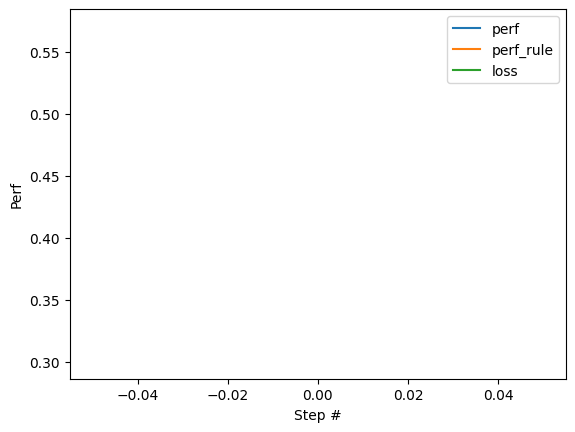


step 2, large gradient norm encountered (inf).
checking grad & avg activity...
areas.0.convs.0->1.0.weight, norm of grad: 0.0000, max grad: 0.0000
areas.0.convs.0->1.0.bias, norm of grad: 0.0000, max grad: 0.0000
areas.0.convs.0->2.0.weight, norm of grad: 0.0000, max grad: 0.0000
areas.0.convs.0->2.0.bias, norm of grad: 0.0000, max grad: -0.0000
areas.0.convs.1->1.0.weight, norm of grad: 0.0000, max grad: 0.0000
areas.0.convs.1->1.0.bias, norm of grad: 0.0000, max grad: 0.0000
areas.0.convs.1->2.0.weight, norm of grad: 0.0000, max grad: 0.0000
areas.0.convs.1->2.0.bias, norm of grad: 0.0000, max grad: -0.0000
areas.0.convs.1->3.0.weight, norm of grad: 0.0000, max grad: 0.0000
areas.0.convs.1->3.0.bias, norm of grad: 0.0000, max grad: -0.0000
areas.0.convs.1->4.0.weight, norm of grad: 0.0000, max grad: 0.0000
areas.0.convs.1->4.0.bias, norm of grad: 0.0000, max grad: 0.0000
areas.0.convs.2->0.0.weight, norm of grad: 0.0000, max grad: 0.0000
areas.0.convs.2->0.0.bias, norm of grad: 0.00

NameError: name 'save_name' is not defined

In [ ]:
# Training loop
model.train()
for ba in range(ba_start, int(1e10)):
    start_step = time.time()

#         current_rule = random.choice(rule_list)    # randomly choose a rule to start
    current_rule = rule_list[0]    # use a fixed rule
    perf_list = []
    perf_rule_list = []
    rnn_activity_over_trials = []
    loss = 0

    block_len = hp['block_len'] + random.randint(0,0)    # test: variable block length
    switches = random.sample(range(block_len-1), hp['n_switches'])

    if hp['grad_remove_history']==True:
        if give_prev_stim==False:
#                 prev_stim_mag -= 1e-3    # gradually remove it
            prev_stim_mag = 0     # suddenly remove it
            prev_stim_mag = max(prev_stim_mag, 0)
        if give_prev_rew==False:
#                 prev_rew_mag -= 1e-3    # gradually remove it
            prev_rew_mag = 0
            prev_rew_mag =  max(prev_rew_mag, 0)
        if give_prev_choice==False:
#                 prev_choice_mag -= 1e-3    # gradually remove it
            prev_choice_mag = 0
            prev_choice_mag = max(prev_choice_mag, 0)

    for tr in range(block_len):
#             print('tr {}'.format(tr), flush=True)
        # compute the trial history
        if tr==0:
            h_init = None
            i_me_init = None
            last_rew = None
            prev_stim = None
            prev_choice = None
        else:
            # if reset_network==False:
            #     if hp['bpx1tr']==True:
            #         h_init = h_last.detach()    # for backprop after each trial
            #         i_me_init = i_me_last.detach()
            #     else:
            #         h_init = h_last
            #         i_me_init = i_me_last
            # else:
            #     h_init = None
            #     i_me_init = None
            if give_prev_rew==True or hp['grad_remove_history']==True:
                last_rew = perf.detach()    # detach it from the graph
            else:
                last_rew = None
            if give_prev_stim==True or hp['grad_remove_history']==True:
                prev_stim = _x.detach().squeeze(-1).squeeze(-1)    # detach it from the graph
            else:
                prev_stim = None
            if give_prev_choice==True or hp['grad_remove_history']==True:
                prev_choice = choice.detach()    # detach it from the graph
            else:
                prev_choice = None



        # implement variable trial duration
        hp_task_var_delay = copy.deepcopy(hp_task)
        iti = hp_task['center_card_on'] - hp_task['trial_history_end'] + int(np.random.uniform(low=-iti_var, high=iti_var))
        hp_task_var_delay['center_card_on'] = hp_task_var_delay['trial_history_end'] + iti
        hp_task_var_delay['center_card_off'] = hp_task_var_delay['center_card_on'] + (hp_task['center_card_off'] - hp_task['center_card_on'])
        hp_task_var_delay['test_cards_on'] = hp_task_var_delay['center_card_on'] + (hp_task['test_cards_on'] - hp_task['center_card_on'])
        hp_task_var_delay['test_cards_off'] = hp_task_var_delay['test_cards_on'] + (hp_task['test_cards_off'] - hp_task['test_cards_on'])
        hp_task_var_delay['resp_start'] = hp_task_var_delay['test_cards_on']
        hp_task_var_delay['resp_end'] =  hp_task_var_delay['test_cards_off']
        hp_task_var_delay['trial_end'] = hp_task_var_delay['resp_end']
#             print('gewg hp_task_var_delay', hp_task_var_delay)

#             hp_task_var_delay['resp_start'] = hp_task['resp_start'] + np.random.uniform(low=-delay_var, high=delay_var)    # adjust this
#             hp_task_var_delay['resp_end'] = hp_task_var_delay['resp_start'] + (hp_task['resp_end']-hp_task['resp_start'])    # resp duration remains the same
#             hp_task_var_delay['trial_end'] = hp_task_var_delay['resp_end']
#             if hp['task']=='wcst':
#                 hp_task_var_delay['test_cards_on'] = hp_task_var_delay['resp_start']
#                 hp_task_var_delay['test_cards_off'] = hp_task_var_delay['resp_end']
#             if hp['resp_cue']==True:
#                 hp_task_var_delay['resp_cue_start'] = hp_task_var_delay['resp_start']    # change the start of the response cue
#                 hp_task_var_delay['resp_cue_end'] = hp_task_var_delay['resp_cue_start'] + (hp_task['resp_cue_end']-hp_task['resp_cue_start'])     # keep the duration of the response cue the same


        # compute the trial history current
        start_trialhistory = time.time()
        input_period = np.arange(int(hp_task_var_delay['trial_history_start']/hp['dt']), int(hp_task_var_delay['trial_history_end']/hp['dt']))    # input period for the trial history info
        n_steps = (hp_task_var_delay['trial_end'] - hp_task_var_delay['trial_start'])//hp['dt']
        n_steps = int(n_steps)
        if hp['task']=='cxtdm':
            ts_prev_stim_start = hp_task_var_delay['stim_start']
            ts_prev_stim_end = hp_task_var_delay['stim_end']
            I_prev_rew, I_prev_stim, I_prev_choice = compute_trial_history(last_rew=last_rew, prev_stim=prev_stim, prev_choice=prev_choice, input_period=input_period, batch_size=hp['batch_size'], n_steps=n_steps, input_dim=hp['n_input'], stim_start=ts_prev_stim_start, stim_end=ts_prev_stim_end, dt=hp['dt'], choice_dim=2)    # each current is time*batch*feature
        if hp['task']=='wcst':
            ts_prev_stim_start = hp_task_var_delay['test_cards_on']    # here the center card is still shown
            ts_prev_stim_end = hp_task_var_delay['test_cards_off']
            I_prev_rew, I_prev_stim, I_prev_choice = compute_trial_history(last_rew=last_rew, prev_stim=prev_stim, prev_choice=prev_choice, input_period=input_period, batch_size=hp['batch_size'], n_steps=n_steps, input_dim=hp['n_input'], stim_start=ts_prev_stim_start, stim_end=ts_prev_stim_end, dt=hp['dt'], choice_dim=3)    # each current is time*batch*feature
        I_prev_rew, I_prev_stim, I_prev_choice = I_prev_rew.to(device), I_prev_stim.to(device), I_prev_choice.to(device)
        trial_history = {'i_prev_rew': prev_rew_mag*I_prev_rew, 'i_prev_choice': prev_choice_mag*I_prev_choice, 'i_prev_stim': prev_stim_mag*I_prev_stim}
#             print('compute trial history input takes {:.2e}s, total time for this step = {:.2e}s'.format(time.time()-start_trialhistory, time.time()-start_step))

#                 # test: plot the history currents
#                 fig, ax=plt.subplots()
#                 ax.set_title('I_prev_rew')
#                 for i in range(I_prev_rew.shape[-1]):
#                     ax.plot(I_prev_rew[:,0,i])
#                 ax.set_ylim([-0.1, 1.1])
#                 fig, ax=plt.subplots()
#                 ax.set_title('I_prev_stim')
#                 for i in range(I_prev_stim.shape[-1]):
#                     ax.plot(I_prev_stim[:,0,i])
#                 ax.set_ylim([-0.1, 1.1])
#                 fig, ax=plt.subplots()
#                 ax.set_title('I_prev_choice')
#                 for i in range(I_prev_choice.shape[-1]):
#                     ax.plot(I_prev_choice[:,0,i])
#                 ax.set_ylim([-0.1, 1.1])
#                 plt.show()


        # generate input and target for 1 trial
        start_gendata = time.time()
        # fusi task
        if task=='salzman':
            _x, _x_rule, _yhat, _yhat_rule, task_data = make_task_fusi(n_trials=hp['batch_size'], rule=current_rule, hp=hp, hp_fusi=hp_task_var_delay)
        # cxtdm task
        elif task=='cxtdm':
            if tr-1 in switches or tr==0:
                _x, _x_rule, _yhat, _yhat_rule, task_data = make_task_siegel(n_trials=hp['batch_size'], rule=current_rule, hp=hp, hp_cxtdm=hp_task_var_delay, trial_type='incongruent')    # such that the first trial after switch is always incongruent
            else:
                _x, _x_rule, _yhat, _yhat_rule, task_data = make_task_siegel(n_trials=hp['batch_size'], rule=current_rule, hp=hp, hp_cxtdm=hp_task_var_delay, trial_type='no_constraint')
        # wisconsin card sorting task
        elif task=='wcst':
            wcst = WCST(hp=hp, hp_wcst=hp_task_var_delay, rule=current_rule, rule_list=rule_list, n_features_per_rule=2, n_test_cards=3)
            _x, _x_rule, _yhat, _yhat_rule, task_data = wcst.make_task_batch(batch_size=hp['batch_size'])
        _x, _x_rule, _yhat, _yhat_rule = _x.to(device), _x_rule.to(device), _yhat.to(device), _yhat_rule.to(device)
        if hp['train_rule']==True:
            _yhat_rule = _yhat_rule.to(device)
        if hp['timeit_print']==True:
            print('generate data takes {:.2e}s, total time for this step = {:.2e}s'.format(time.time()-start_gendata, time.time()-start_step))

        # run model forward 1 trial
        start_forward = time.time()


#             # debug device
#             print('before forward pass')
#             for key in trial_history.keys():
#                 print(ba, tr, key, trial_history[key].device)
#             print(ba, tr, '_x device: {}'.format(_x.device))
#             if h_init is None:
#                 print(ba, tr, 'h_init is None')
#             else:
#                 print(ba, tr, 'h_init device: {}'.format(h_init.device))
#             if i_me_init is None:
#                 print(ba, tr, 'i_me_init is None')
#             else:
#                 print(ba, tr, 'i_me_init device: {}'.format(i_me_init.device))
#             for name, param in model.named_parameters():
#                 print(ba, tr, name, param.device)
#             model.to(device); model.rnn.to(device)
#             print('_x shape: {}\n'.format(_x.shape), flush=True)

        # out, data = model(input=_x, init={'h': h_init, 'i_me': i_me_init}, trial_history=trial_history, hp=hp)

        # Combine previous trial info with input to model
        _x = _x.unsqueeze(-1).unsqueeze(-1)
        prev_rew_input=trial_history['i_prev_rew'].unsqueeze(-1).unsqueeze(-1)
        prev_choice_input=trial_history['i_prev_choice'].unsqueeze(-1).unsqueeze(-1)
        prev_stim_input=trial_history['i_prev_stim'].unsqueeze(-1).unsqueeze(-1)
        # print(prev_stim_input.shape, prev_choice_input.shape)
        new_x = torch.cat([_x, prev_rew_input, prev_choice_input, prev_stim_input], dim=2)
        out = model(new_x)
        output, hidden, feedback = out
        if hp['timeit_print']==True:
            print('forward pass takes {:.2e}s, total time for this step = {:.2e}s'.format(time.time()-start_forward, time.time()-start_step))
#                 if ba>=0 and hp['timeit_print']==True:
#                     fptime = time.time()-start_forward
#                     print('forward pass takes {}s'.format(fptime), flush=True)
#                     times['forward'].append(fptime)

        # rnn_activity = data['record']['hiddens']
        rnn_activity = hidden
        # rnn_activity = torch.stack(rnn_activity, dim=0)
        rnn_activity_over_trials.append(rnn_activity)
        # h_last = data['last_states']['hidden']
        # i_me_last = data['last_states']['i_me']

        # check if some activity is exploding
        # if hp['check_explode_cg']==True:
        #     explode_cgs = []
        #     for cg in model.rnn.cell_group_list:
        #         mean_act_cg = torch.mean(rnn_activity[:,:,model.rnn.cg_idx[cg]])
        #         if mean_act_cg>1e1 or torch.isnan(mean_act_cg):
        #             print('step {}, tr {}, mean {} activity is {}!!!'.format(ba, tr, cg, mean_act_cg))
        #             explode_cgs.append(cg)

        # get the performance
        # _y = out['out']
        _y = output[1][:,:,:hp['n_output']]
        _y = _y.squeeze(-1).squeeze(-1)
        if hp['task']!='wcst':
            perf, choice_prob, choice = get_perf(y=_y, yhat=_yhat, hp=hp, hp_task=hp_task_var_delay)
#                 print('perf shape: {}'.format(perf.shape), flush=True)
        else:
            perf, choice_prob, choice = wcst.get_perf(y=_y, yhat=_yhat)
        if hp['train_rule']==True:
            # _y_rule = out['out_rule']
            _y_rule = output[1][:,:,hp['n_output']:]
            _y_rule = _y_rule.squeeze(-1).squeeze(-1)
            if hp['task']=='wcst':
                perf_rule, _, _ = wcst.get_perf_rule(y_rule=_y_rule, yhat_rule=_yhat_rule)
            else:
                perf_rule, _, _ = get_perf(y=_y_rule, yhat=_yhat_rule, hp=hp, hp_task=hp_task_var_delay)

        # accumulate loss
        # for debugging: mask our the 1st trial and see if error can backprop to the init state
#         if tr==0:
#             loss += 0
#         else:
#             loss += loss_fnc(_y, _yhat)
#             if hp['train_rule']==True:
#                 loss += loss_fnc(_y_rule, _yhat_rule)
        loss += loss_fnc(_y, _yhat)
        # loss += hp['l1_weight']*torch.norm(model.rnn.w_rec_eff, p=1)/torch.numel(model.rnn.w_rec_eff) + hp['l2_weight']*torch.norm(model.rnn.w_rec_eff, p=2)/np.sqrt(torch.numel(model.rnn.w_rec_eff)) + hp['l1_h']*torch.norm(rnn_activity, p=1)/torch.numel(rnn_activity) + hp['l2_h']*torch.norm(rnn_activity, p=2)/np.sqrt(torch.numel(rnn_activity))    # regularization term for the weights
        # if 'sr_esoma' in hp['cell_group_list']:
        #     loss += hp['l2_h_sr']*torch.norm(rnn_activity[:, :, model.rnn.cg_idx['sr_esoma']], p=2)    # regularization for the activity
        # if 'pfc_esoma' in hp['cell_group_list']:
        #     loss += hp['l2_h_pfc']*torch.norm(rnn_activity[:, :, model.rnn.cg_idx['pfc_esoma']], p=2)    # regularization for the activity
        # if 'sr_edend' in hp['cell_group_list']:
        #     loss += hp['l1_h_sredend']*torch.norm(rnn_activity[:, :, model.rnn.cg_idx['sr_edend']], p=1)    # regularization for the dendritic activity for SR (l1 because the dendritic activity can be negative under the 'old' type dendritic nonlinearity)
#         loss = loss_fnc(_y, _yhat)    # for backprop after each trial
        if hp['train_rule']==True:
            loss += loss_fnc(_y_rule, _yhat_rule)

        # test: would bp cross 1 trial work?
        # if hp['bpx1tr']==True:
        #     optim.zero_grad()           # clear gradients for this training step
        #     loss_1tr = loss_fnc(_y, _yhat)
        #     loss_1tr += hp['l1_weight']*torch.norm(model.rnn.w_rec_eff, p=1)/torch.numel(model.rnn.w_rec_eff) + hp['l2_weight']*torch.norm(model.rnn.w_rec_eff, p=2)/np.sqrt(torch.numel(model.rnn.w_rec_eff)) + hp['l1_h']*torch.norm(rnn_activity, p=1)/torch.numel(rnn_activity) + hp['l2_h']*torch.norm(rnn_activity, p=2)/np.sqrt(torch.numel(rnn_activity))    # regularization term for the weights
        #     if 'sr_esoma' in hp['cell_group_list']:
        #         loss_1tr += hp['l2_h_sr']*torch.norm(rnn_activity[:, :, model.rnn.cg_idx['sr_esoma']], p=2)    # regularization for the activity
        #     if 'pfc_esoma' in hp['cell_group_list']:
        #         loss_1tr += hp['l2_h_pfc']*torch.norm(rnn_activity[:, :, model.rnn.cg_idx['pfc_esoma']], p=2)    # regularization for the activity
        #     if hp['train_rule']==True:
        #         loss_1tr += loss_fnc(_y_rule, _yhat_rule)
        #     loss_1tr.backward(retain_graph=False)           # backpropagation, compute gradients
        #     loss_1tr = np.nan_to_num(loss_1tr.detach().cpu().numpy(), nan=np.inf)    # convert nan to inf in case loss blows up
        #     grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1, error_if_nonfinite=False)    # gradient clip
        #     optim.step()


        # collect perf across trials
        perf_list.append(torch.mean(perf.float().detach()).cpu())
        if hp['train_rule']==True:
            perf_rule_list.append(torch.mean(perf_rule.float().detach()).cpu())
        else:
            perf_rule_list.append(-1)

        # switch rule if necessary
        if tr in switches:
            if len(rule_list)==1:
                next_rule = current_rule
                print('only 1 rule in rule_list, not switching\n', flush=True)
            else:
                next_rule = random.choice([r for r in rule_list if r!=current_rule])    # randomly switch to a different rule
            current_rule = next_rule

    # backprop at the end of block
    if hp['bpx1tr']==False:
        start_backward = time.time()
        optim.zero_grad()           # clear gradients for this training step
        loss = loss/block_len
        loss.backward(retain_graph=True)           # backpropagation, compute gradients
#             print('loss device: {}'.format(loss.device))    # debug
        loss = np.nan_to_num(loss.detach().cpu().numpy(), nan=np.inf)    # convert nan to inf in case loss blows up
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1, error_if_nonfinite=False)    # gradient clip
        # monitor average activity
        if grad_norm>=10:
            print('\nstep {}, large gradient norm encountered ({:0.4f}).\nchecking grad & avg activity...'.format(ba, grad_norm))
            for name, param in model.named_parameters():
                if param.requires_grad==True:
                    if param.grad is not None:    # the param is part of the graph
                        print('{}, norm of grad: {:0.4f}, max grad: {:0.4f}'.format(name, torch.norm(param.grad.detach(), p=2), torch.max(param.grad.detach())))
#             if torch.isnan(grad_norm)==False:


#             print('before optim.step()')
#             for name, param in model.named_parameters():   # debug
#                 print(ba, name, param.device)
#             print(model.rnn.w_rec.device, (prev_stim_mag*I_prev_stim).device, _x.device, _yhat.device, flush=True)    # debug


        optim.step()                # apply gradients when gradient is finite
        if hp['timeit_print']==True:
#         if True:
            print('***backward pass takes {:.2e}s, total time for this step = {:.2e}s'.format(time.time()-start_backward, time.time()-start_step), flush=True)


    # record the recent network activity
    if ba%1==0 and hp['record_recent_rnn_activity']==True:
        min_tstep = (hp_task['trial_end']-delay_var)//hp['dt']    # since trial length is variable
        rnn_activity_over_trials_cut = [_[:min_tstep,:,:] for _ in rnn_activity_over_trials]    # cut to the minimum duration of a trial (since there is variable delay)
        rnn_activity_concat = concat_trials(torch.stack(rnn_activity_over_trials_cut))
        rnn_activity_list.append(rnn_activity_concat)    # renp.mean(data[i, model.rnn.cg_idx[cg],:], axis=0)h_initcord the activity
        if len(rnn_activity_list)>3:
            rnn_activity_list.pop(0)    # only record the last k steps to save memory

#                 for cg in model.rnn.cell_group_list:
#                     if (rnn_activity_concat[:, model.rnn.cg_idx[cg], :]>=10).any() or torch.isnan(rnn_activity_concat[:, model.rnn.cg_idx[cg], :]).any():
#                         print('step {}, {}, average activity over time in a block: {}\n'.format(ba, cg, torch.mean(rnn_activity_concat[:, model.rnn.cg_idx[cg], :], dim=(0,1))))


    # collect and print
    if ba%1==0:
        perf_list_big.append(np.mean(perf_list))
        perf_rule_list_big.append(np.mean(perf_rule_list))
        loss_list_big.append(loss)

    if ba%10==0:
#                 print('Step {}, dend2soma={}'.format(ba, model.rnn.dend2soma.data))
#                 print('Step {}, SST bias {}'.format(ba, model.rnn.bias[model.rnn.cg_idx['sr_sst']]))
        print('Step {}, total loss={:0.4f}, perf={:0.4f}, perf rule={:0.4f}, time={:0.2f}s, ps/c/r={}/{}/{}, bl_len={}, swit={}'
                .format(ba, loss, np.mean(perf_list), np.mean(perf_rule_list), time.time()-start+start_time, give_prev_stim, give_prev_choice, give_prev_rew,
                        hp['block_len'], switches), flush=True)
        # print('prev stim/choice/rew mag: {}/{}/{}\n'.format(prev_stim_mag, prev_choice_mag, prev_rew_mag))
#         print('h0={}'.format(model.rnn.h0[0:3,0:3]))
        if plot==True:
            fig = plt.figure()
            plt.plot(perf_list_big, label='perf')
            plt.plot(perf_rule_list_big, label='perf_rule')
            plt.plot(loss_list_big, label='loss')
            plt.xlabel('Step #')
            plt.ylabel('Perf')
            plt.legend()
            plt.show()


    if ba%1000==0 and ba>0:
        print('torch seed = {}\n'.format(hp['torch_seed']))
        print('reset network: {}, give_prev_stim: {}, give_prev_choice: {}, give_prev_rew: {}\n'.format(reset_network, give_prev_stim, give_prev_choice, give_prev_rew), flush=True)
        print('Block length = {}. Number of switches = {}\n'.format(hp['block_len'], hp['n_switches']), flush=True)
        for key in hp.keys():
            print('{}: {}'.format(key, hp[key]))
#             print(hp)
        print('\n')
        print(optim)
        print('\n')
        print(hp_task)
        print('\n')
#             display_connectivity(model=model, plot=False)

        print(switches, flush=True)
        if plot==True:
            plot_y_yhat(_y.cpu(), _yhat.cpu())
            if hp['train_rule']==True:
                plot_y_yhat(_y_rule.cpu(), _yhat_rule.cpu())
            plot_perf(perf_list)
            plot_perf(perf_rule_list, title='performance (rule)', ylabel='performance (rule)')

    # save checkpoint
    if ba%10==0 and ba>0:
        print('saving checkpoint. name={}_{}'.format('chkpt', hp['save_name']))
        save_name=hp['save_name']
        saved_file = {'step': ba, 'time': time.time()-start+start_time, 'model': model, 'model_state_dict': model.state_dict(), 'optimizer': optim, 'optim_state_dict': optim.state_dict(), 'hp': hp, 'hp_task': hp_task, 'perf_list':perf_list_big, 'perf_rule_list': perf_rule_list_big, 'loss_list': loss_list_big,'test_perf_list': test_perf_list_big, 'test_perf_rule_list': test_perf_rule_list_big, 'test_loss_list': test_loss_list_big, 'reset_network': reset_network, 'give_prev_stim': give_prev_stim, 'give_prev_choice': give_prev_choice, 'give_prev_rew': give_prev_rew, 'curriculum': curriculum, 'prev_stim_mag': prev_stim_mag, 'prev_choice_mag': prev_choice_mag, 'prev_rew_mag': prev_rew_mag}
        torch.save(saved_file, Path(ckpt_pth, f'chkpt_{save_name}'))     # save a copy in scratch


    # testing
    perf_crit_train = 1-hp['n_switches']/hp['block_len']-0.2    # performance criteria
    mean_recent_perf = np.mean(perf_list_big[-1:])
    mean_recent_perf_rule = np.mean(perf_rule_list_big[-1:])
    if mean_recent_perf>= perf_crit_train and mean_recent_perf_rule>=perf_crit_train:
        print('\nStep {}, perf: {:.4f}/{:.4f}, criteria for begin testing: {:.4f}. \n Start testing...........'.format(ba, mean_recent_perf, mean_recent_perf_rule, perf_crit_train), flush=True)
        n_trials_test = 200
        switch_every_test = 20
        max_perf_test = 1-1/switch_every_test
        if hp['n_switches']<2:
            print('\n<2 switches during training. Therefore skip testing\n', flush=True)
            perf_test = 1
            perf_rule_test = 1
            loss_test = 0
        else:
            init_rule = random.choice(rule_list)
            print('init_rule={}'.format(init_rule))
            perf_test, perf_rule_test, loss_test, _ = test_frozen_weights(model=model,
                                                                            n_trials_test=n_trials_test,
                                                                            switch_every_test=switch_every_test,
                                                                            init_rule=init_rule,
                                                                            task=task,
                                                                            hp=hp,
                                                                            hp_task=hp_task,
                                                                            loss_fnc=loss_fnc,
                                                                            delay_var = 200,
                                                                            give_prev_rew=give_prev_rew,
                                                                            give_prev_stim=give_prev_stim,
                                                                            give_prev_choice=give_prev_choice,
                                                                            noiseless=False)
#                     _, _, _, test_data = test_frozen_weights(model=model, n_trials_test=n_trials_test, switch_every_test=switch_every_test,
#                                              init_rule=random.choice(rule_list), hp=hp_test, task=task,
#                                              loss_fnc=nn.MSELoss(), hp_task=hp_task_test,
#                                              delay_var=0,
#                                              give_prev_choice=True, give_prev_stim=True, give_prev_rew=True, plot=to_plot,
#                                              random_switch=random_switch, n_switches=n_switches)
        test_perf_list_big.append(perf_test)
        test_perf_rule_list_big.append(perf_rule_test)
        test_loss_list_big.append(loss_test)
        criteria_perf = max_perf_test - 0.15
        print('test perf: {}/{}, max_perf_test = {}, criteria for continuing to next stage of curriculum learning: {}'.format(perf_test, perf_rule_test, max_perf_test, criteria_perf), flush=True)
        # curriculum learning
        if np.mean(test_perf_list_big[-5:])>=max_perf_test-0.05 and np.mean(test_perf_rule_list_big[-5:])>=max_perf_test-0.05:
        # if np.mean(test_perf_list_big[-1:])>=criteria_perf and np.mean(test_perf_rule_list_big[-1:])>=criteria_perf:    # for slow switching models
            print('recent testing performance meets criteria ({})\n'.format(criteria_perf), flush=True)
            if curriculum==False:
                if curriculum_t==False:     # no curriculum learning
                    print('Testing performance reaches criterion after no curriculum learning. Training ends.', flush=True)
                    success = 'success'
                    break
                elif curriculum_t==True and curr_t_progress!=len(hp['block_len_n_swit_comb']):    # curriculum learning on block length, progress +1
                    curr_t_progress += 1
                    hp['block_len'], hp['n_switches'] = hp['block_len_n_swit_comb'][curr_t_progress]
                    max_perf_train = 1-hp['n_switches']/hp['block_len']
                    print('*** Increase block length. New block length = {} trials. New n_swtiches = {} ***'.format(hp['block_len'], hp['n_switches']), flush=True)
                    give_prev_stim, give_prev_choice, give_prev_rew = True, True, True
                    continue
                elif curriculum_t==True and curr_t_progress==len(hp['block_len_n_swit_comb']):    # curriculum learning on block length completed
                    print('Testing performance reaches criterion after curriculum training on block length. Training ends.', flush=True)
                    success = 'success'
                    break
            elif curriculum==True:
                if give_prev_stim==True:    # curriculum learning on trial history, progress +1
                    give_prev_stim = False
                    print('******** Now not giving previous stimulus ********\n', flush=True)
                    optim = optimizer(params=model.parameters(), lr=hp['learning_rate'])    # re-initialize the optimizer?
                    continue
                elif give_prev_choice==True and prev_stim_mag==0:    # curriculum learning on trial history, progress +1
                    give_prev_choice = False
                    print('******** Now not giving previous choice ********\n', flush=True)
                    optim = optimizer(params=model.parameters(), lr=hp['learning_rate'])    # re-initialize the optimizer?
                    continue
                else:
                    print('prev_choice_mag={}'.format(prev_choice_mag))
                    if curriculum_t==False and prev_choice_mag==0:    # curriculum learning on trial history completed
                        print('Testing performance reaches criterion after curriculum training on trial history. Training ends.', flush=True)
                        success = 'success'
                        break
                    elif curriculum_t==True and curr_t_progress!=len(hp['block_len_n_swit_comb']):    # curriculum learning on block length, progress +1
                        curr_t_progress += 1
                        hp['block_len'], hp['n_switches'] = hp['block_len_n_swit_comb'][curr_t_progress]
                        max_perf_train = 1-hp['n_switches']/hp['block_len']
                        print('*** Increase block length. New block length = {} trials. New n_swtiches = {} ***'.format(hp['block_len'], hp['n_switches']), flush=True)
                        give_prev_stim, give_prev_choice, give_prev_rew = True, True, True
                        continue
                    elif curriculum_t==True and curr_t_progress==len(hp['block_len_n_swit_comb']):    # curriculum learning on block length and trial history completed
                        print('Testing performance reaches criterion after double curriculum training (trial history + block length). Training ends.', flush=True)
                        success = 'success'
                        break


    if ba>=1e5:
        print('Does not converge after too many batches. Training ends.', flush=True)
        success = 'noConverge'
        break
    elif loss==np.inf:
        success = 'gradExplode'
        print('gradient explodes! training ends', flush=True)
        if hp['check_explode_cg']==True:
            print('cell groups that explode: {}'.format(explode_cgs))
        break
#         elif time.time()-start>=3600*47:    # when the running time is over (try using checkpoint and continuing the job)
#             success = 'timesup'
#             print('Time is up!')
#             break


# save at the end of training
print('saving model. name={}_{} ... \n'.format(success, hp['save_name']))
saved_file = {'model': model, 'rnn_activity_lastk': rnn_activity_list, 'model_state_dict': model.state_dict(), 'optimizer': optim, 'optim_state_dict': optim.state_dict(), 'hp': hp, 'hp_task': hp_task, 'perf_list':perf_list_big, 'perf_rule_list': perf_rule_list_big, 'loss_list': loss_list_big,'test_perf_list': test_perf_list_big, 'test_perf_rule_list': test_perf_rule_list_big, 'test_loss_list': test_loss_list_big}
#         torch.save(saved_file, '/home/yl4317/Documents/two_module_rnn/saved_models/{}_{}'.format(success, save_name[:150]))
torch.save(saved_file, Path(models_pth, f'{success}_{save_name}'))     # save a copy in scratch



#     if success=='success':
#         # TODO: save testing data
#         path_to_pickle_file = '/scratch/yl4317/two_module_rnn/saved_testdata/' + hp['save_name'][:150] + '_testdata_noiseless_no_current_matrix'
#         model.rnn.network_noise = 0
#         hp['input_noise_perceptual'] = 0
#         hp['input_noise_rule'] = 0
#         test_data = generate_neural_data_test(model=model, n_trials_test=100, switch_every_test=10, batch_size=10, to_plot=False, hp_test=hp, hp_task_test=hp_task, compute_current=False, random_switch=True, n_switches=10, concat_activity=False)
#         with open(path_to_pickle_file, 'wb') as f:
#             pickle.dump(test_data, f)

if plot==True:
    fig = plt.figure()
    plt.plot(perf_list_big, label='perf')
    plt.plot(perf_rule_list_big, label='perf_rule')
    plt.plot(loss_list_big, label='loss')
    plt.xlabel('Step # (x100)')
    plt.ylabel('Perf')
    plt.legend()
    plt.show()

    fig = plt.figure()
    plt.plot(test_perf_list_big, label='perf')
    plt.plot(test_perf_rule_list_big, label='perf_rule')
    plt.plot(test_loss_list_big, label='loss')
    plt.xlabel('Test #')
    plt.ylabel('Perf')
    plt.legend()
    plt.show()


#     return times





